In [151]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.19


# Python libraries

In [152]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need
%load_ext autoreload
%autoreload 2
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.stan.invT import predict_temperature_from_RI
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial
import pygwalker as pyg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.1.0


# Cosmetic settings

In [153]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

# Miscellaneous functions

In [154]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [155]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.021,0.105), #(0.021,0.105)  <--- recalculated from the Fig S2 in O'Brien et al., 2017 | (0.0170,0.19) <--- shown in the main text of O'Brien et al., 2017
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [156]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

In [157]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

# Set local path

In [158]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [159]:
### Regression dataset compilation
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,no3_sf2tc_tc1deg04filled,ringIndex,scaledRI,t1deg_sf2tc_1deg_04filled,t_sf2pc_avg,t_sf2tc_1deg,t_sf2tc_1deg_04filled,t_sf2tc_avg,woa23_no3_sf2tc_1deg,woa23_no3_sf2tc_tc1deg04filled
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,2.039928,0.509982,-1.621188,-1.656110,NaN,-1.621188,-1.636017,NaN,NaN
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.752475,0.438119,-1.586854,-1.547720,NaN,-1.586854,-1.586854,NaN,NaN
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.643722,0.410931,-1.692642,-1.682932,NaN,-1.692642,-1.692642,NaN,NaN
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,28.343912,1.733369,0.433342,-1.463560,NaN,NaN,-1.463560,-1.498910,NaN,28.343912
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,29.035012,1.790070,0.447518,-1.530241,NaN,-1.640889,-1.640889,-1.651191,22.066089,22.066089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,NaN,2.677364,0.669341,22.000000,22.000000,22.000000,22.000000,22.000000,NaN,NaN
1536,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,2.445333,0.611333,25.000000,25.000000,25.000000,25.000000,25.000000,NaN,NaN
1537,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,2.627887,0.656972,32.000000,32.000000,32.000000,32.000000,32.000000,NaN,NaN
1538,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,3.598787,0.899697,36.000000,36.000000,36.000000,36.000000,36.000000,NaN,NaN


In [160]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Calibration posteriors

In [161]:
# Save data for Stan

cul_df = gridded_combined_df[gridded_combined_df['datatype']=='culture'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
meso_df = gridded_combined_df[gridded_combined_df['datatype']=='mesocosm'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
data = {
    "N_cul": len(cul_df),
    "t_cul": cul_df['SST'].values,
    "scaledRI_cul": cul_df['scaledRI'].values,
    "N_meso": len(meso_df),
    "t_meso": meso_df['SST'].values,
    "scaledRI_meso": meso_df['scaledRI'].values,
}

stan_file_name = 'gen_logi_fixed_culmeso'
gen_logi_fixed_cul_meso_post_ds, diag = get_posterior(data=data, 
                                        stan_file=stan_file_name,
                                        temptype='cultureT')


# Save posteriors
save_posterior(gen_logi_fixed_cul_meso_post_ds,filename_suffix="_020526")

05:21:06 - cmdstanpy - INFO - Chain [1] start processing
05:21:06 - cmdstanpy - INFO - Chain [2] start processing
05:21:06 - cmdstanpy - INFO - Chain [3] start processing
05:21:06 - cmdstanpy - INFO - Chain [4] start processing


No gdgt23ratio data passing for multivariate model; injecting zeros.
No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: meso (from N_meso, N=8)
   GDGT23 keys in data: [] → use_gdgt23ratio = 0
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_culmeso.stan
✅ Compiled: gen_logi_fixed_culmeso.stan
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nut

05:21:07 - cmdstanpy - INFO - Chain [3] done processing
05:21:07 - cmdstanpy - INFO - Chain [2] done processing
05:21:07 - cmdstanpy - INFO - Chain [1] done processing
05:21:07 - cmdstanpy - INFO - Chain [4] done processing
05:21:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 1.34381, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
	Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
	Exception: beta_lpdf: Random variable is 1.09205, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
	Exception: beta_lpdf: Random variable is 2.35553, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 0.22 seconds (Warm-up)
Chain [3] 0.207 seconds (Sampling)
Chain [3] 0.427 seconds (Total)
Chain [3] 
Chain [3] 
Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0.233 seconds (Warm-up)
Chain [2] 0.201 seconds (Sampling)
Chain [2] 0.434 seconds (Total)
Chain [2] 
Chain [2] 
Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 0.216 seconds (Warm-up)
Chain [1] 0.219 seconds (Sampling)
Chain [1] 0.435 seconds (Total)
Chain [1] 
Chain [1] 
Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 0.226 seconds (Warm-up)
Chain [4] 0.212 seconds (Sampling)
Chain [4] 0.438 seconds (Total)
Chain [4] 
Chain [4] 
Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmeso_cultureT_020526.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmeso_cultureT_020526.nc')

In [162]:
# Save data for Stan

cul_df = gridded_combined_df[gridded_combined_df['datatype']=='culture'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
meso_df = gridded_combined_df[gridded_combined_df['datatype']=='mesocosm'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
data = {
    "N_cul": len(cul_df),
    "t_cul": cul_df['SST'].values,
    "scaledRI_cul": cul_df['scaledRI'].values,
    "N_meso": len(meso_df),
    "t_meso": meso_df['SST'].values,
    "scaledRI_meso": meso_df['scaledRI'].values,
}

stan_file_name = 'gen_logi_fixed_Q1_culmeso'
gen_logi_fixed_Q1_cul_meso_post_ds, diag = get_posterior(data=data, 
                                        stan_file=stan_file_name,
                                        temptype='cultureT')


# Save posteriors
save_posterior(gen_logi_fixed_Q1_cul_meso_post_ds,filename_suffix="_020526")

05:21:07 - cmdstanpy - INFO - Chain [1] start processing
05:21:07 - cmdstanpy - INFO - Chain [2] start processing
05:21:07 - cmdstanpy - INFO - Chain [3] start processing
05:21:07 - cmdstanpy - INFO - Chain [4] start processing


No gdgt23ratio data passing for multivariate model; injecting zeros.
No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: meso (from N_meso, N=8)
   GDGT23 keys in data: [] → use_gdgt23ratio = 0
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_Q1_culmeso.stan
✅ Compiled: gen_logi_fixed_Q1_culmeso.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [

05:21:07 - cmdstanpy - INFO - Chain [4] done processing
05:21:07 - cmdstanpy - INFO - Chain [3] done processing
05:21:07 - cmdstanpy - INFO - Chain [1] done processing
05:21:07 - cmdstanpy - INFO - Chain [2] done processing
05:21:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_Q1_culmeso.stan', line 39, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_Q1_culmeso.stan', line 39, column 2 to column 64)
	Exception: beta_lpdf: Random variable is 94.7648, but must be in the interval [0, 1] (in 'gen_logi_fixed_Q1_culmeso.stan', line 27, column 2 to column 30)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_Q1_culmeso.stan', line 39, column 2 to column 64)
	Exception: beta_lpdf: Random variable is 1.03739, but must be in the interval [0, 1] (in 'gen_logi_fixed_Q1_culmeso.stan', line 27, colum

Chain [1] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [2] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [4] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [1] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [2] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 0.199 seconds (Warm-up)
Chain [4] 0.212 seconds (Sampling)
Chain [4] 0.411 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 0.202 seconds (Warm-up)
Chain [3] 0.215 seconds (Sampling)
Chain [3] 0.417 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 0.215 seconds (Warm-up)
Chain [1] 0.209 seconds (Sampling)
Chain [1] 0.424 seconds (Total)
Chain [1] 
Chain [1] 
Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0

PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_Q1_culmeso_cultureT_020526.nc')

In [163]:
# Save data for Stan

cul_df = gridded_combined_df[gridded_combined_df['datatype']=='culture'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
meso_df = gridded_combined_df[gridded_combined_df['datatype']=='mesocosm'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
data = {
    "N_cul": len(cul_df),
    "t_cul": cul_df['SST'].values,
    "scaledRI_cul": cul_df['scaledRI'].values,
    "N_meso": len(meso_df),
    "t_meso": meso_df['SST'].values,
    "scaledRI_meso": meso_df['scaledRI'].values,
}

stan_file_name = 'gen_logi_fixed_v1_culmeso'
gen_logi_fixed_v1_cul_meso_post_ds, diag = get_posterior(data=data, 
                                        stan_file=stan_file_name,
                                        temptype='cultureT')


# Save posteriors
save_posterior(gen_logi_fixed_v1_cul_meso_post_ds,filename_suffix="_020526")

05:21:07 - cmdstanpy - INFO - Chain [1] start processing
05:21:07 - cmdstanpy - INFO - Chain [2] start processing
05:21:07 - cmdstanpy - INFO - Chain [3] start processing
05:21:07 - cmdstanpy - INFO - Chain [4] start processing


No gdgt23ratio data passing for multivariate model; injecting zeros.
No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: meso (from N_meso, N=8)
   GDGT23 keys in data: [] → use_gdgt23ratio = 0
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_v1_culmeso.stan
✅ Compiled: gen_logi_fixed_v1_culmeso.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [

05:21:08 - cmdstanpy - INFO - Chain [2] done processing
05:21:08 - cmdstanpy - INFO - Chain [1] done processing
05:21:08 - cmdstanpy - INFO - Chain [4] done processing


Chain [1] Iteration: 1500 / 2000 [ 75%]  (Sampling)
Chain [4] Iteration: 1500 / 2000 [ 75%]  (Sampling)
Chain [2] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [3] Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain [1] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [4] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [2] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [3] Iteration: 1500 / 2000 [ 75%]  (Sampling)
Chain [1] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [4] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [2] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [1] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [3] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [2] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [4] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [1] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0.113 seconds (Warm-up)
Chain

05:21:08 - cmdstanpy - INFO - Chain [3] done processing
05:21:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_v1_culmeso.stan', line 39, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_v1_culmeso.stan', line 39, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_v1_culmeso.stan', line 38, column 2 to column 62)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_v1_culmeso.stan', line 39, column 2 to column 64)
	Exception: beta_lpdf: Random variable is 1.20016, but must be in the interval [0, 1] (in 'gen_logi_fixed_v1_culmeso.stan', line 27, column 2 to column 30)
	Exception: beta_lpdf: Random variable is 1.24352, but must be in the interval [0, 1] (in 'gen_logi_fixed_v1_culmeso.stan', line 27, column 2 to column 30)
	Exception:

Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 0.13 seconds (Warm-up)
Chain [3] 0.148 seconds (Sampling)
Chain [3] 0.278 seconds (Total)
Chain [3] 
Chain [3] 
Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_v1_culmeso_cultureT_020526.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_v1_culmeso_cultureT_020526.nc')

Grouped param names: {'t0': ['t0_culmeso'], 'k': ['k_culmeso'], 'b': ['b_culmeso'], 'v': ['v_culmeso'], 'Q': ['Q_culmeso'], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmeso'], 'k': ['k_culmeso'], 'b': ['b_culmeso'], 'v': ['v_culmeso'], 'Q': ['Q_culmeso'], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b', 'v', 'Q']
figure nrows, ncols: 2, 3


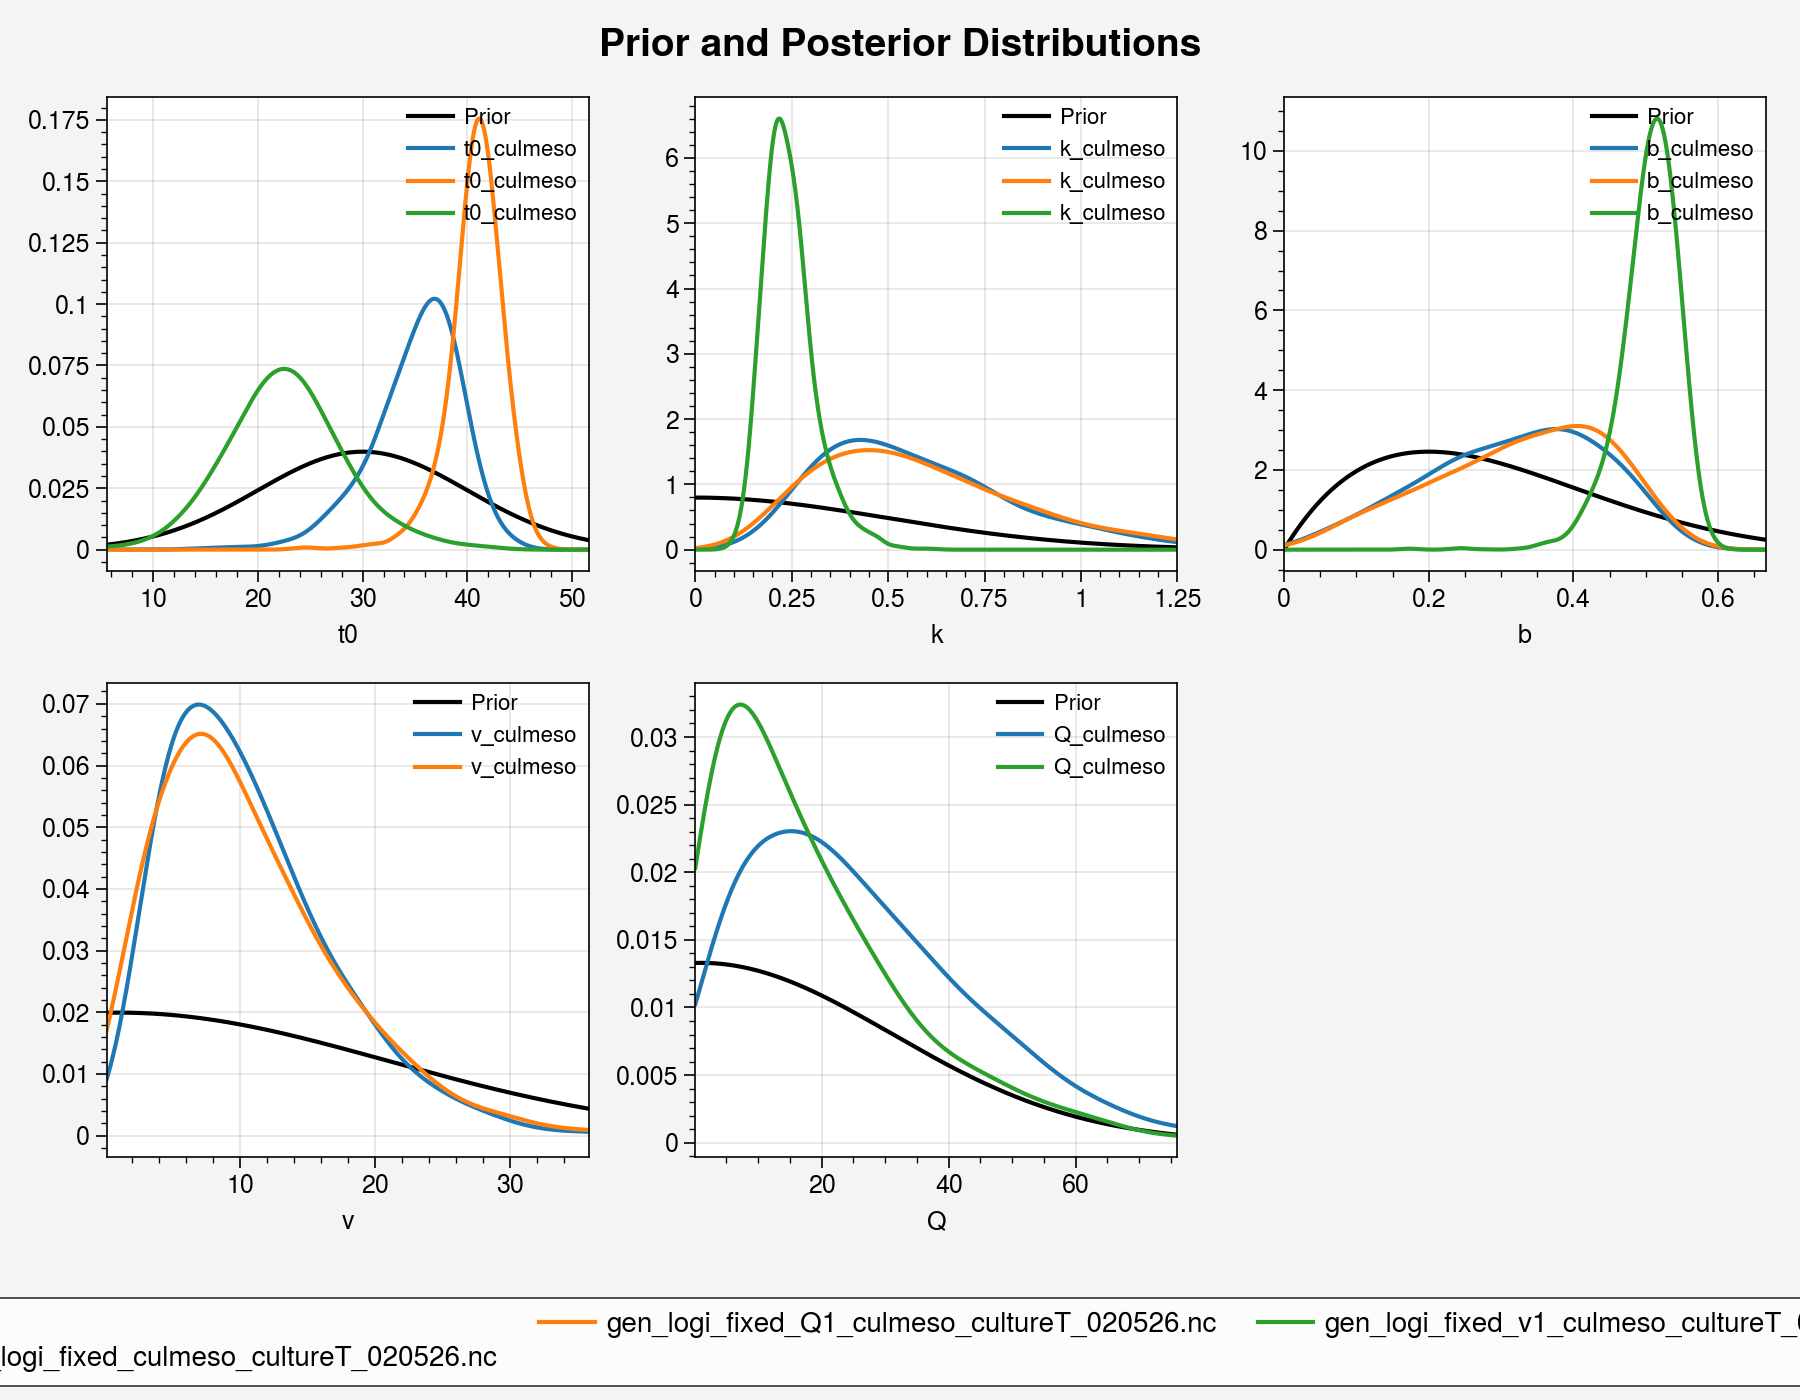

In [164]:
priors = gen_logi_fixed_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[gen_logi_fixed_cul_meso_post_ds,
                        gen_logi_fixed_Q1_cul_meso_post_ds,
                        gen_logi_fixed_v1_cul_meso_post_ds],
    use_linestyle_by_param=True,
    show_histogram=False
)

# Coretop analysis

In [165]:
coretop_df = gridded_combined_df[gridded_combined_df['datatype']=='coretop'].dropna(subset=['no3_sf2tc_avg', 'SST']).reset_index(drop=True)
coretop_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,no3_sf2tc_tc1deg04filled,ringIndex,scaledRI,t1deg_sf2tc_1deg_04filled,t_sf2pc_avg,t_sf2tc_1deg,t_sf2tc_1deg_04filled,t_sf2tc_avg,woa23_no3_sf2tc_1deg,woa23_no3_sf2tc_tc1deg04filled
0,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,28.343912,1.733369,0.433342,-1.463560,NaN,NaN,-1.463560,-1.498910,NaN,28.343912
1,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,29.035012,1.790070,0.447518,-1.530241,NaN,-1.640889,-1.640889,-1.651191,22.066089,22.066089
2,-76.125,-54.125,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.851104,0.462776,NaN,-1.578755,NaN,NaN,-1.511355,NaN,NaN
3,-76.125,-33.625,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,29.179681,1.763651,0.440913,-1.502799,NaN,-1.700194,-1.700194,-1.666310,22.080111,22.080111
4,-75.875,-29.125,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.802782,0.450695,NaN,NaN,NaN,NaN,-1.714410,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,84.125,46.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,6.726421,1.786200,0.446550,-1.595578,-1.669634,-1.546960,-1.546960,-1.237260,4.465820,4.465820
1346,84.875,40.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,6.711121,1.757545,0.439386,-1.680753,-1.728518,-1.656510,-1.656510,-1.373924,4.118705,4.118705
1347,86.875,-146.125,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,7.230052,1.599400,0.399850,-1.614439,-1.606820,-1.572210,-1.572210,-1.474355,0.480216,0.480216
1348,87.125,104.625,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,8.952294,1.732300,0.433075,0.100997,-1.758133,0.133586,0.133586,-1.377392,8.072274,8.072274


In [166]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()


data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}


stan_file_name = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_post_ds)
# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_post_ds,filename_suffix="_020526")

05:21:10 - cmdstanpy - INFO - Chain [1] start processing
05:21:10 - cmdstanpy - INFO - Chain [2] start processing
05:21:10 - cmdstanpy - INFO - Chain [3] start processing
05:21:10 - cmdstanpy - INFO - Chain [4] start processing


No gdgt23ratio data passing for multivariate model; injecting zeros.
No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1350)
   GDGT23 keys in data: [] → use_gdgt23ratio = 0
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain 

05:21:21 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 5.315 seconds (Warm-up)
Chain [3] 5.491 seconds (Sampling)
Chain [3] 10.806 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration: 1900 / 2000 [ 95%]  (Sampling)


05:21:21 - cmdstanpy - INFO - Chain [4] done processing
05:21:22 - cmdstanpy - INFO - Chain [2] done processing


...

05:21:22 - cmdstanpy - INFO - Chain [1] done processing
05:21:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_pr

Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 5.3 seconds (Warm-up)
Chain [1] 6.31 seconds (Sampling)
Chain [1] 11.61 seconds (Total)
Chain [1] 
Chain [1] 


<xarray.Dataset>
Dimensions:              (draw: 1000, chain: 4)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_crtp              (chain, draw) float64 28.45 28.33 28.48 ... 32.2 31.98
    k_crtp               (chain, draw) float64 0.2081 0.2457 ... 0.3187 0.3303
    b_crtp               (chain, draw) float64 0.4312 0.4316 ... 0.423 0.4225
    Q_crtp               (chain, draw) float64 2.994 3.784 4.12 ... 2.625 2.671
    v_crtp               (chain, draw) float64 2.166 2.501 2.585 ... 3.764 3.738
    sigma_scaledRI_crtp  (chain, draw) float64 0.05233 0.05767 ... 0.05459
    inflection_point     (chain, draw) float64 32.17 32.06 32.4 ... 36.36 35.97
Attributes: (12/30)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_univ_priorApprox_m...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_univ_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00562
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1230.28
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_020526.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_020526.nc')

In [167]:
# dropna for coretop dataset
reg_data = coretop_df[['SST', 'scaledRI']].dropna()
t_crtp = reg_data['SST'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()


data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}


stan_file_name = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
gen_logi_fixed_hier_crtp_univ_priorApprox_SST_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='SST')
display(gen_logi_fixed_hier_crtp_univ_priorApprox_SST_post_ds)
# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_univ_priorApprox_SST_post_ds,filename_suffix="_020526")

05:21:22 - cmdstanpy - INFO - Chain [1] start processing
05:21:22 - cmdstanpy - INFO - Chain [2] start processing
05:21:22 - cmdstanpy - INFO - Chain [3] start processing
05:21:22 - cmdstanpy - INFO - Chain [4] start processing


No gdgt23ratio data passing for multivariate model; injecting zeros.
No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1350)
   GDGT23 keys in data: [] → use_gdgt23ratio = 0
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain 

05:21:36 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 7.287 seconds (Warm-up)
Chain [3] 7.119 seconds (Sampling)
Chain [3] 14.406 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 1900 / 2000 [ 95%]  (Sampling)


05:21:37 - cmdstanpy - INFO - Chain [2] done processing


...

05:21:37 - cmdstanpy - INFO - Chain [4] done processing
05:21:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_p

Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 7.122 seconds (Warm-up)
Chain [4] 8.203 seconds (Sampling)
Chain [4] 15.325 seconds (Total)
Chain [4] 
Chain [4] 


<xarray.Dataset>
Dimensions:              (draw: 1000, chain: 4)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_crtp              (chain, draw) float64 31.35 32.81 32.59 ... 34.1 32.67
    k_crtp               (chain, draw) float64 0.1582 0.2264 ... 0.2306 0.1876
    b_crtp               (chain, draw) float64 0.4034 0.4121 ... 0.4087 0.411
    Q_crtp               (chain, draw) float64 2.271 2.913 3.079 ... 2.581 2.758
    v_crtp               (chain, draw) float64 2.168 3.066 3.034 ... 3.297 2.666
    sigma_scaledRI_crtp  (chain, draw) float64 0.05604 0.05594 ... 0.05821
    inflection_point     (chain, draw) float64 36.25 37.76 37.6 ... 39.27 37.9
Attributes: (12/30)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_univ_priorApprox_m...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_univ_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00167
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1252.43
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_020526.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_020526.nc')

In [168]:
coretop_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,no3_sf2tc_tc1deg04filled,ringIndex,scaledRI,t1deg_sf2tc_1deg_04filled,t_sf2pc_avg,t_sf2tc_1deg,t_sf2tc_1deg_04filled,t_sf2tc_avg,woa23_no3_sf2tc_1deg,woa23_no3_sf2tc_tc1deg04filled
0,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,28.343912,1.733369,0.433342,-1.463560,NaN,NaN,-1.463560,-1.498910,NaN,28.343912
1,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,29.035012,1.790070,0.447518,-1.530241,NaN,-1.640889,-1.640889,-1.651191,22.066089,22.066089
2,-76.125,-54.125,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.851104,0.462776,NaN,-1.578755,NaN,NaN,-1.511355,NaN,NaN
3,-76.125,-33.625,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,29.179681,1.763651,0.440913,-1.502799,NaN,-1.700194,-1.700194,-1.666310,22.080111,22.080111
4,-75.875,-29.125,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.802782,0.450695,NaN,NaN,NaN,NaN,-1.714410,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,84.125,46.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,6.726421,1.786200,0.446550,-1.595578,-1.669634,-1.546960,-1.546960,-1.237260,4.465820,4.465820
1346,84.875,40.625,Arctic Ocean,Kim2008,coretop,coretop,coretop,coretop,coretop,coretop,...,6.711121,1.757545,0.439386,-1.680753,-1.728518,-1.656510,-1.656510,-1.373924,4.118705,4.118705
1347,86.875,-146.125,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,7.230052,1.599400,0.399850,-1.614439,-1.606820,-1.572210,-1.572210,-1.474355,0.480216,0.480216
1348,87.125,104.625,Arctic Ocean,Ho2014,coretop,coretop,coretop,coretop,coretop,coretop,...,8.952294,1.732300,0.433075,0.100997,-1.758133,0.133586,0.133586,-1.377392,8.072274,8.072274


In [169]:

# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI', 'gdgt23ratio','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

no3_cutoff = 1.77
data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    "no3_crtp": no3_crtp,
    "no3_cutoff": no3_cutoff, ## set to -1 to not use no3

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}


stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds,filename_suffix="_020526")

05:21:37 - cmdstanpy - INFO - Chain [1] start processing
05:21:37 - cmdstanpy - INFO - Chain [2] start processing
05:21:37 - cmdstanpy - INFO - Chain [3] start processing
05:21:37 - cmdstanpy - INFO - Chain [4] start processing


🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1350)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    ['no3_crtp', 'no3_cutoff'] → use_no3 = 1
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain 

05:22:11 - cmdstanpy - INFO - Chain [4] done processing
05:22:11 - cmdstanpy - INFO - Chain [1] done processing


Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 16.255 seconds (Warm-up)
Chain [4] 17.127 seconds (Sampling)
Chain [4] 33.382 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] 
Chain [1] Elapsed Time: 15.76 seconds (Warm-up)
Chain [1] 17.636 seconds (Sampling)
Chain [1] 33.396 seconds (Total)
Chain [1] 
Chain [1] 
Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)


05:22:12 - cmdstanpy - INFO - Chain [2] done processing


...

05:22:13 - cmdstanpy - INFO - Chain [3] done processing
05:22:13 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)


Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 18.021 seconds (Warm-up)
Chain [3] 17.928 seconds (Sampling)
Chain [3] 35.949 seconds (Total)
Chain [3] 
Chain [3] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 33.28 34.05 ... 31.24 32.52
    k_crtp                  (chain, draw) float64 0.2548 0.3048 ... 0.2159
    b_crtp                  (chain, draw) float64 0.4429 0.4329 ... 0.4428
    Q_crtp                  (chain, draw) float64 2.006 1.803 ... 2.771 1.675
    v_crtp                  (chain, draw) float64 3.306 4.13 ... 2.912 2.75
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.00568 ... -0.006348
    beta0_no3_crtp          (chain, draw) float64 -0.03335 -0.0265 ... -0.02802
    sigma_scaledRI_crtp     (chain, draw) float64 0.04796 0.04987 ... 0.05046
Attributes: (12/43)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00234
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1507.79
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.77_020526.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.77_020526.nc')

In [170]:

# dropna for coretop dataset
reg_data = coretop_df[['SST', 'scaledRI', 'gdgt23ratio','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['SST'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

no3_cutoff = 1.77
data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    "no3_crtp": no3_crtp,
    "no3_cutoff": no3_cutoff, ## set to -1 to not use no3

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}


stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
gen_logi_fixed_hier_crtp_priorApprox_SST_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='SST')
display(gen_logi_fixed_hier_crtp_priorApprox_SST_multiv_g23r_no3_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_priorApprox_SST_multiv_g23r_no3_post_ds,filename_suffix="_020526")

05:22:14 - cmdstanpy - INFO - Chain [1] start processing
05:22:14 - cmdstanpy - INFO - Chain [2] start processing
05:22:14 - cmdstanpy - INFO - Chain [3] start processing
05:22:14 - cmdstanpy - INFO - Chain [4] start processing


🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1350)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    ['no3_crtp', 'no3_cutoff'] → use_no3 = 1
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain 

05:22:47 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 17.181 seconds (Warm-up)
Chain [2] 15.887 seconds (Sampling)
Chain [2] 33.068 seconds (Total)
Chain [2] 
Chain [2] 


05:22:47 - cmdstanpy - INFO - Chain [4] done processing
05:22:47 - cmdstanpy - INFO - Chain [3] done processing


...

05:22:50 - cmdstanpy - INFO - Chain [1] done processing
05:22:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 70, column 4 to column 66)


Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 17.174 seconds (Warm-up)
Chain [1] 19.072 seconds (Sampling)
Chain [1] 36.246 seconds (Total)
Chain [1] 
Chain [1] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 32.31 32.5 ... 32.78 31.73
    k_crtp                  (chain, draw) float64 0.1668 0.191 ... 0.1536 0.2049
    b_crtp                  (chain, draw) float64 0.4314 0.4209 ... 0.4279
    Q_crtp                  (chain, draw) float64 2.279 3.35 ... 2.187 3.719
    v_crtp                  (chain, draw) float64 2.44 3.087 ... 2.431 3.052
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.006569 ... -0.005957
    beta0_no3_crtp          (chain, draw) float64 -0.03248 -0.03892 ... -0.03183
    sigma_scaledRI_crtp     (chain, draw) float64 0.04939 0.04932 ... 0.04952
Attributes: (12/43)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00153
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1467.52
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.77_020526.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.77_020526.nc')

# Figures for manuscript

### Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [171]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

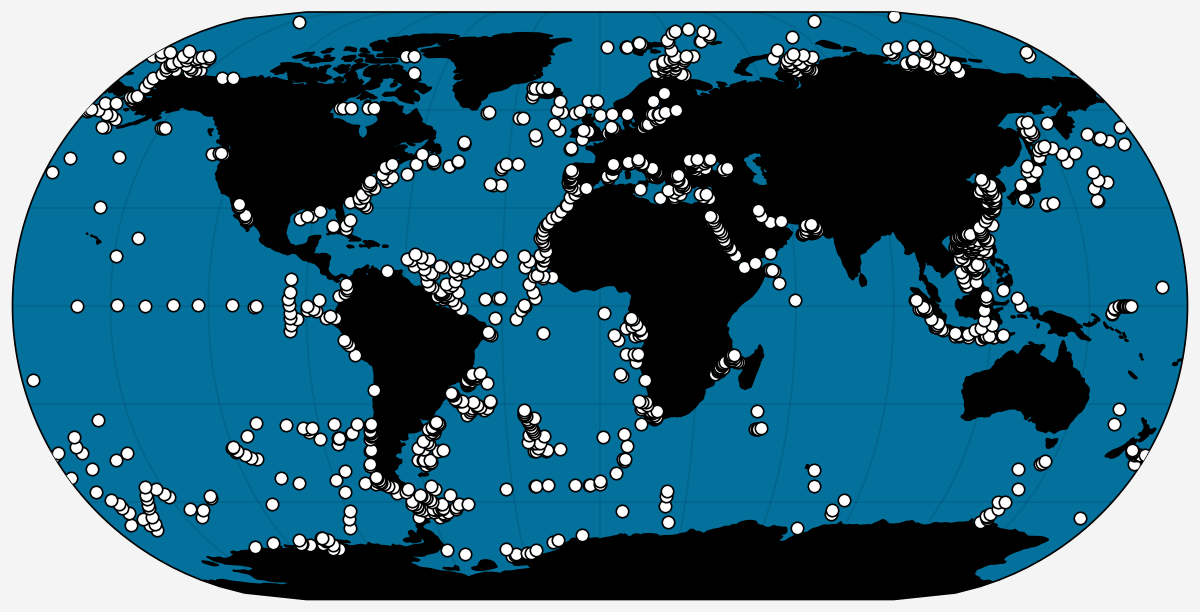

In [172]:
fig, ax = plot.subplots(width=6,proj='eck3',
                        # proj_kw={'lon_0':-150}
                        )
ax.format(
    land=True,landzorder=0,
    facecolor='ocean blue',
    # landcolor='gray7',
    coast=True,coastzorder=1,
    lonlines=30,
    latlines=30,
    # lonlabels='b',
    # latlabels='l',
    # title='Coretop locations',
)

plot_lat = coretop_df['match_lat_04deg']
plot_lon = coretop_df['match_lon_04deg']
ax.scatter(plot_lon, plot_lat, s=20, color='w', mec='k', facecolor='none', zorder=5)
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'coretop_locations_woa23_t00_04degC.pdf'),dpi=300,
            transparent=True)

# Posterior plots --- QC

DEBUG: use_gdgt23ratio detected
DEBUG: use_no3 detected
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Param groups:  ['t0', 'k', 'b', 'v', 'Q', 'beta0_gdgt23ratio', 'beta0_no3']
figure nrows, ncols: 3, 3


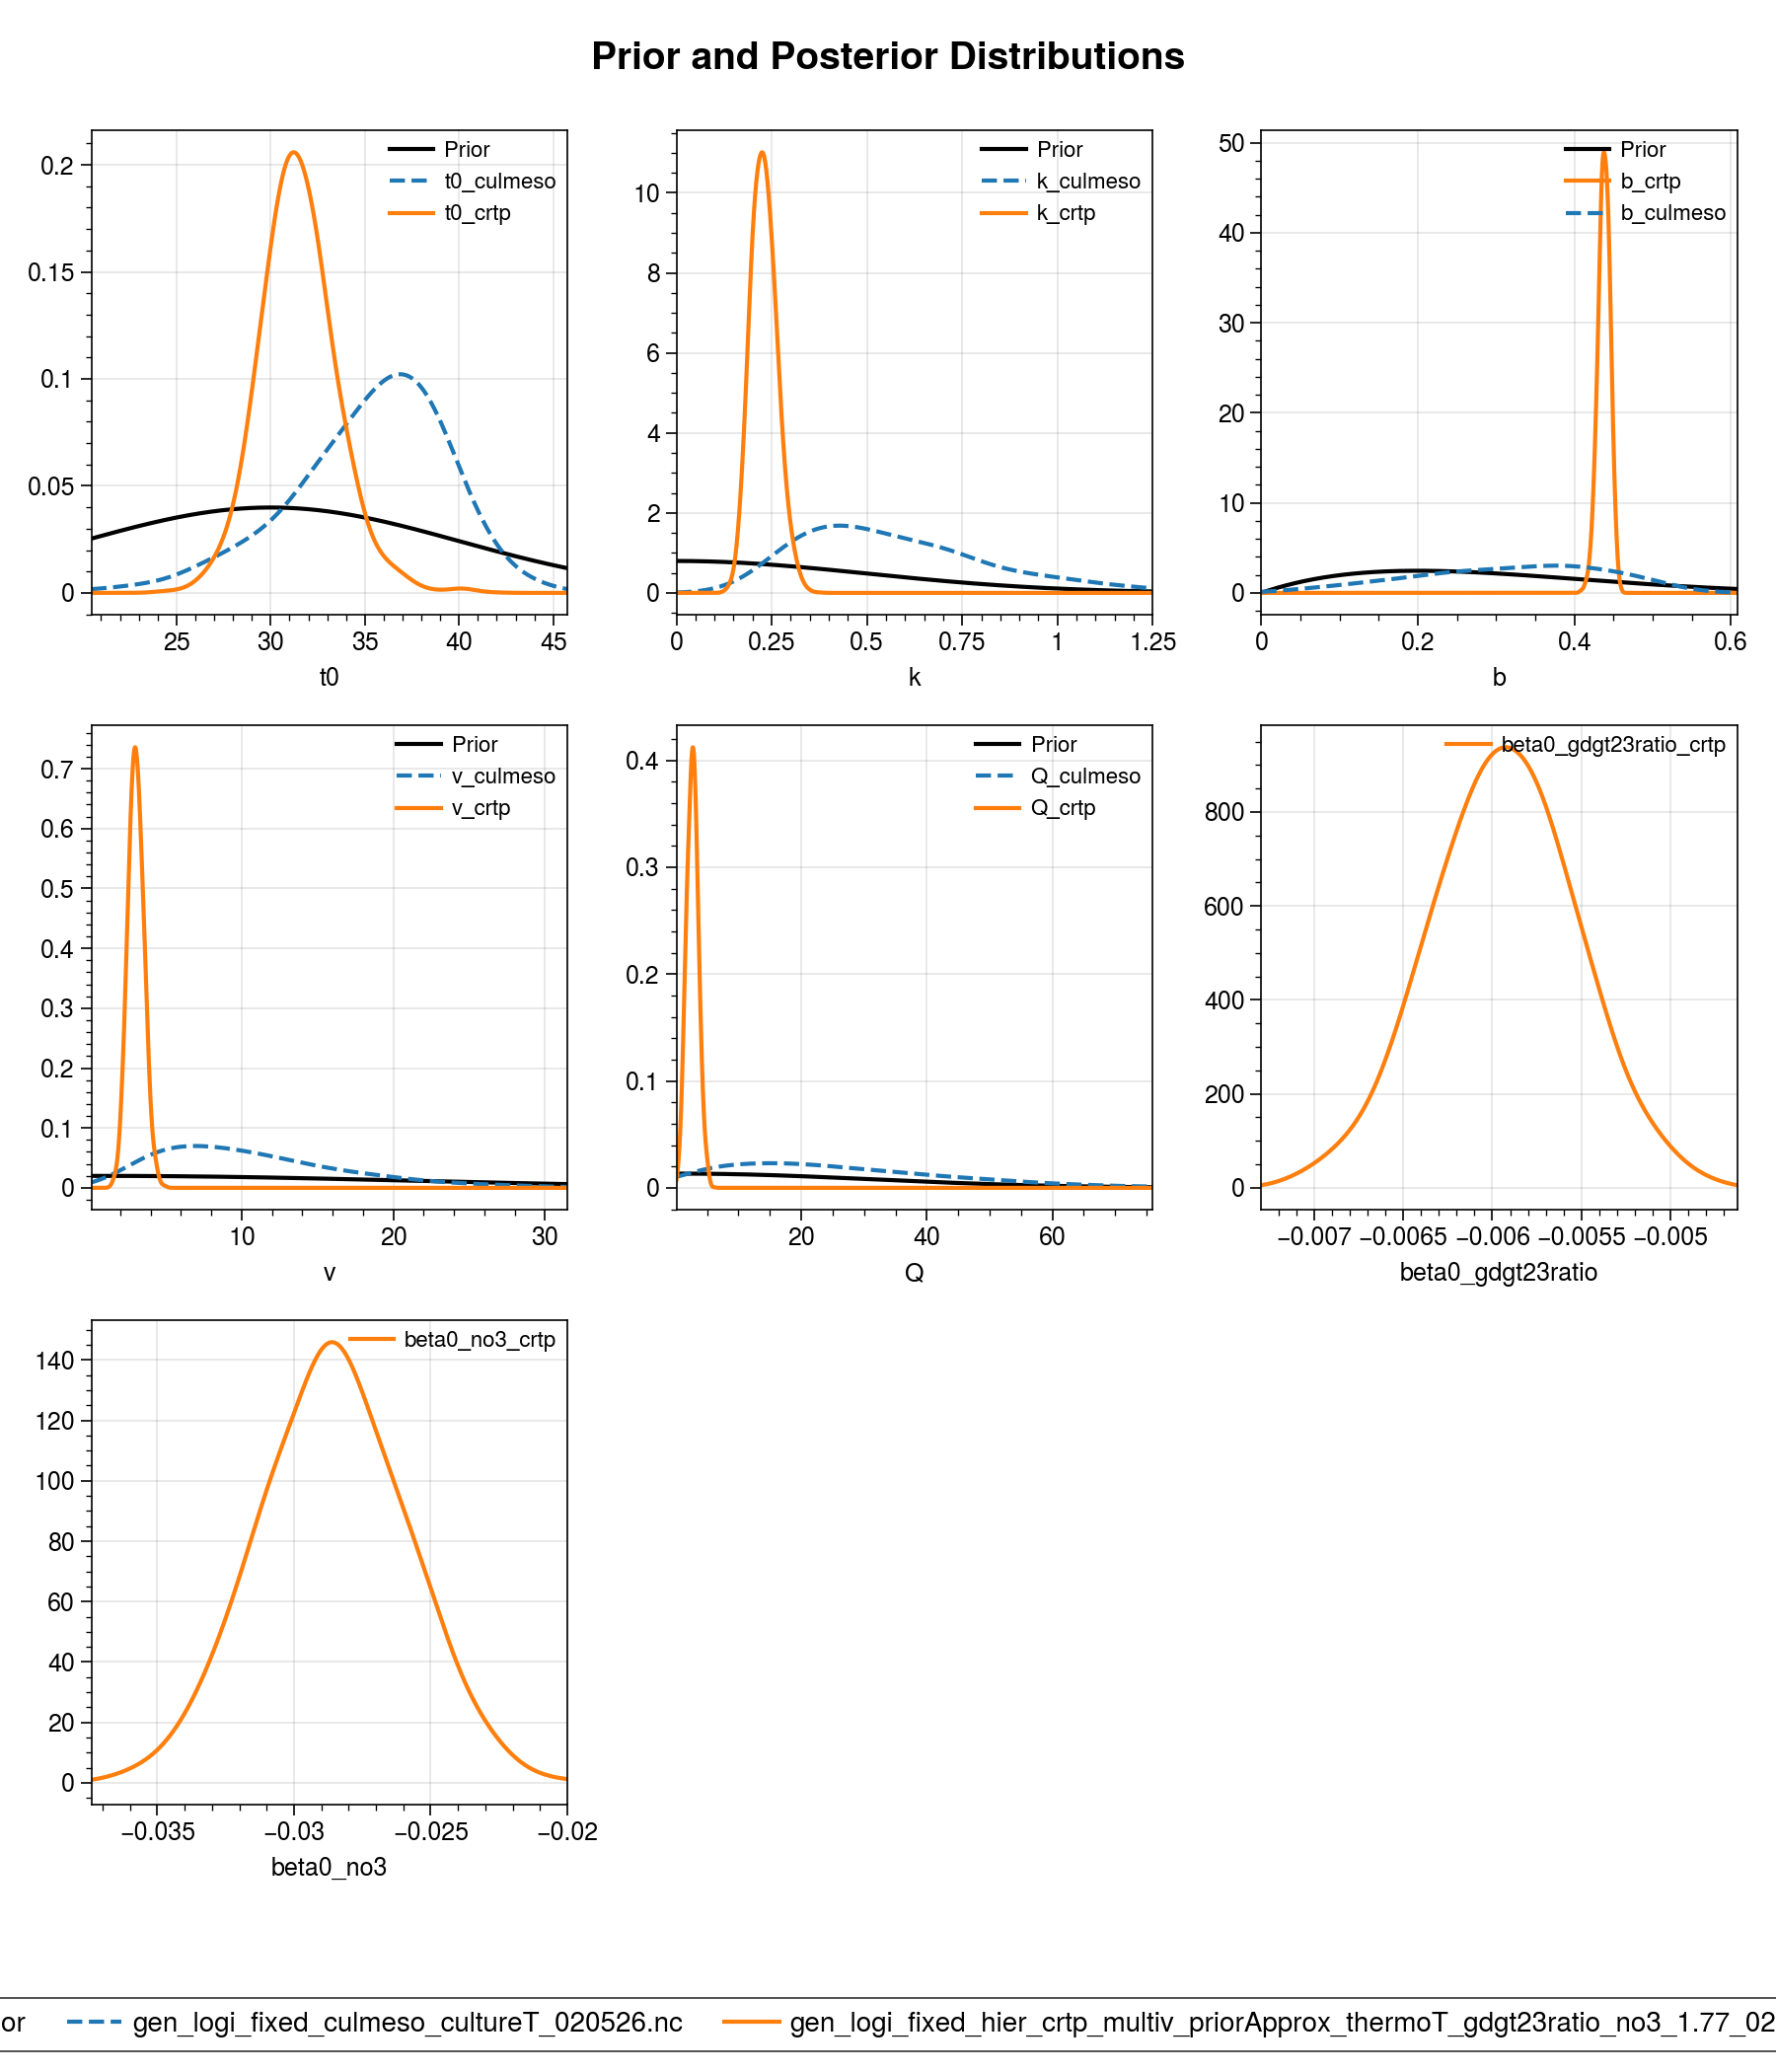

In [173]:
priors = gen_logi_fixed_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[gen_logi_fixed_cul_meso_post_ds,
                        gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds],
    use_linestyle_by_param=True,
    show_histogram=False,
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'prior_distributions.pdf'),dpi=300)

In [174]:
plot_culmeso_df = gridded_combined_df[gridded_combined_df['datatype'].isin(['culture','mesocosm'])].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
pred_scaledRI_culmeso_results = generate_ensemble_auto(
    post_ds = gen_logi_fixed_cul_meso_post_ds,
    x_vals = plot_culmeso_df['SST'].values,
    percentiles=[2.5,50,97.5],
)
plot_culmeso_df['pred_scaledRI'] = pred_scaledRI_culmeso_results['p50']

In [175]:
plot_coretop_df = coretop_df
pred_scaledRI_crtp_results = generate_ensemble_auto(
    post_ds = gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds,
    x_vals = plot_coretop_df['t_sf2tc_avg'].values,
    gdgt23ratio = plot_coretop_df['gdgt23ratio'].values,
    no3 = plot_coretop_df['no3_sf2tc_avg'].values,
    no3_cutoff = 1.77,
    percentiles=[2.5,50,97.5],
)
plot_coretop_df['pred_scaledRI'] = pred_scaledRI_crtp_results['p50']
plot_coretop_df['residual_scaledRI'] = plot_coretop_df['scaledRI'] - plot_coretop_df['pred_scaledRI']


t0_culmeso: mean=35.0932, sd=4.4931
k_culmeso: mean=0.5775, sd=0.2526
Q_culmeso: mean=25.7941, sd=17.9449
v_culmeso: mean=10.6713, sd=6.1780
b_culmeso: mean=0.3191, sd=0.1184


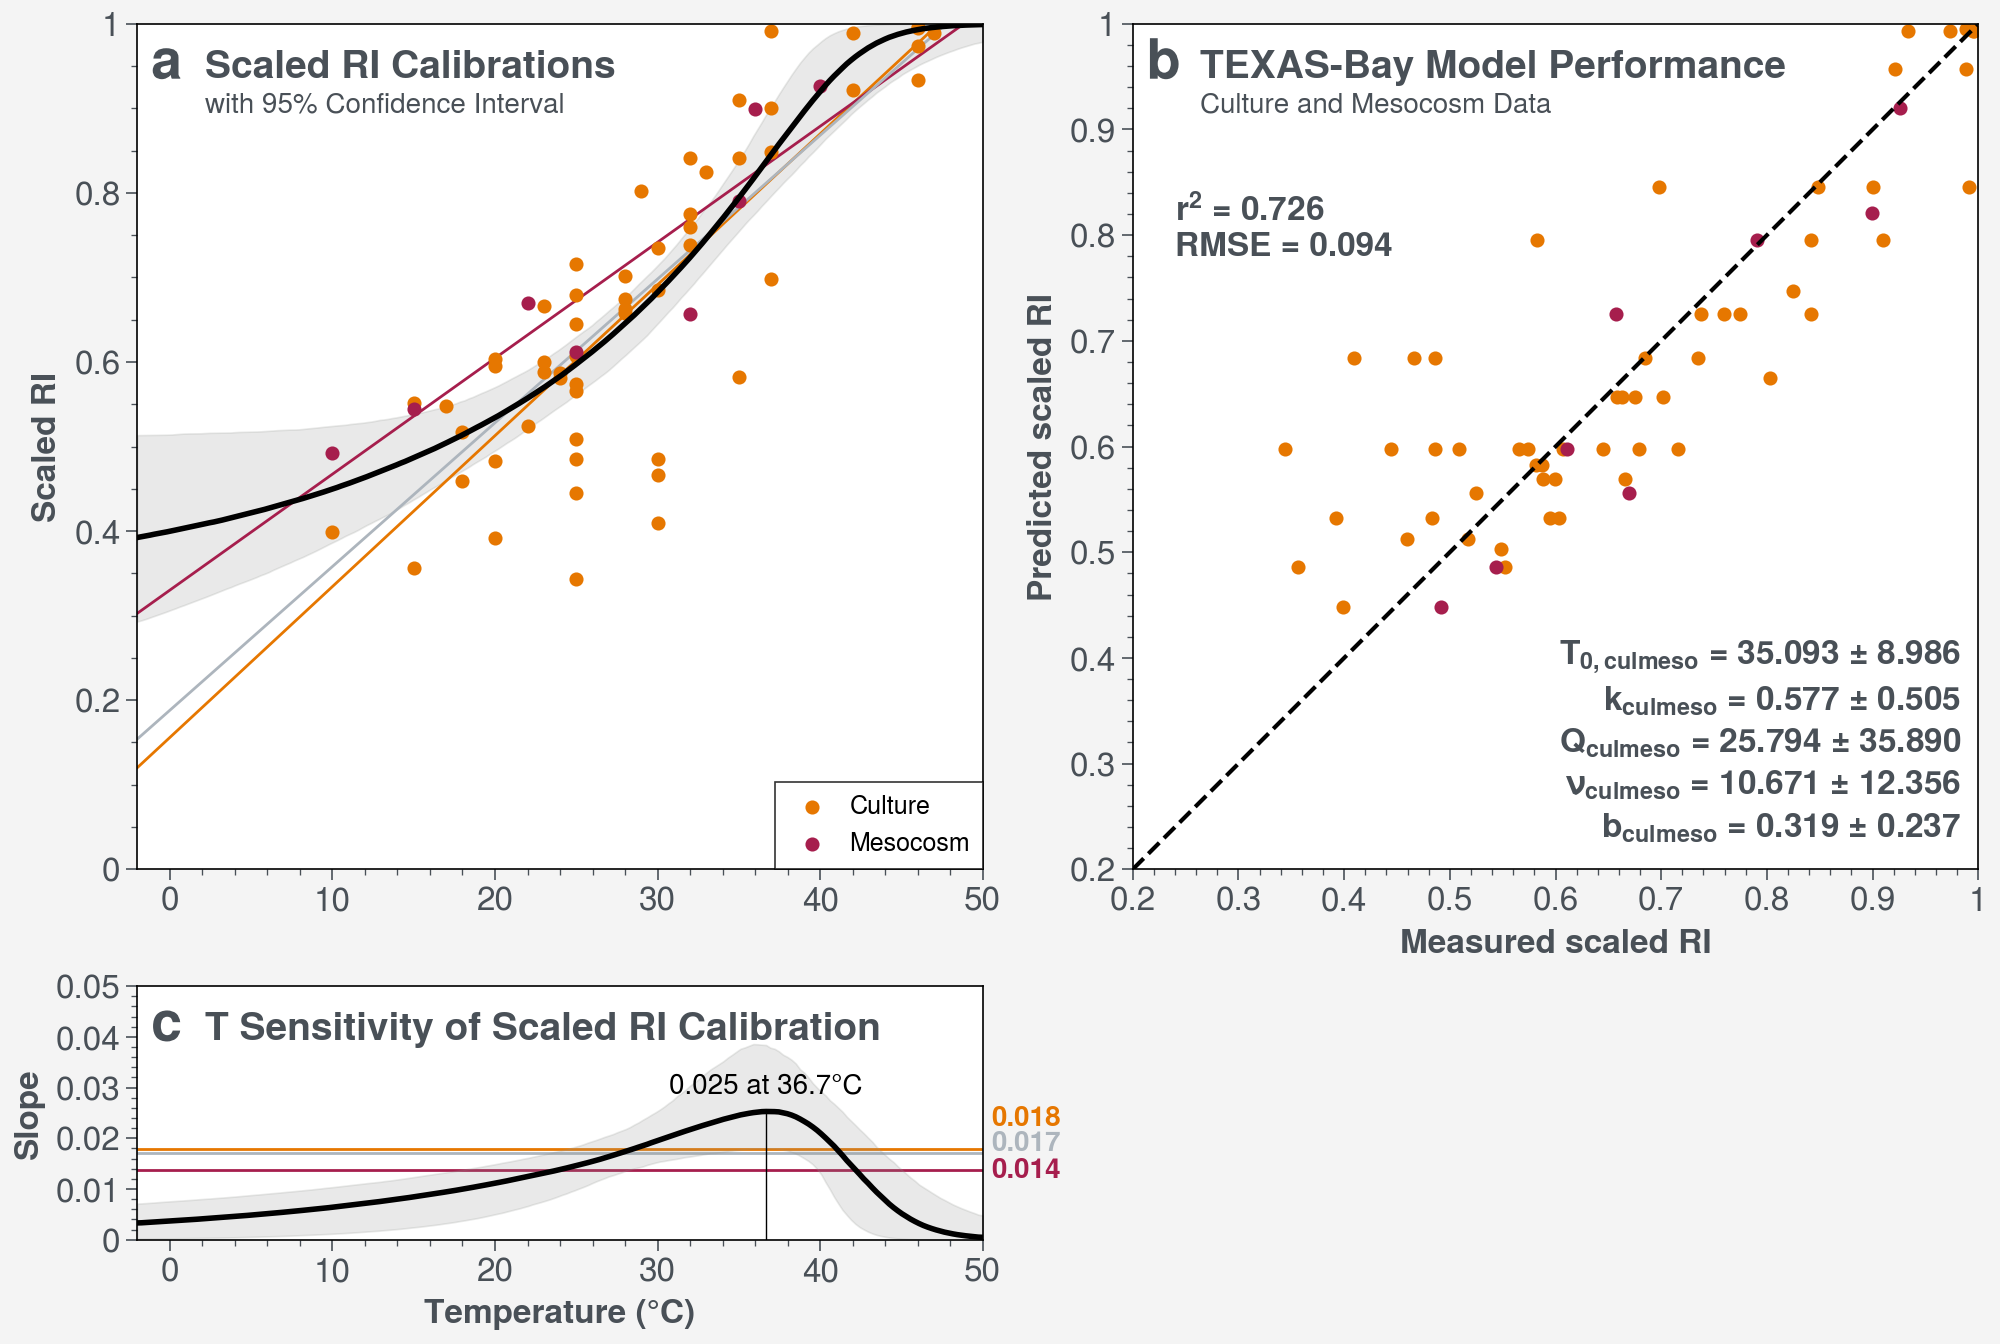

In [176]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_culmeso_df
XX = np.linspace(-2,50,200)

grouped = plot_data.groupby('datatype')
for name, group in grouped:
    plot_x = group['SST']
    plot_y = group['scaledRI']
    axs[0,0].scatter(plot_x, plot_y, s=20,
               c=datatype_color_dict.get(name))
    
    plot_x = group['scaledRI']
    plot_y = group['pred_scaledRI']
    axs[0,1].scatter(plot_x, plot_y, s=20,
               c=datatype_color_dict.get(name))
    
    ### linear regression line for each datatype with 95% CI shading
    from sklearn.linear_model import LinearRegression
    from sklearn.utils import resample
    
    model = LinearRegression()
    X = group['SST'].values.reshape(-1, 1)
    y = group['scaledRI'].values
    model.fit(X, y)
    x_range = XX.reshape(-1, 1)
    y_pred = model.predict(x_range)
    axs[0,0].plot(x_range, y_pred, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    slope = model.coef_[0]
    axs[1,0].axhline(slope, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    # ### Bootstrap for 95% CI
    # n_bootstraps = 1000
    # y_preds_bootstrap = np.zeros((n_bootstraps, len(x_range)))
    # for i in range(n_bootstraps):
    #     X_resampled, y_resampled = resample(X, y, random_state=i)
    #     model.fit(X_resampled, y_resampled)
    #     y_preds_bootstrap[i] = model.predict(x_range).flatten()
    
    # # Calculate 95% CI from bootstrap samples
    # ci_lower = np.percentile(y_preds_bootstrap, 2.5, axis=0)
    # ci_upper = np.percentile(y_preds_bootstrap, 97.5, axis=0)
    # axs[0,0].fill_between(x_range.flatten(), ci_lower, ci_upper, 
    #                       color=datatype_color_dict.get(name), alpha=0.1,
    #                       zorder=0)
    
    ### write out slope (T sensitivity) value with plus/minus 95% CI values
    # slope_bootstrap = (y_preds_bootstrap[:, -1] - y_preds_bootstrap[:, 0]) / (x_range[-1] - x_range[0])
    # slope_median = np.median(slope_bootstrap)
    # slope_ci_lower = np.percentile(slope_bootstrap, 2.5)
    # slope_ci_upper = np.percentile(slope_bootstrap, 97.5)
    text = f"{slope:.3f}"#+r" $\pm$"+f" {slope_ci_upper - slope_median:.3f}"
    
    y_adjust = 0.006 if name=='culture' else 0
    axs[1,0].text(1.01, slope + y_adjust, text,
                  transform=axs[1,0].get_yaxis_transform(),
                  ha = 'left', verticalalignment='center',
                  fontsize=10,fontweight='bold',
                  color=datatype_color_dict.get(name))
    
### OLS regression of the culture + mesocosm data together
model = LinearRegression()
X = plot_data['SST'].values.reshape(-1, 1)
y = plot_data['scaledRI'].values
model.fit(X, y)
x_range = XX.reshape(-1, 1)
y_pred = model.predict(x_range)
axs[0,0].plot(x_range, y_pred, color='gray5', lw=1, zorder=0, label='OLS all data')

slope = model.coef_[0]
axs[1,0].axhline(slope, color='gray5', lw=1, zorder=0)

# ### Bootstrap for 95% CI
# n_bootstraps = 1000
# y_preds_bootstrap = np.zeros((n_bootstraps, len(x_range)))
# for i in range(n_bootstraps):
#     X_resampled, y_resampled = resample(X, y, random_state=i)
#     model.fit(X_resampled, y_resampled)
#     y_preds_bootstrap[i] = model.predict(x_range).flatten()
# # Calculate 95% CI from bootstrap samples
# ci_lower = np.percentile(y_preds_bootstrap, 2.5, axis=0)
# ci_upper = np.percentile(y_preds_bootstrap, 97.5, axis=0)
# axs[0,0].fill_between(x_range.flatten(), ci_lower, ci_upper, 
#                       color='gray5', alpha=0.1,
#                       zorder=0)
# slope_bootstrap = (y_preds_bootstrap[:, -1] - y_preds_bootstrap[:, 0]) / (x_range[-1] - x_range[0])
# slope_median = np.median(slope_bootstrap)
# slope_ci_lower = np.percentile(slope_bootstrap, 2.5)
# slope_ci_upper = np.percentile(slope_bootstrap, 97.5)
text = f"{slope:.3f}"#+r" $\pm$"+f" {slope_ci_upper - slope_median:.3f}"
y_adjust = 0.002
axs[1,0].text(1.01, slope + y_adjust, text,
              transform=axs[1,0].get_yaxis_transform(),
              ha = 'left', verticalalignment='center',
              fontsize=10,fontweight='bold',
              color='gray5')


### Plot posterior ensemble with credible intervals

def generalized_logistic_model_fixed_upper_Q1(x, x0, b, k, v):
    return generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q=1)

def generalized_logistic_model_fixed_upper_v1(x, x0, b, k, Q):
    return generalized_logistic_model_fixed_upper(x, x0, b, k, v=1, Q=Q)

# Get all samples
t0_samples = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].values.flatten()
b_samples = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].values.flatten()
k_samples = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].values.flatten()
v_samples = gen_logi_fixed_cul_meso_post_ds["v_culmeso"].values.flatten()
Q_samples = gen_logi_fixed_cul_meso_post_ds["Q_culmeso"].values.flatten()

# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
        Q=Q_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_95_low = np.percentile(all_curves, 2.5, axis=0)
ci_95_high = np.percentile(all_curves, 97.5, axis=0)
# ci_50_low = np.percentile(all_curves, 25, axis=0)
# ci_50_high = np.percentile(all_curves, 75, axis=0)

# Plot
axs[0,0].fill_between(XX, ci_95_low, ci_95_high, alpha=0.2, color='gray', 
                     label='95% CI', zorder=0)
# axs[0,0].fill_between(XX, ci_50_low, ci_50_high, alpha=0.3, color='gray', 
#                      label='50% CI', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)

# # Add random sample lines on top
# n_lines = 20
# np.random.seed(42)  # For reproducibility
# rand_indices = np.random.choice(len(t0_samples), size=n_lines, replace=False)
# for idx in rand_indices:
#     axs[0,0].plot(XX, all_curves[idx], c='gray9', lw=0.1,  zorder=0)

# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_95_low = np.percentile(all_slopes, 2.5, axis=0)
ci_95_high = np.percentile(all_slopes, 97.5, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_95_low, ci_95_high, alpha=0.2, color='gray', label='95% CI')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)
### published T sentitivity lines from literature

# ax.axhline(0.015, ls=':', c='k', lw=1, label='Wuchter et al. (2004)')
###################### Try en_logi_fixed_Q1_cul_meso_post_ds

# t0_samples_Q1 = gen_logi_fixed_Q1_cul_meso_post_ds["t0_culmeso"].values.flatten()
# b_samples_Q1 = gen_logi_fixed_Q1_cul_meso_post_ds["b_culmeso"].values.flatten()
# k_samples_Q1 = gen_logi_fixed_Q1_cul_meso_post_ds["k_culmeso"].values.flatten()
# v_samples_Q1 = gen_logi_fixed_Q1_cul_meso_post_ds["v_culmeso"].values.flatten()

# # Calculate curves for ALL posterior samples
# all_slopes_Q1 = []
# all_curves_Q1 = []
# for i in range(len(t0_samples_Q1)):
#     curve = generalized_logistic_model_fixed_upper_Q1(
#         XX,
#         x0=t0_samples_Q1[i],
#         b=b_samples_Q1[i],
#         k=k_samples_Q1[i],
#         v=v_samples_Q1[i],
#     )
#     all_curves_Q1.append(curve)
    
#     # Calculate numerical derivative (slope)
#     slope = np.gradient(curve, XX)
#     all_slopes_Q1.append(slope)
    
# all_curves_Q1 = np.array(all_curves_Q1)  # Shape: (n_samples, len(XX))
# all_slopes_Q1 = np.array(all_slopes_Q1)  # Shape: (n_lines, len(XX))
# # Plot credible intervals
# median_curve_Q1 = np.median(all_curves_Q1, axis=0)
# ci_95_low_Q1 = np.percentile(all_curves_Q1, 2.5, axis=0)
# ci_95_high_Q1 = np.percentile(all_curves_Q1, 97.5, axis=0)
# axs[0,0].fill_between(XX, ci_95_low_Q1, ci_95_high_Q1, alpha=0.2, color='k', 
#                      label='95% CI (Q=1)', zorder=0)
# axs[0,0].plot(XX, median_curve_Q1, 'k-', lw=2, label='Median (Q=1)', zorder=1)

# median_slope_Q1 = np.median(all_slopes_Q1, axis=0)
# ci_95_low_Q1 = np.percentile(all_slopes_Q1, 2.5, axis=0)
# ci_95_high_Q1 = np.percentile(all_slopes_Q1, 97.5, axis=0)
# # Plot slope vs temperature
# axs[1,0].fill_between(XX, ci_95_low_Q1, ci_95_high_Q1, alpha=0.3, color='k', label='95% CI (Q=1)')
# axs[1,0].plot(XX, median_slope_Q1, c='k', lw=2, label='Median slope (Q=1)')

# ###################### Try en_logi_fixed_v1_cul_meso_post_ds
# t0_samples_v1 = gen_logi_fixed_v1_cul_meso_post_ds["t0_culmeso"].values.flatten()
# b_samples_v1 = gen_logi_fixed_v1_cul_meso_post_ds["b_culmeso"].values.flatten()
# k_samples_v1 = gen_logi_fixed_v1_cul_meso_post_ds["k_culmeso"].values.flatten()
# Q_samples_v1 = gen_logi_fixed_v1_cul_meso_post_ds["Q_culmeso"].values.flatten()
# # Calculate curves for ALL posterior samples
# all_slopes_v1 = []
# all_curves_v1 = []
# for i in range(len(t0_samples_v1)):
#     curve = generalized_logistic_model_fixed_upper_v1(
#         XX,
#         x0=t0_samples_v1[i],
#         b=b_samples_v1[i],
#         k=k_samples_v1[i],
#         Q=Q_samples_v1[i],
#     )
#     all_curves_v1.append(curve)
    
#     # Calculate numerical derivative (slope)
#     slope = np.gradient(curve, XX)
#     all_slopes_v1.append(slope)
    
# all_curves_v1 = np.array(all_curves_v1)  # Shape: (n_samples, len(XX))
# all_slopes_v1 = np.array(all_slopes_v1)  # Shape: (n_lines, len(XX))
# # Plot credible intervals
# median_curve_v1 = np.median(all_curves_v1, axis=0)
# ci_95_low_v1 = np.percentile(all_curves_v1, 2.5, axis=0)
# ci_95_high_v1 = np.percentile(all_curves_v1, 97.5, axis=0)
# axs[0,0].fill_between(XX, ci_95_low_v1, ci_95_high_v1, alpha=0.2, color='green', 
#                      label='95% CI (v=1)', zorder=0)
# axs[0,0].plot(XX, median_curve_v1, 'g-', lw=2, label='Median (v=1)', zorder=1)

# median_slope_v1 = np.median(all_slopes_v1, axis=0)
# ci_95_low_v1 = np.percentile(all_slopes_v1, 2.5, axis=0)
# ci_95_high_v1 = np.percentile(all_slopes_v1, 97.5, axis=0)
# # Plot slope vs temperature
# axs[1,0].fill_between(XX, ci_95_low_v1, ci_95_high_v1, alpha=0.3, color='green', label='95% CI (v=1)')
# axs[1,0].plot(XX, median_slope_v1, c='green', lw=2, label='Median slope (v=1)')

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

r_squared_culmeso = r2_score(
    plot_data['scaledRI'],
    plot_data['pred_scaledRI']
)

rmse_culmeso = mean_squared_error(
    plot_data['scaledRI'],
    plot_data['pred_scaledRI']
)
text = f'r$^2$ = {r_squared_culmeso:.3f}\nRMSE = {np.sqrt(rmse_culmeso):.3f}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_culmeso': r'$T_{0,culmeso}$',
    'k_culmeso': r'$k_{culmeso}$',
    'b_culmeso': r'$b_{culmeso}$',
    'Q_culmeso': r'$Q_{culmeso}$',
    'v_culmeso': r'$\nu_{culmeso}$',
}
### Posterior sec
var_list = [var_name for var_name in gen_logi_fixed_cul_meso_post_ds.data_vars if (('culmeso' in var_name) & ~('sigma_' in var_name))]
for var in var_list:
    var_samples = gen_logi_fixed_cul_meso_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={var_mean:.4f}, sd={var_sd:.4f}")
    
    text = f"{param_label_dict.get(var,var)} = {var_mean:.3f} ± {2*var_sd:.3f}"
    ax.text(0.98, 0.23 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--')
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured scaled RI',
           ylabel='Predicted scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = 'with 95% Confidence Interval'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS-Bay Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Culture and Mesocosm Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')

h, l = axs[0,0].get_legend_handles_labels()
axs[0,0].legend(h[2:4], ['Culture','Mesocosm'], 
                ncol=1,
                fontsize=10, loc='lower right')



###########
plot.rc['abc']=True
axs[:3].format(grid=False,
           abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
           fontsize=12,labelsize=12,
           labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
           xticklabelcolor='gray7',yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold', )


axs[1,1].axis('off')
plot.rc['abc']=False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig8_scaledRI_culmeso_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

t0_crtp: mean=31.4652, sd=2.0457
k_crtp: mean=0.2297, sd=0.0341
b_crtp: mean=0.4377, sd=0.0077
Q_crtp: mean=2.6687, sd=0.9215
v_crtp: mean=3.0327, sd=0.5200
beta0_gdgt23ratio_crtp: mean=-0.0059, sd=0.0004
beta0_no3_crtp: mean=-0.0286, sd=0.0027


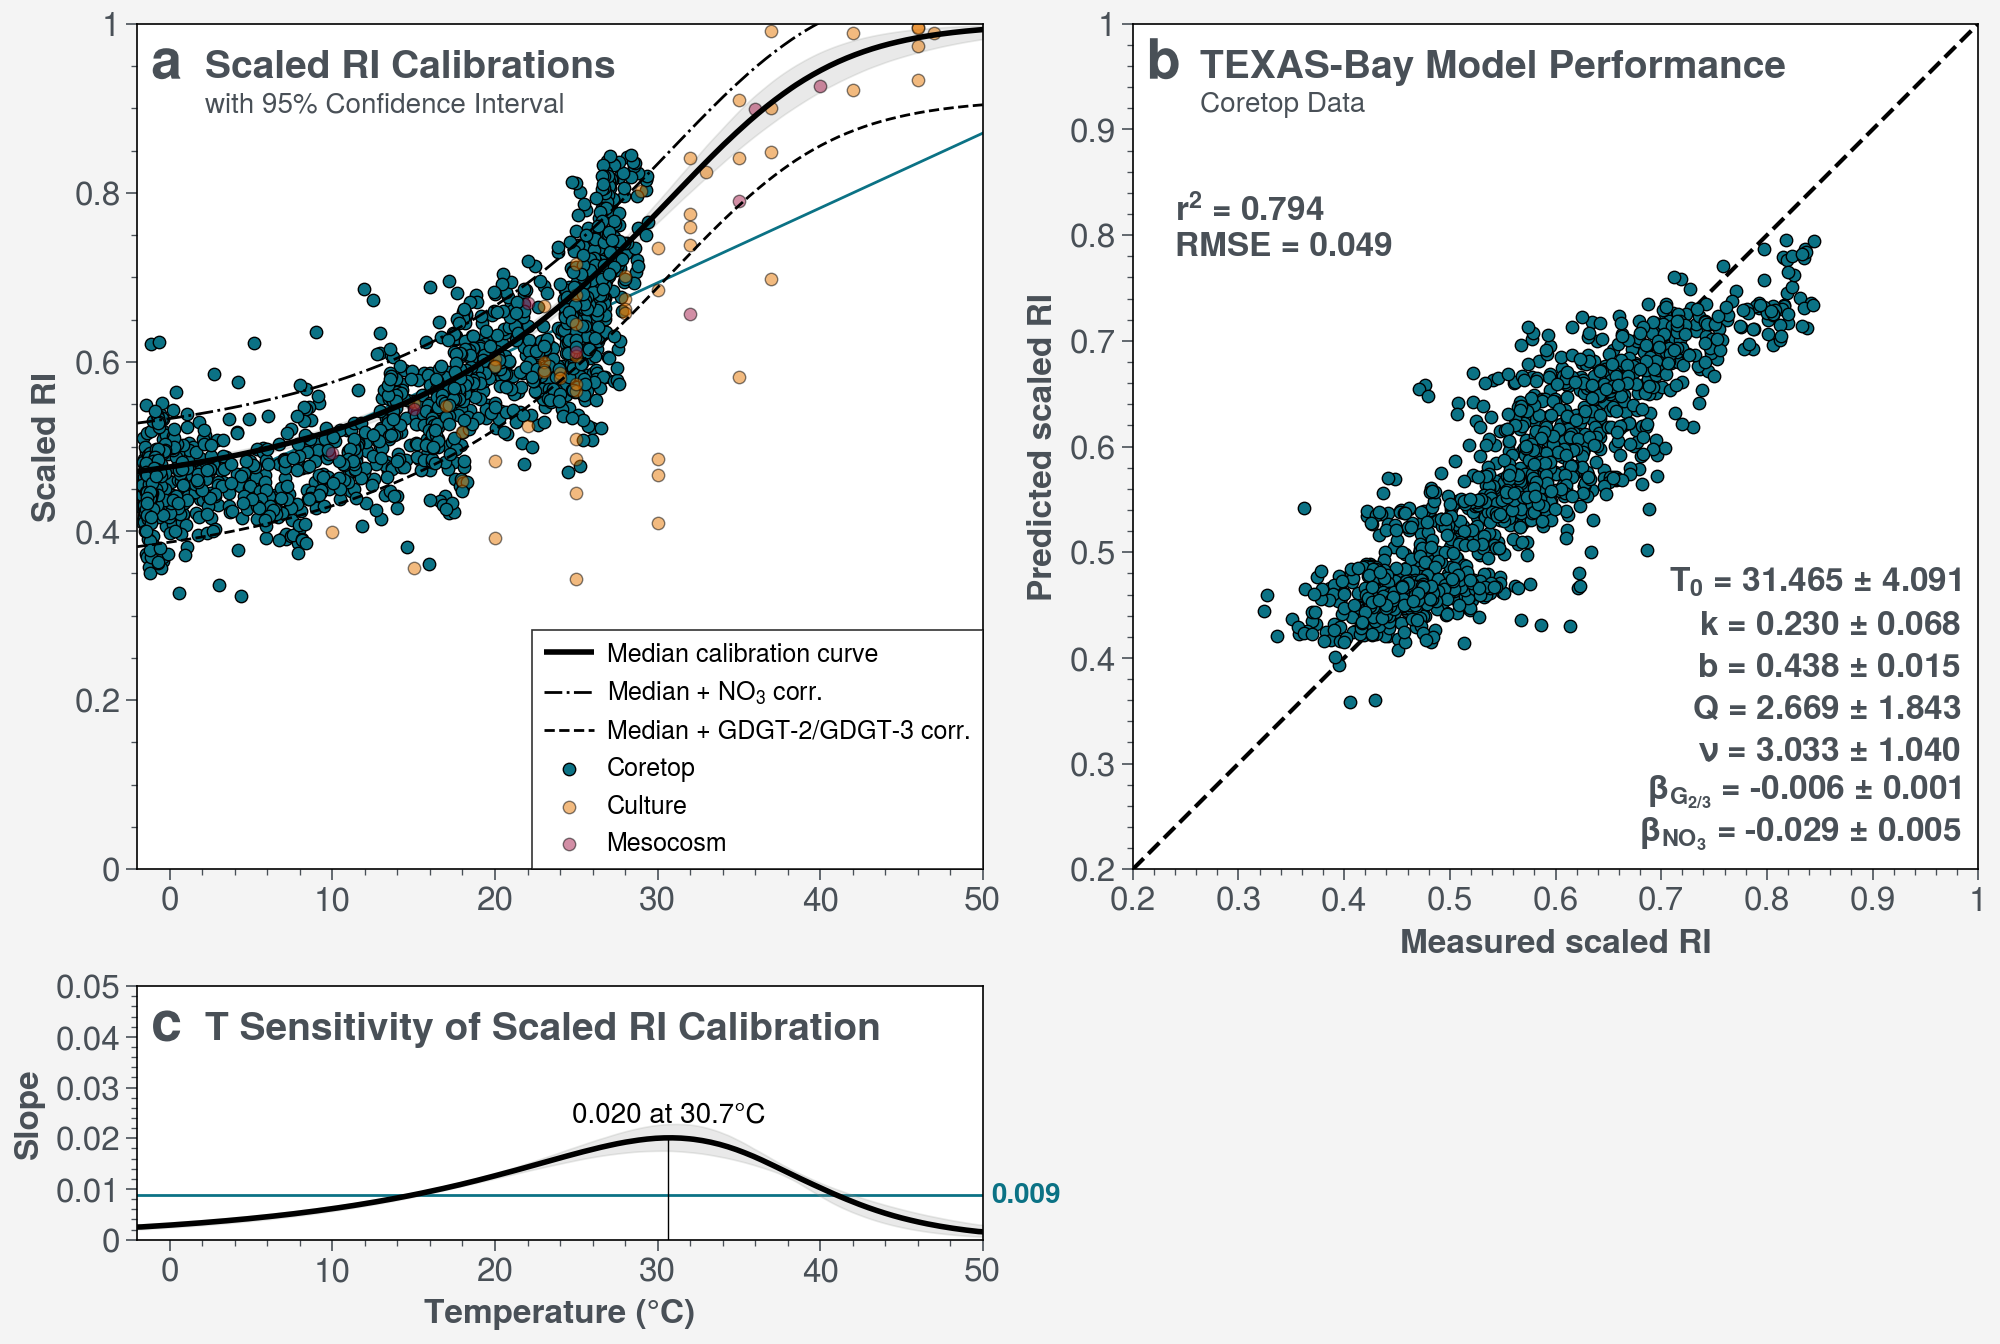

In [177]:
fig, axs = plot.subplots(width=10,ncols=2,nrows=2,
                         share=0,wspace=6,
                         hratios=[1,0.3])
plot_data = plot_coretop_df
XX = np.linspace(-2,50,200)

grouped = gridded_combined_df.groupby('datatype')
for name, group in grouped:
    plot_x = group['t_sf2tc_avg']
    plot_y = group['scaledRI']
    axs[0,0].scatter(plot_x, plot_y, s=20,
            mec='k', lw=0.5,
            c=datatype_color_dict.get(name),
            alpha=0.5 if name!='coretop' else 1,
            label=name.capitalize())
    
grouped = plot_data.groupby('datatype')
for name, group in grouped: 
    plot_x = group['scaledRI']
    plot_y = group['pred_scaledRI']
    axs[0,1].scatter(plot_x, plot_y, s=20,
            mec='k', lw=0.5, c=datatype_color_dict.get(name))
    ### linear regression line for each datatype with 95% CI shading
    from sklearn.linear_model import LinearRegression
    from sklearn.utils import resample
    
    model = LinearRegression()
    nonnan_idx = ~group['t_sf2tc_avg'].isna() & ~group['scaledRI'].isna()
    X = group.loc[nonnan_idx, 't_sf2tc_avg'].values.reshape(-1, 1)
    y = group.loc[nonnan_idx, 'scaledRI'].values
    model.fit(X, y)
    x_range = XX.reshape(-1, 1)
    y_pred = model.predict(x_range)
    axs[0,0].plot(x_range, y_pred, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    slope = model.coef_[0]
    axs[1,0].axhline(slope, color=datatype_color_dict.get(name), lw=1, zorder=0)
    
    text = f"{slope:.3f}"#+r" $\pm$"+f" {slope_ci_upper - slope_median:.3f}"
    
    y_adjust = 0.006 if name=='culture' else 0
    axs[1,0].text(1.01, slope + y_adjust, text,
                transform=axs[1,0].get_yaxis_transform(),
                ha = 'left', verticalalignment='center',
                fontsize=10,fontweight='bold',
                color=datatype_color_dict.get(name))
    
sel_post_ds = gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds
# Get all samples
t0_samples = sel_post_ds["t0_crtp"].values.flatten()
b_samples = sel_post_ds["b_crtp"].values.flatten()
k_samples = sel_post_ds["k_crtp"].values.flatten()
v_samples = sel_post_ds["v_crtp"].values.flatten()
Q_samples = sel_post_ds["Q_crtp"].values.flatten()
beta_gdgt23ratio_samples = sel_post_ds["beta0_gdgt23ratio_crtp"].values.flatten()
beta_no3_samples = sel_post_ds["beta0_no3_crtp"].values.flatten()
# Calculate curves for ALL posterior samples
all_curves = []
all_slopes = []
for i in range(len(t0_samples)):
    curve = generalized_logistic_model_fixed_upper(
        XX,
        x0=t0_samples[i],
        b=b_samples[i],
        k=k_samples[i],
        v=v_samples[i],
        Q=Q_samples[i],
    )
    all_curves.append(curve)
    
    # Calculate numerical derivative (slope)
    slope = np.gradient(curve, XX)
    all_slopes.append(slope)
    
all_curves = np.array(all_curves)  # Shape: (n_samples, len(XX))
all_slopes = np.array(all_slopes)  # Shape: (n_lines, len(XX))
# Plot credible intervals
median_curve = np.median(all_curves, axis=0)
ci_95_low = np.percentile(all_curves, 2.5, axis=0)
ci_95_high = np.percentile(all_curves, 97.5, axis=0)

### median curve corrected for median beta_gdgt23ratio and beta_no3 values
median_beta_gdgt23ratio = np.median(beta_gdgt23ratio_samples)
median_beta_no3 = np.median(beta_no3_samples)

median_curve_23_corrected = median_curve + median_beta_gdgt23ratio * 15
median_curve_no3_corrected = median_curve + median_beta_no3 * np.log10(0.01)

axs[0,0].plot(XX, median_curve_23_corrected, 'k--', lw=1, label='Median + GDGT-2/GDGT-3 corr.', zorder=1)
axs[0,0].plot(XX, median_curve_no3_corrected, 'k-.', lw=1, label=r'Median + NO$_{3}$ corr.', zorder=1)

# Plot
axs[0,0].fill_between(XX, ci_95_low, ci_95_high, alpha=0.2, color='gray', 
                     label='95% CI', zorder=0)
axs[0,0].plot(XX, median_curve, 'k-', lw=2, label='Median', zorder=1)


# Calculate median and CI
median_slope = np.median(all_slopes, axis=0)
ci_95_low = np.percentile(all_slopes, 2.5, axis=0)
ci_95_high = np.percentile(all_slopes, 97.5, axis=0)

max_slope_idx = np.argmax(median_slope)
max_slope_value = median_slope[max_slope_idx]
max_slope_temp = XX[max_slope_idx]

# Plot slope vs temperature
ax = axs[1,0]
ax.fill_between(XX, ci_95_low, ci_95_high, alpha=0.2, color='gray', label='95% CI')
ax.plot(XX, median_slope, c='k', lw=2, label='Median slope')

ax.plot([max_slope_temp,max_slope_temp], [0, max_slope_value], c='k',lw=0.5)
ax.text(max_slope_temp, max_slope_value*1.1, f'{max_slope_value:.3f} at {max_slope_temp:.1f}°C',
        va='bottom', ha='center', fontsize=10)

################################################################
ax = axs[0,1]
### calculated R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error

nonnan_idx = ~plot_data['scaledRI'].isna() & ~plot_data['pred_scaledRI'].isna()
r_squared_crtp = r2_score(
    plot_data.loc[nonnan_idx, 'scaledRI'],
    plot_data.loc[nonnan_idx, 'pred_scaledRI']
)

rmse_crtp = mean_squared_error(
    plot_data.loc[nonnan_idx, 'scaledRI'],
    plot_data.loc[nonnan_idx, 'pred_scaledRI']
)
text = f'r$^2$ = {r_squared_crtp:.3f}\nRMSE = {np.sqrt(rmse_crtp):.3f}'
ax.text(0.05, 0.8, text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        fontweight='bold', color='gray7')

param_label_dict = {
    't0_crtp': r'$T_{0}$',
    'k_crtp': r'$k$',
    'b_crtp': r'$b$',
    'Q_crtp': r'$Q$',
    'v_crtp': r'$\nu$',
    'beta0_gdgt23ratio_crtp': r'$\beta_{G_{2/3}}$',
    'beta0_no3_crtp': r'$\beta_{NO_{3}}$',
    
}
### Posterior sec
var_list = [var_name for var_name in sel_post_ds.data_vars if (('crtp' in var_name) & ~('sigma_' in var_name))]
for var in var_list:
    var_samples = sel_post_ds[var].values.flatten()
    var_mean = np.mean(var_samples)
    var_sd = np.std(var_samples)
    print(f"{var}: mean={var_mean:.4f}, sd={var_sd:.4f}")
    
    text = f"{param_label_dict.get(var,var)} = {var_mean:.3f} ± {2*var_sd:.3f}"
    ax.text(0.98, 0.32 - 0.05*var_list.index(var), text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom',
            horizontalalignment='right',
            fontweight='bold', color='gray7')

ax.plot([0.2,1],[0.2,1],c='k',ls='--',zorder=0)
ax.format(
    xlim=(0.2,1),ylim=(0.2,1),
           xlabel='Measured scaled RI',
           ylabel='Predicted scaled RI',
)

for i, ax in enumerate(axs[:,0]):
    ax.format(
        ylim=(0,0.05) if i==1 else (0,1),
        xlim=(-2,50),
        xlabel='Temperature (°C)' if i==1 else '',
        ylabel='Scaled RI' if i==0 else 'Slope',
    )

text = 'Scaled RI Calibrations'
axs[0,0].text(0.08, 0.97, text, transform=axs[0,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')
text = 'with 95% Confidence Interval'
axs[0,0].text(0.08, 0.92, text, transform=axs[0,0].transAxes,
        fontsize=10, verticalalignment='top', color='gray7')

text = 'TEXAS-Bay Model Performance'
axs[0,1].text(0.08, 0.97, text, transform=axs[0,1].transAxes,
        fontsize=14, fontweight='bold',
        verticalalignment='top',
        color='gray7')

text = 'Coretop Data'
axs[0,1].text(0.08, 0.92, text, transform=axs[0,1].transAxes,
        fontsize=10, verticalalignment='top',
        color='gray7')

text = 'T Sensitivity of Scaled RI Calibration'
axs[1,0].text(0.08, 0.9, text, transform=axs[1,0].transAxes,
        fontsize=14, verticalalignment='top',
        fontweight='bold', color='gray7')

h, l = axs[0,0].get_legend_handles_labels()

axs[0,0].legend(h[0:3][::-1]+h[3:-1],
                ['Median calibration curve','Median + NO$_{3}$ corr.','Median + GDGT-2/GDGT-3 corr.',]+l[3:-1], 
                ncol=1,
                fontsize=10, loc='lower right')



###########
plot.rc['abc']=True
axs[:3].format(grid=False,
           abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
           fontsize=12,labelsize=12,
           labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
           xticklabelcolor='gray7',yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold', )


axs[1,1].axis('off')
plot.rc['abc']=False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig9_scaledRI_coretop_calibrations.pdf'
fig.savefig(os.path.join(fpath, fname),dpi=300)

DEBUG: use_gdgt23ratio detected
DEBUG: use_no3 detected
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Param groups:  ['t0', 'k', 'b', 'v', 'Q', 'beta0_gdgt23ratio', 'beta0_no3']
figure nrows, ncols: 3, 3


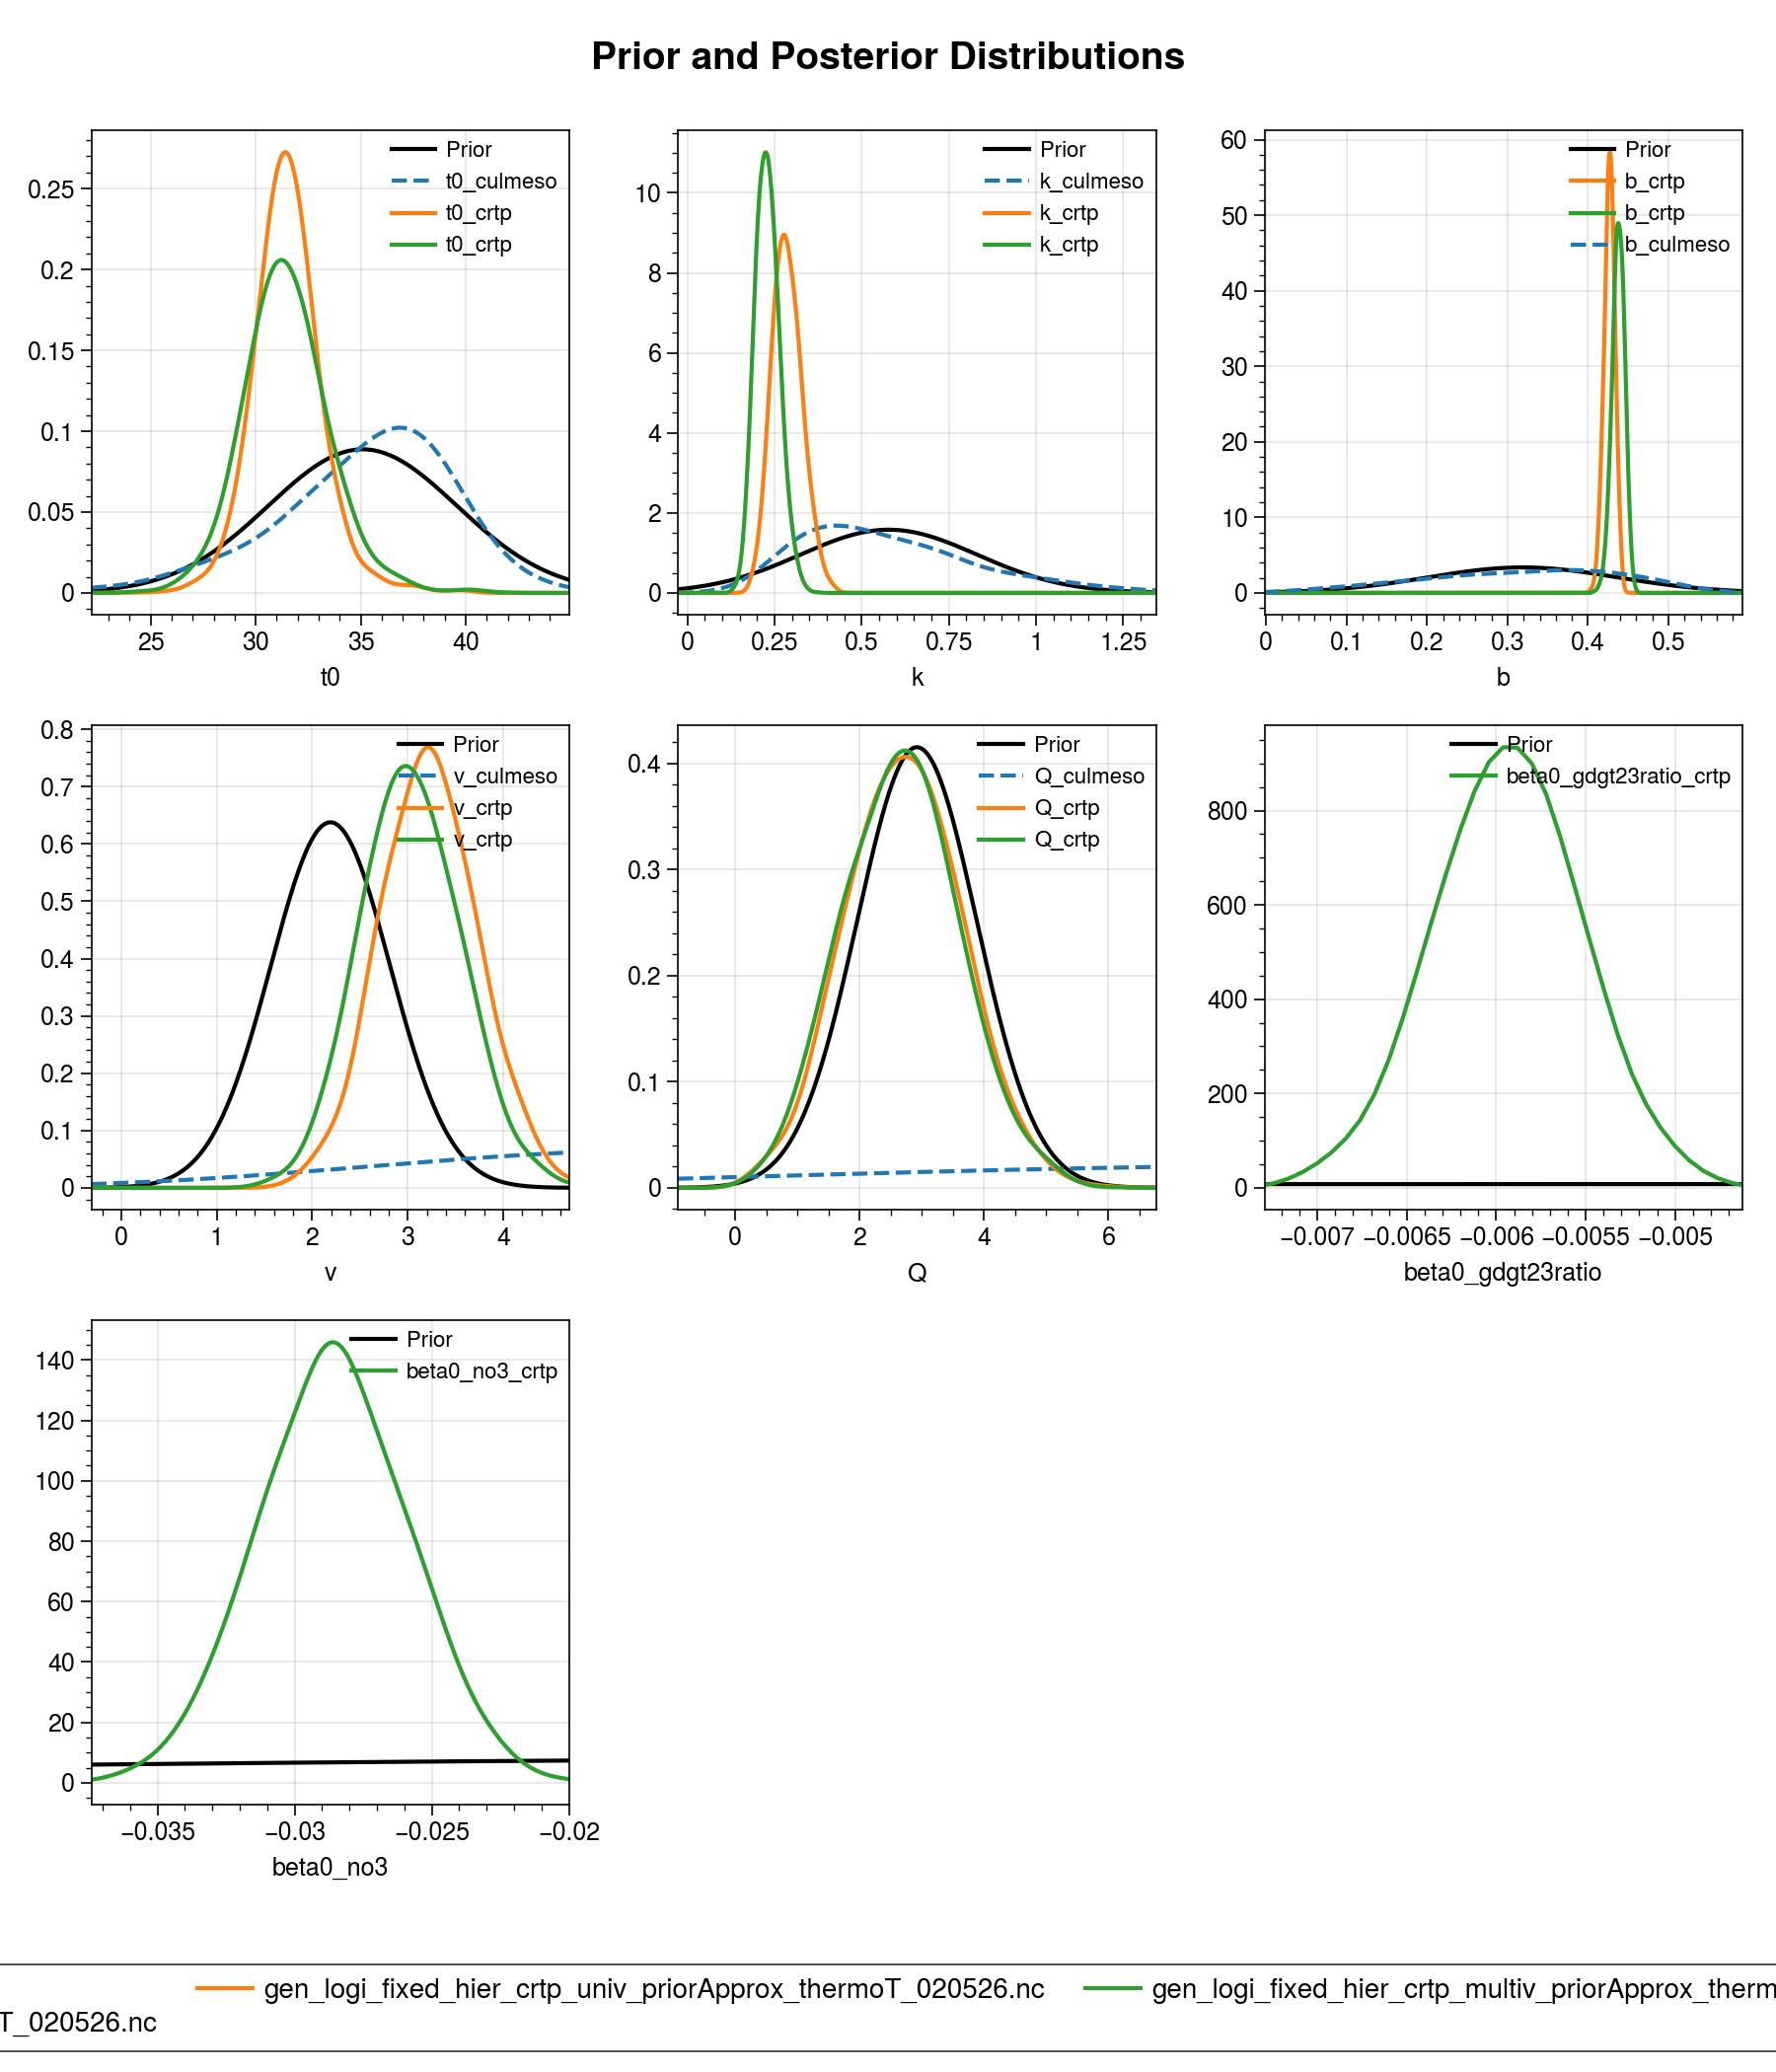

In [178]:
priors = gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[gen_logi_fixed_cul_meso_post_ds,
                        gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_post_ds,
                        gen_logi_fixed_hier_crtp_priorApprox_thermoT_multiv_g23r_no3_post_ds],
    zoomin_suffix="_crtp",
    use_linestyle_by_param=True,
    show_histogram=False
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'prior_distributions_multiv_thermoT.pdf'),dpi=300)

In [179]:
fpath = f'{local_github_path}/data/spreadsheets/published_data'
fname = 'TEXdatabase_v1.csv'

TT15_coretop_df = pd.read_csv(os.path.join(fpath, fname),skiprows=1)
TT15_coretop_df = TT15_coretop_df.dropna(subset=['tex86','WOA09_SST']).reset_index(drop=True)
TT15_coretop_df['binned_tex86'] = pd.cut(TT15_coretop_df['tex86'], bins=np.arange(0,1.05,0.05), right=False)
TT15_coretop_df

,core_name,core_type,sample_depth_start,sample_depth_end,longitude,latitude,depth,tex86,WOA09_SST,OISST_SST,WOA09_subT,fGDGT_0,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren',reference_name,reference_link,binned_tex86
0,GeoB7702-3,GC,5.0,6.0,34.073300,31.651700,562,0.662,22.0,22.5,18.4,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Castaneda et al. (2010) Paleoceanography,http://dx.doi.org/10.1029/2009PA001740,"[0.65, 0.7)"
1,KNR195-5-17 MC42,MC,0.0,1.0,-89.685500,-1.253000,615,0.563,23.1,23.8,17.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,"Chazen, C. (2011) PhD. Thesis, Brown University",https://repository.library.brown.edu/studio/it...,"[0.55, 0.6)"
2,KNR195-5-9 MC22,MC,0.0,1.0,-81.250000,-3.850300,689,0.567,22.2,22.3,16.3,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,"Chazen, C. (2011) PhD. Thesis, Brown University",https://repository.library.brown.edu/studio/it...,"[0.55, 0.6)"
3,KNR195-5-15 MC38,MC,0.0,1.0,-89.699300,-1.265700,597,0.567,23.1,23.8,17.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,"Chazen, C. (2011) PhD. Thesis, Brown University",https://repository.library.brown.edu/studio/it...,"[0.55, 0.6)"
4,KNR195-5-8 MC18,MC,0.0,1.0,-81.310000,-3.986700,1020,0.568,22.2,22.3,16.3,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,"Chazen, C. (2011) PhD. Thesis, Brown University",https://repository.library.brown.edu/studio/it...,"[0.55, 0.6)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,64PE301 P1500,MC,0.0,0.5,63.075000,22.078333,1495,0.730,26.6,26.7,23.4,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Lengger et al. (2014) Geochimica et Cosmochimi...,http://dx.doi.org/doi:10.1016/j.gca.2014.07.013,"[0.7, 0.75)"
1091,64PE301 P1800,MC,0.0,0.5,63.408333,22.308333,1786,0.730,26.6,26.8,23.4,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Lengger et al. (2014) Geochimica et Cosmochimi...,http://dx.doi.org/doi:10.1016/j.gca.2014.07.013,"[0.7, 0.75)"
1092,64PE301 P2000,MC,0.0,0.5,63.018611,22.144722,1970,0.720,26.6,26.7,23.4,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Lengger et al. (2014) Geochimica et Cosmochimi...,http://dx.doi.org/doi:10.1016/j.gca.2014.07.013,"[0.7, 0.75)"
1093,64PE301 P2500,MC,0.0,0.5,62.895000,22.104722,2470,0.720,26.6,26.7,23.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Lengger et al. (2014) Geochimica et Cosmochimi...,http://dx.doi.org/doi:10.1016/j.gca.2014.07.013,"[0.7, 0.75)"


In [180]:
methods = ['schouten02','kim2010_tex86H','OBrien17']
for method in methods:
    TT15_coretop_df[f'predSST_{method}'] = predictSSTfromTEX(
        input_tex=TT15_coretop_df['tex86'],
        method_name=method
    )
    
    TT15_coretop_df[f'Tres_{method}'] = TT15_coretop_df['WOA09_SST'] - TT15_coretop_df[f'predSST_{method}']
    
### predict T from TEX86 with BAYSPAR
TT15_coretop_df['predSST_bayspar_mean'] = np.nan
for i in tqdm(range(len(TT15_coretop_df))):
    try:
        TT15_coretop_df.loc[i,'predSST_bayspar_mean'] = bsr.predict_seatemp(TT15_coretop_df['tex86'].iloc[i].reshape(1),
                                                                             lon=TT15_coretop_df['longitude'].iloc[i].reshape(1),
                                                                             lat=TT15_coretop_df['latitude'].iloc[i].reshape(1),
                                                                             prior_std=6,temptype='sst').percentile(50)[0]
        
        TT15_coretop_df.loc[i,'Tres_bayspar'] = TT15_coretop_df['WOA09_SST'].iloc[i] - TT15_coretop_df.loc[i,'predSST_bayspar_mean']
    except:
        continue
    
    

  0%|          | 0/1095 [00:00<?, ?it/s]

100%|██████████| 1095/1095 [01:01<00:00, 17.81it/s]


In [181]:
methods = ['schouten02','kim2010_tex86H']
features = ['tex86','WOA09_SST']
temp_features = ['predSST_bayspar_mean'] + [f'predSST_{method}' for method in methods] 
predicted_SST_df = TT15_coretop_df[TT15_coretop_df['latitude']<70][features+temp_features].copy()
predicted_SST_df['t_est_range'] = predicted_SST_df[temp_features].max(axis=1) - predicted_SST_df[temp_features].min(axis=1)
predicted_SST_df = predicted_SST_df.sort_values(by='tex86').reset_index(drop=True)
predicted_SST_df['binned_tex86'] = pd.cut(predicted_SST_df['tex86'], bins=np.arange(-0.025,1.05,0.05), right=False)
predicted_SST_df

,tex86,WOA09_SST,predSST_bayspar_mean,predSST_schouten02,predSST_kim2010_tex86H,t_est_range,binned_tex86
0,0.204,0.2,-6.075561,-5.066693,-8.621297,3.554603,"[0.175, 0.225)"
1,0.268,-1.0,-2.733685,-0.800024,-0.515580,2.218105,"[0.225, 0.275)"
2,0.271,3.4,-1.895837,-0.600024,-0.184901,1.710936,"[0.225, 0.275)"
3,0.286,8.2,-0.989389,0.399976,1.415437,2.404826,"[0.275, 0.325)"
4,0.289,4.1,-0.844593,0.599976,1.725412,2.570006,"[0.275, 0.325)"
...,...,...,...,...,...,...,...
901,0.866,28.8,28.667821,39.066662,34.326224,10.398842,"[0.825, 0.875)"
902,0.866,28.6,28.705723,39.066662,34.326224,10.360939,"[0.825, 0.875)"
903,0.867,27.4,28.582405,39.133329,34.360506,10.550924,"[0.825, 0.875)"
904,0.876,28.0,29.058893,39.733329,34.667281,10.674437,"[0.875, 0.925)"


In [182]:
methods = ['schouten02','kim2010_tex86H','OBrien17']
binned_t_res_df = pd.pivot_table(data=TT15_coretop_df[TT15_coretop_df['latitude']<70],
               index='binned_tex86',
               values=[f'Tres_{method}' for method in methods]+['Tres_bayspar'],
               aggfunc=['min','mean','max']).reset_index()
binned_t_res_df.columns = ['_'.join(col).strip() for col in binned_t_res_df.columns.values]
binned_t_res_df

,binned_tex86_,min_Tres_OBrien17,min_Tres_bayspar,min_Tres_kim2010_tex86H,min_Tres_schouten02,mean_Tres_OBrien17,mean_Tres_bayspar,mean_Tres_kim2010_tex86H,mean_Tres_schouten02,max_Tres_OBrien17,max_Tres_bayspar,max_Tres_kim2010_tex86H,max_Tres_schouten02
0,"[0.2, 0.25)",-0.623494,6.275561,8.821297,5.266693,-0.623494,6.275561,8.821297,5.266693,-0.623494,6.275561,8.821297,5.266693
1,"[0.25, 0.3)",-6.611727,1.733685,-2.935909,-1.466643,-3.389374,4.388181,0.796644,1.846690,2.552979,9.189389,6.784563,7.800024
2,"[0.3, 0.35)",-11.035255,-2.805790,-8.958536,-6.266645,-6.505123,1.381718,-4.040421,-1.635352,2.035334,4.226984,4.334341,6.866689
3,"[0.35, 0.4)",-13.476430,-3.887456,-12.457271,-9.099980,-5.428660,0.454850,-4.011365,-0.887882,6.335335,8.208274,7.471181,10.766687
4,"[0.4, 0.45)",-15.829370,-6.948559,-15.308930,-11.766648,-3.856167,0.232087,-3.160835,0.324887,4.311806,7.391384,5.223515,8.633353
5,"[0.45, 0.5)",-16.217604,-6.715290,-15.889830,-12.366649,-2.430601,0.283920,-2.125785,1.358430,3.017690,4.701240,3.367364,6.900018
6,"[0.5, 0.55)",-11.799956,-6.542459,-11.572028,-8.333317,-1.819073,-0.196325,-1.569342,1.582262,6.452986,5.632652,6.677456,9.966683
7,"[0.55, 0.6)",-9.494071,-8.730187,-9.049679,-6.466652,-0.893576,0.040482,-0.384403,2.074400,4.476517,4.238651,4.984136,7.433347
8,"[0.6, 0.65)",-9.311716,-7.352941,-8.196259,-6.833321,-2.408906,-1.155857,-1.463983,0.188531,3.011812,3.078517,3.780995,5.733346
9,"[0.65, 0.7)",-12.017598,-10.098724,-10.261235,-9.899990,-2.504646,-0.672845,-0.856554,-0.326595,1.270637,2.070232,2.633349,3.600011


In [183]:
binned_tex_t_est_df = pd.pivot_table(predicted_SST_df,
                                     index='binned_tex86', values='t_est_range', aggfunc=['min','max','mean']).reset_index()
binned_tex_t_est_df.columns = binned_tex_t_est_df.columns.droplevel(0)
binned_tex_t_est_df.columns = ['binned_tex86','t_est_range_min','t_est_range_max','t_est_range_mean']
binned_tex_t_est_df['mid_tex_bin'] = [binned_tex_t_est_df['binned_tex86'][i].mid for i in range(len(binned_tex_t_est_df))]
binned_tex_t_est_df

,binned_tex86,t_est_range_min,t_est_range_max,t_est_range_mean,mid_tex_bin
0,"[0.175, 0.225)",3.554603,3.554603,3.554603,0.20
1,"[0.225, 0.275)",1.710936,2.218105,1.964521,0.25
2,"[0.275, 0.325)",2.032704,7.716972,4.481782,0.30
3,"[0.325, 0.375)",2.394651,10.475832,5.861697,0.35
4,"[0.375, 0.425)",3.130426,10.529609,4.797392,0.40
5,"[0.425, 0.475)",3.493853,10.828230,4.652738,0.45
6,"[0.475, 0.525)",3.145531,9.071457,3.660986,0.50
7,"[0.525, 0.575)",2.524457,6.879751,3.264320,0.55
8,"[0.575, 0.625)",1.770291,5.724591,2.852910,0.60
9,"[0.625, 0.675)",0.658736,5.415574,2.094518,0.65


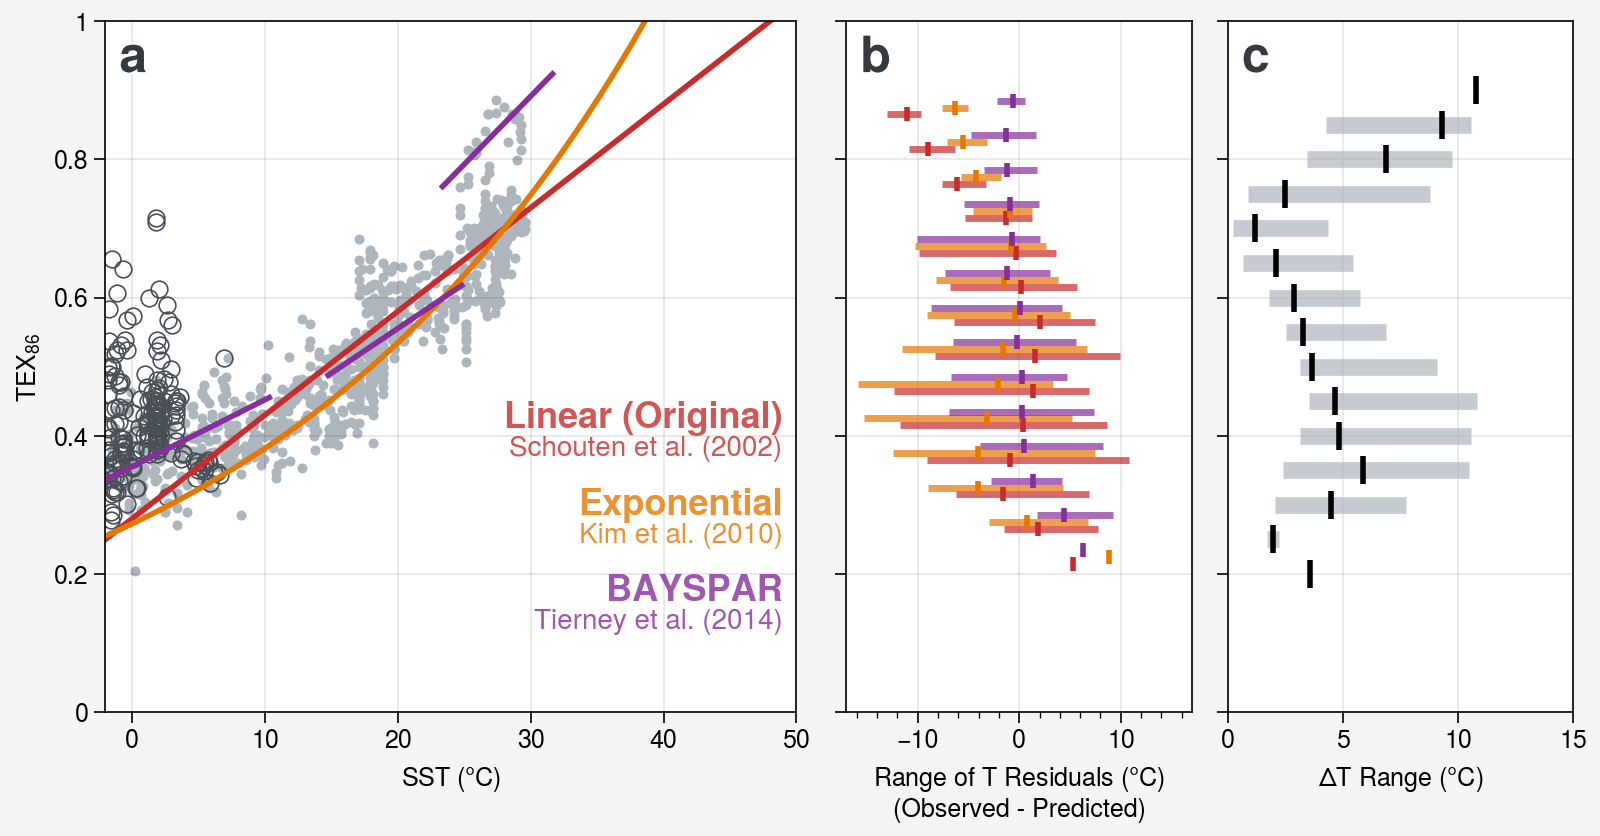

In [184]:
fig, axs = plot.subplots(width=8,ncols=3,wratios=[1,0.5,0.5],sharex=0)

ax = axs[0] 
# grouped = gridded_combined_df.groupby('datatype')
# for name, group in grouped:
#     if name!='coretop':
#         continue
#     else:
#         ax.scatter(group['SST'], group['TEX86'], 
#                 m=datatype_marker_dict.get(name,'o'), 
#                 mec='none' if name=='coretop' else 'black',
#                 label=name,
#                 color=datatype_color_dict.get(name,'gray5'),)

below70N_idx = TT15_coretop_df['latitude']<70
ax.scatter(TT15_coretop_df['WOA09_SST'][below70N_idx], TT15_coretop_df['tex86'][below70N_idx],
           m='.',
           c='gray5')
ax.scatter(TT15_coretop_df['WOA09_SST'][~below70N_idx], TT15_coretop_df['tex86'][~below70N_idx],
           m='o',mec='gray7',
           facecolor='none',
           label='>70°N')

ax.format(
    xlabel=r'SST ($\degree$C)',
    ylabel=r'TEX$_{86}$',
)

#### existing calibration models

temperature_range = np.linspace(-2, 50, 100)
methods = ['schouten02','kim2010_tex86H']
colors = ['red9','yellow9','lime9']
for i, method_name in enumerate(methods):
    predicted_tex = predictTEXfromSST(temperature_range,method_name=method_name)
    ax.plot(temperature_range, predicted_tex,
            c=colors[i],lw=2,
            ls='-',
            label=f'{method_name}',)
    
#### bayspar forward model

mid_redsea_lat = coretop_df[coretop_df['regionName']=='Red Sea']['match_lat_04deg'].median()
mid_redsea_lon = coretop_df[coretop_df['regionName']=='Red Sea']['match_lon_04deg'].median()
min_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].min()-2
max_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].max()+2

xx = np.linspace(min_redsea_sst, max_redsea_sst, 50)
pred_tex_redsea = bsr.predict_tex(
    xx,
    lat=mid_redsea_lat,
    lon=mid_redsea_lon,
    temptype='sst'
).percentile(50)

ax.plot([xx.min(),xx.max()], [pred_tex_redsea.min(),pred_tex_redsea.max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Red Sea',)


min_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].min()-2
max_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].max()+2
xx = np.linspace(min_mediterranean_sst, max_mediterranean_sst, 50)

mid_mediterranean_lat = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lat_04deg'].median()
mid_mediterranean_lon = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lon_04deg'].median()
pred_tex_mediterranean = bsr.predict_tex(
    xx,
    lat=mid_mediterranean_lat,
    lon=mid_mediterranean_lon,
    temptype='sst'
).percentile([10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_mediterranean[:,1].min(),pred_tex_mediterranean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Mediterranean Sea',)

# ax.fill_between([xx.min(),xx.max()], 
#                 [pred_tex_mediterranean[:,0].min(),pred_tex_mediterranean[:,0].max()],
#                 [pred_tex_mediterranean[:,2].min(),pred_tex_mediterranean[:,2].max()],
#                 color='grape9',alpha=0.2)

min_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].min()-2
max_southernocean_sst = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['SST'].max()+2
xx = np.linspace(min_southernocean_sst, max_southernocean_sst, 50)
mid_southernocean_lat = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lat_04deg'].median()
mid_southernocean_lon = coretop_df[coretop_df['regionName']=='Pacific-Southern Ocean']['match_lon_04deg'].median()
pred_tex_southernocean = bsr.predict_tex(
    xx,
    lat=mid_southernocean_lat,
    lon=mid_southernocean_lon,
    temptype='sst'
).percentile([10,50,90])

ax.plot([xx.min(),xx.max()], [pred_tex_southernocean[:,1].min(),pred_tex_southernocean[:,1].max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Southern Ocean',)

ax.format(
    ylim=(0,1),
    xlim=(-2,50),
    tickminor=False
)

method_list = ['schouten02','kim2010_tex86H']
annonation_dict = {
    "schouten02":{"text": "Linear (Original)","y_top": 0.45,"color": 'red9',
              "source":"Schouten et al. (2002)"},
    "kim2010_tex86H":{"text": "Exponential","y_top": 0.325,"color": 'yellow9',
                "source":"Kim et al. (2010)"},
    "BAYSPAR":{"text": "BAYSPAR","y_top": 0.2,"color": 'grape9',
                "source":"Tierney et al. (2014)"},
}
### Calibration models annotation
for i, method_name in enumerate(methods):
    if method_name in annonation_dict:
        text_str = annonation_dict[method_name]["text"]
        y_top = annonation_dict[method_name]["y_top"]
        color = annonation_dict[method_name]["color"]
        ax.text(0.98,y_top,
                text_str,
                transform=ax.transAxes,
                color=color,
                fontsize=13, fontweight='bold',
                ha='right',
                va='top',
                alpha=0.8
               )
        ax.text(0.98,y_top-0.05,
                annonation_dict[method_name]["source"],
                transform=ax.transAxes,
                color=color,
                fontsize=10,
                ha='right',
                va='top',
                alpha=0.8
               )
### annotation for BAYSPAR
text_str = annonation_dict["BAYSPAR"]["text"]
y_top = annonation_dict["BAYSPAR"]["y_top"]
color = annonation_dict["BAYSPAR"]["color"]
ax.text(0.98,y_top,
        text_str,
        transform=ax.transAxes,
        color=color,
        fontsize=13, fontweight='bold',
        ha='right',
        va='top',
        alpha=0.8
       )
ax.text(0.98,y_top-0.05,
        annonation_dict["BAYSPAR"]["source"],
        transform=ax.transAxes,
        color=color,
        fontsize=10,
        ha='right',
        va='top',
        alpha=0.8
       )
#### boxplot of T residuals
ax = axs[1]
method_list = ['schouten02','kim2010_tex86H','bayspar']
colors = ['red9','yellow9','grape9']
ypos_offset = [-0.01,0,0.01]
for i in range(len(binned_t_res_df)):
    ypos = binned_t_res_df['binned_tex86_'].iloc[i].mid
    for j, method_name in enumerate(method_list):
        res_min = binned_t_res_df[f'min_Tres_{method_name}'].iloc[i]
        res_max = binned_t_res_df[f'max_Tres_{method_name}'].iloc[i]
        res_mean = binned_t_res_df[f'mean_Tres_{method_name}'].iloc[i]
        ax.plot([res_min, res_max],
                [ypos+ypos_offset[j], ypos+ypos_offset[j]],
                c=colors[j], lw=2.5, solid_capstyle='butt', alpha=0.7)
        ax.plot(res_mean,
                ypos+ypos_offset[j],
                marker='|', c=colors[j], markersize=5,markeredgewidth=2,zorder=5)

ax.format(
    xlabel=r'Range of T Residuals ($\degree$C)'+'\n(Observed - Predicted)',
    xlim=(-17,17),
)

### boxplot of prediction ranges
ax = axs[2] 
for i in range(len(binned_tex_t_est_df)):
    ypos = binned_tex_t_est_df['mid_tex_bin'].iloc[i]
    ax.plot([binned_tex_t_est_df['t_est_range_min'].iloc[i], binned_tex_t_est_df['t_est_range_max'].iloc[i]],
            [ypos, ypos],
            c='gray5', lw=6, solid_capstyle='butt', alpha=0.7)
    ax.plot(binned_tex_t_est_df['t_est_range_mean'].iloc[i],
            ypos,
            marker='|', c='black', markersize=10,markeredgewidth=2)
    
ax.format(
    xlabel=r'$\Delta$T Range ($\degree$C)',
    ylabel=r'',
    xlim=(0,15),
    ylim=(0,1),
    tickminor=False
)
# h, l = ax.get_legend_handles_labels()
# ax.legend(h[5:], l[5:], loc='ul', ncols=1,frameon=False)
# ax.legend(h[:5], l[:5], loc='lr', ncols=1,frameon=False)




axs.format(abc=True,abcloc='ul',
            abcsize=18,
            abccolor='gray8')

fpath = f'{local_github_path}/figures/manuscript'
fig.savefig(os.path.join(fpath,'existing_calibrations_with_DeltaT_Tres_ranges.pdf'),dpi=300)

# Residuals plot

In [185]:
import numpy as np
from scipy.stats import gamma
import xarray as xr

def calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25):
    """
    Calculate gamma-weighted subsurface temperature (0-200m).
    
    Parameters:
    -----------
    T_da : xarray.DataArray
        Temperature data with depth dimension
    depth_dim : str
        Name of depth dimension (default: 'depth')
    alpha : float
        Gamma distribution shape parameter (default: 6.5)
    beta : float
        Gamma distribution scale parameter (default: 25 meters)
    
    Returns:
    --------
    subT : xarray.DataArray
        Gamma-weighted subsurface temperature
    """
    
    # Select top 200m
    T_200m = T_da.sel({depth_dim: slice(0, 200)})
    depths = T_200m[depth_dim].values
    
    # Calculate gamma weights
    # Gamma PDF: f(z; α, β) = (z^(α-1) * exp(-z/β)) / (β^α * Γ(α))
    weights = gamma.pdf(depths, a=alpha, scale=beta)
    
    # Normalize weights to sum to 1
    weights_norm = weights / np.sum(weights)
    
    # Create xarray DataArray for weights
    weights_da = xr.DataArray(
        weights_norm,
        coords={depth_dim: depths},
        dims=[depth_dim]
    )
    
    # Calculate weighted average
    subT = (T_200m * weights_da).sum(dim=depth_dim)
    
    return subT

# Usage example:
subT = calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25)

In [186]:
coretop_df['subT_gamma'] = [
    subT.sel(lon=coretop_df.loc[i,'match_lon_04deg'], lat=coretop_df.loc[i,'match_lat_04deg'], method='nearest').values
    for i in range(len(coretop_df))
]

In [187]:
pred_TEX_BAYSPAR_SST = np.full(len(coretop_df), np.nan)
for i, row in tqdm(coretop_df.iterrows()):
    sst = row['SST']
    if not np.isnan(sst):
        pred_TEX_BAYSPAR_SST[i] = bsr.predict_tex(
            np.atleast_1d(sst),
            lat=row['match_lat_04deg'],
            lon=row['match_lon_04deg'],
            temptype='sst'
        ).percentile(50)[0]
        
pred_TEX_BAYSPAR_SST
        

0it [00:00, ?it/s]

1350it [00:43, 31.37it/s]


array([0.37107616, 0.37080962, 0.37188312, ..., 0.28575986, 0.26316666,
       0.27671345])

In [188]:
pred_TEX_BAYSPAR_subT = np.full(len(coretop_df), np.nan)
for i, row in tqdm(coretop_df.iterrows()):
    sst = row['subT_gamma']
    if not np.isnan(sst):
        pred_TEX_BAYSPAR_subT[i] = bsr.predict_tex(
            np.atleast_1d(sst),
            lat=row['match_lat_04deg'],
            lon=row['match_lon_04deg'],
            temptype='subt'
        ).percentile(50)[0]
        
pred_TEX_BAYSPAR_subT
        

0it [00:00, ?it/s]

1350it [00:42, 31.47it/s]


array([0.35806873, 0.35717545, 0.35949805, ..., 0.34670814, 0.35676215,
       0.35648666])

In [200]:
generalized_logistic_model_fixed_upper

<function __main__.generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q)>

In [ ]:
theta_T_global = {
    'x0': 27.831,
    'b': 0.432,
    'k': 0.152,
    'v': 1.475,
    'Q': 1.874,
    'betaG23', 0.015,
}
XX = np.linspace(-2,50,200)
predRI_thermoT_Tonly_frequentist = generalized_logistic_model_fixed_upper(
    coretop_df['t_sf2tc_avg'],
    x0=theta_T_global['x0'],
    b=theta_T_global['b'],
    k=theta_T_global['k'],
    v=theta_T_global['v'],
    Q=theta_T_global['Q']
)
RIres_thermoT_Tonly_frequentist = coretop_df['scaledRI'] - predRI_thermoT_Tonly_frequentist

predRI_thermoT_T_g23r_frequentist = generalized_logistic_model_fixed_upper(


In [199]:
predRI_thermoT_Tonly = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_020526"),
    x_vals = coretop_df['t_sf2tc_avg'])['p50']

RIres_thermoT_Tonly = coretop_df['scaledRI'] - predRI_thermoT_Tonly

predRI_thermoT_T_g23r = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.77_020526"),
    x_vals = coretop_df['t_sf2tc_avg'],
    gdgt23ratio = coretop_df['gdgt23ratio'],
)['p50']
RIres_thermoT_T_g23r = coretop_df['scaledRI'] - predRI_thermoT_T_g23r

predRI_thermoT_T_g23r_no3 = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.77_020526"),
    x_vals = coretop_df['t_sf2tc_avg'],
    gdgt23ratio = coretop_df['gdgt23ratio'],
    no3 = coretop_df['no3_sf2tc_avg'],
    no3_cutoff=1.77)['p50']
RIres_thermoT_T_g23r_no3 = coretop_df['scaledRI'] - predRI_thermoT_T_g23r_no3

In [190]:
predRI_SST_Tonly = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_SST_020526"),
    x_vals = coretop_df['SST'])['p50']

RIres_SST_Tonly = coretop_df['scaledRI'] - predRI_SST_Tonly

predRI_SST_T_g23r = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.77_020526"),
    x_vals = coretop_df['SST'],
    gdgt23ratio = coretop_df['gdgt23ratio'],
)['p50']
RIres_SST_T_g23r = coretop_df['scaledRI'] - predRI_SST_T_g23r

predRI_SST_T_g23r_no3 = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.77_020526"),
    x_vals = coretop_df['SST'],
    gdgt23ratio = coretop_df['gdgt23ratio'],
    no3 = coretop_df['no3_sf2tc_avg'],
    no3_cutoff=1.77)['p50']
RIres_SST_T_g23r_no3 = coretop_df['scaledRI'] - predRI_SST_T_g23r_no3

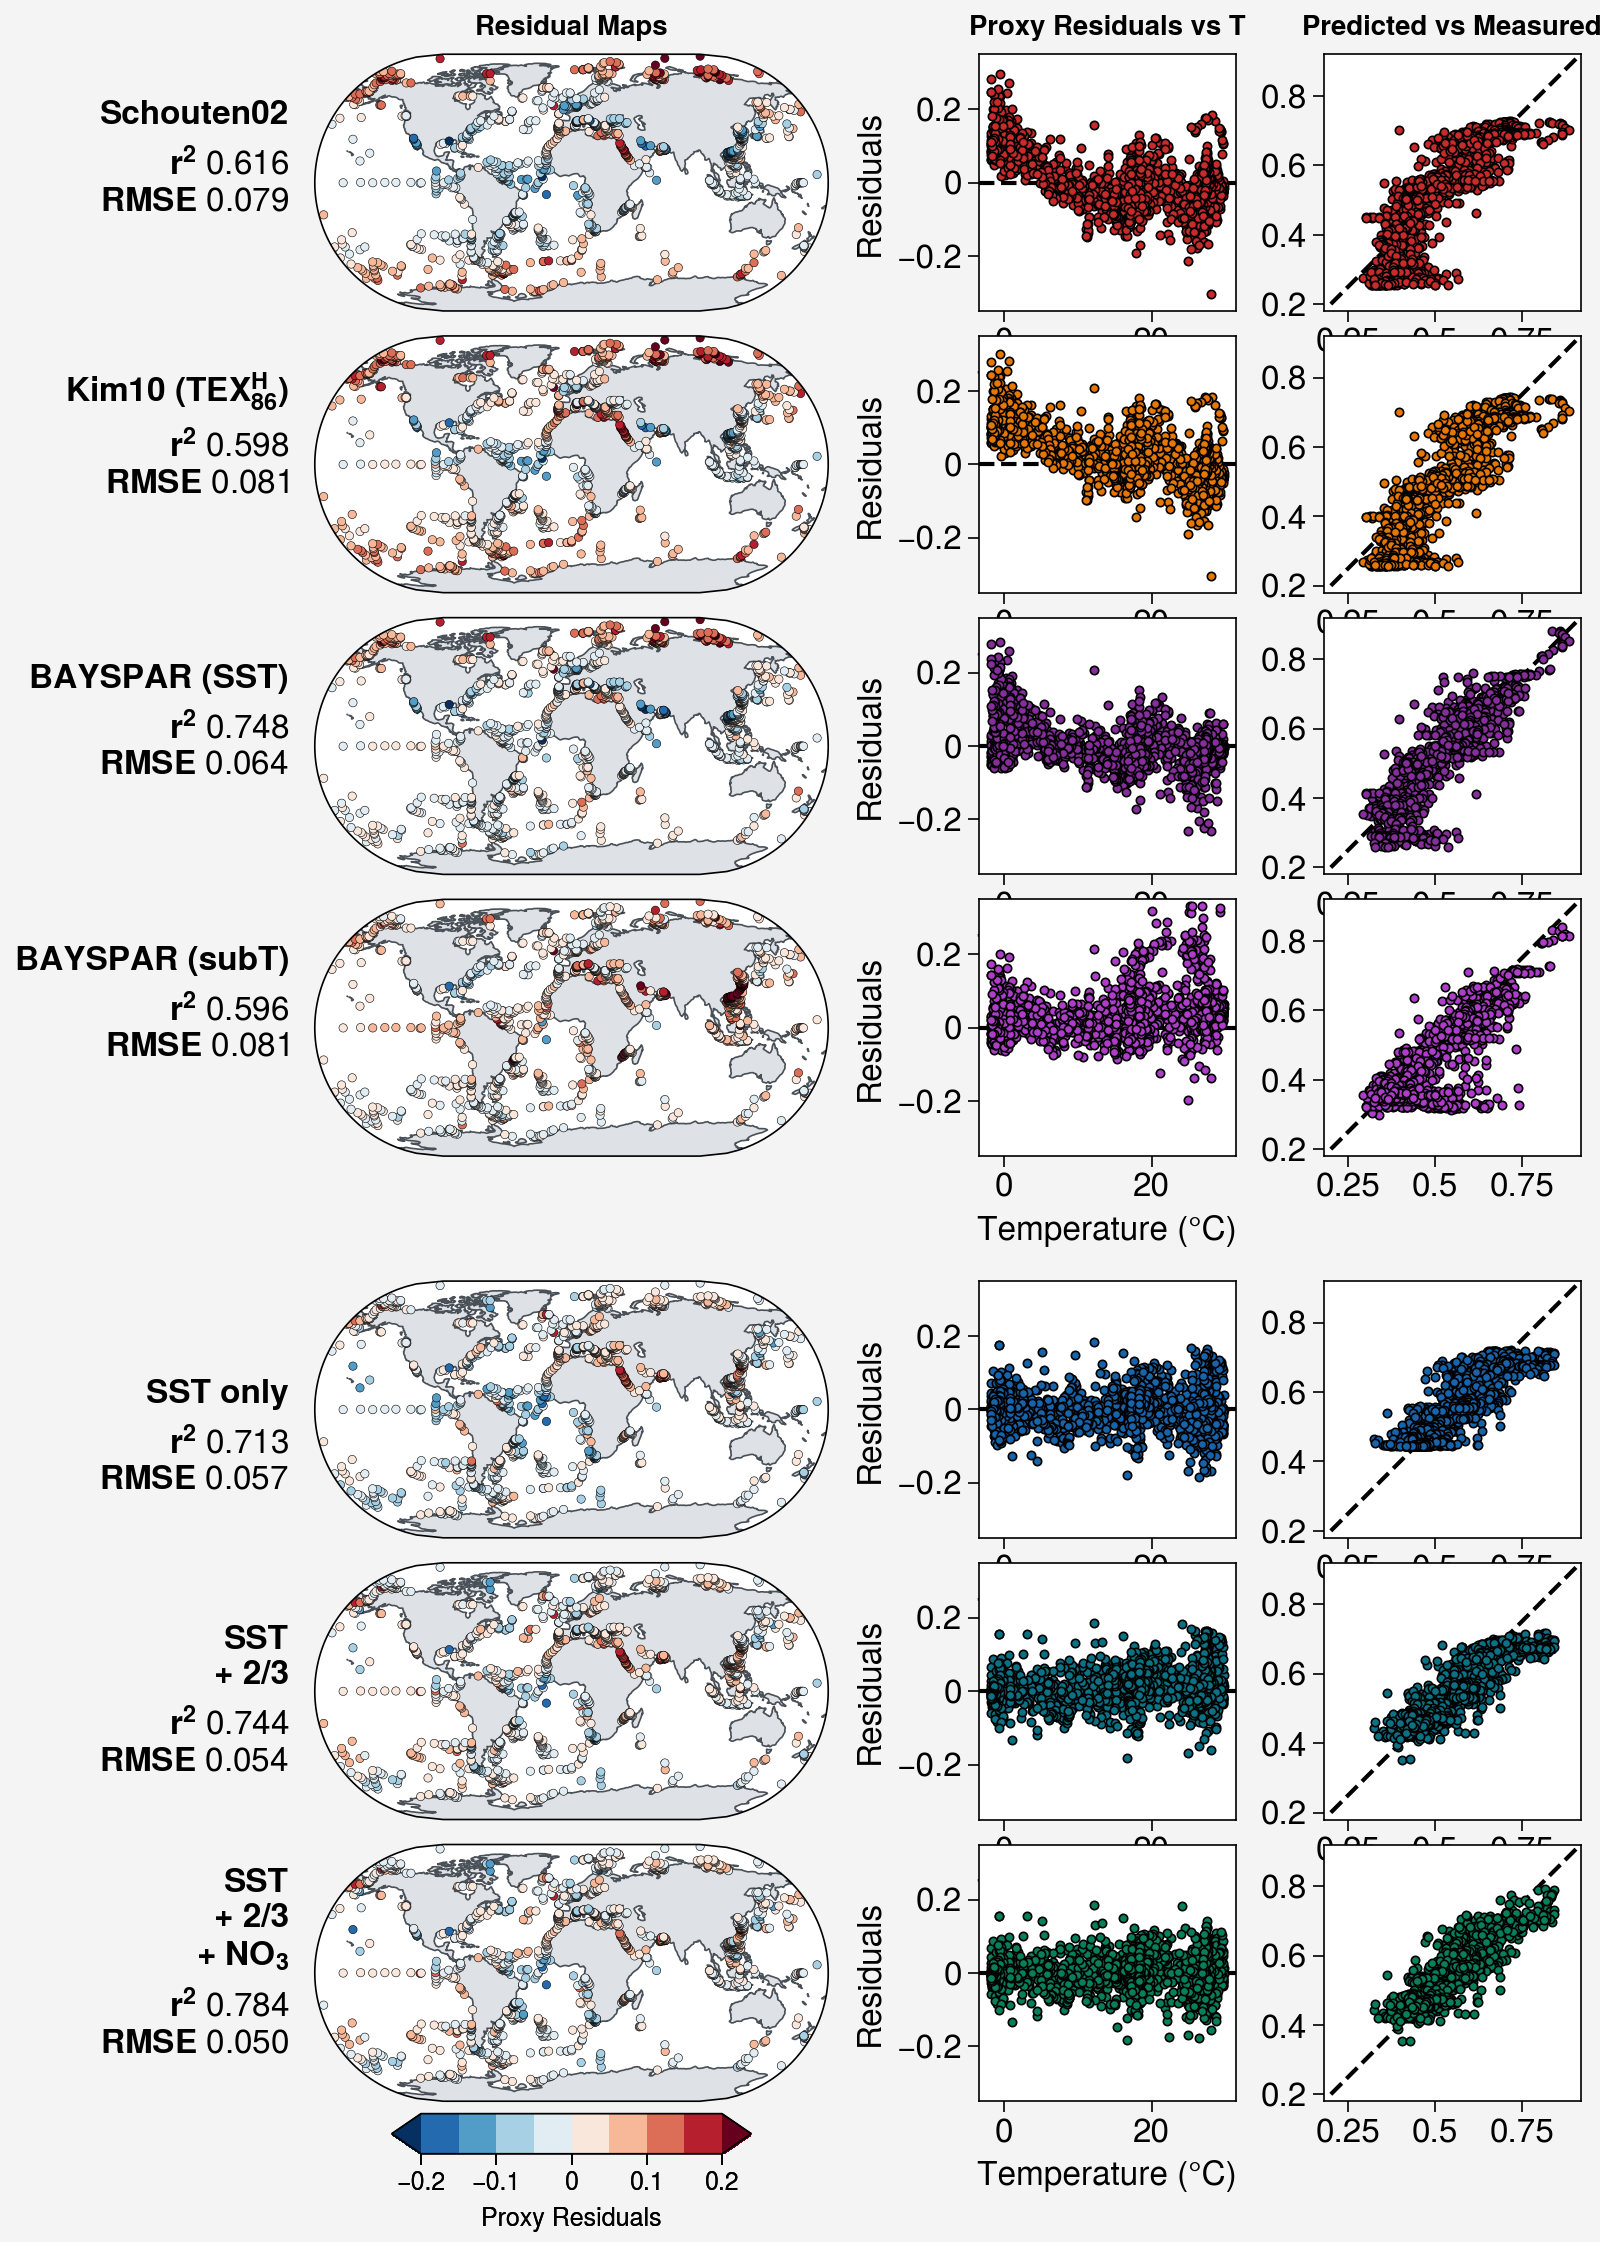

In [191]:
import numpy as np
from sklearn.metrics import r2_score

# Calculate predictions and residuals upfront
pred_TEX_schouten02 = predictTEXfromSST(coretop_df['SST'], method_name='schouten02')
pred_TEX_kim2010 = predictTEXfromSST(coretop_df['SST'], method_name='kim2010_tex86H')

TEX_residuals_schouten02 = coretop_df['TEX86'] - pred_TEX_schouten02
TEX_residuals_kim2010 = coretop_df['TEX86'] - pred_TEX_kim2010
TEX_residuals_BAYSPAR_SST = coretop_df['TEX86'] - pred_TEX_BAYSPAR_SST
TEX_residuals_BAYSPAR_subT = coretop_df['TEX86'] - pred_TEX_BAYSPAR_subT


# Data for each row: (measured, predicted, residuals, color)
row_data = [
    (coretop_df['TEX86'], pred_TEX_schouten02, TEX_residuals_schouten02, 'red9'),
    (coretop_df['TEX86'], pred_TEX_kim2010, TEX_residuals_kim2010, 'yellow9'),
    (coretop_df['TEX86'], pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, 'grape9'),
    (coretop_df['TEX86'], pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, 'grape7'),
    (coretop_df['scaledRI'], predRI_SST_Tonly, RIres_SST_Tonly, 'blue9'),
    (coretop_df['scaledRI'], predRI_SST_T_g23r, RIres_SST_T_g23r, 'cyan9'),
    (coretop_df['scaledRI'], predRI_SST_T_g23r_no3, RIres_SST_T_g23r_no3, 'teal9'),
]

row_method_labels = [
    'Schouten02',
    r'Kim10 (TEX$_{86}^H$)',
    'BAYSPAR (SST)',
    'BAYSPAR (subT)',
    'SST only',
    'SST\n+ 2/3',
    'SST\n+ 2/3\n+ NO$_{3}$',
]

# Calculate metrics for all rows
metrics = []
for measured, predicted, residuals, _ in row_data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    metrics.append((r2, rmse))

# Create figure
fig, axs = plot.subplots(
    proj={1:'eck3', 4:'eck3', 7:'eck3', 10:'eck3', 13:'eck3', 16:'eck3', 19:'eck3'},
    width=8, ncols=3, nrows=7, share=0, wratios=[2, 1, 1],
    hspace=[1,1,1,5,1,1]
    
)

axs.format(
    land=True, landzorder=0, landcolor='gray3',
    coast=True, coastzorder=1, coastcolor='gray7',
    lonlines=30, latlines=30, fontsize=12,
)

# Plot all rows
for i, ((measured, predicted, residuals, color), (r2, rmse), method_label) in enumerate(zip(row_data, metrics, row_method_labels)):
    
    # Column 0: Map of residuals
    ax = axs[i, 0]
    sc = ax.scatter(
        coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'],
        c=residuals, cmap='RdBu_r', levels=np.arange(-0.2, 0.21, 0.05),
        extend='both', m='.', zorder=2,mec='k',mew=0.2
    )
    
    # Add method label as text
    text = method_label
    ypos = 0.7 if i<4 else 0.5
    ax.text(-0.05, ypos, text, transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='right', va='bottom')
    
    # Add text on left
    text = f'$\\mathbf{{r^2}}$ {r2:.3f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
    ypos = 0.5 if i<4 else 0.3
    ax.text(
        -0.05, ypos, text, transform=ax.transAxes,
        fontsize=12, ha='right', va='center',
    )
    
    # Column 1: Residuals vs Temperature
    ax = axs[i, 1]
    ax.scatter(coretop_df['SST'], residuals, m='.', c=color, mec='k', zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    
    # Column 2: Predicted vs Measured
    ax = axs[i, 2]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)

# Format columns
axs[-1, 0].colorbar(sc, loc='b', label='Proxy Residuals', extend='both', shrink=0.7)
axs[:, 0].format(yticklabels=[])
axs[:, 1].format(xlabel='Temperature (°C)', ylabel='Residuals', ylim=(-0.35, 0.35), tickminor=False)
axs[:, 2].format(xlim=(0.18, 0.92), ylim=(0.18, 0.92), tickminor=False, xlabel='', ylabel='')
axs.format(
    collabels=['Residual Maps', 'Proxy Residuals vs T', 'Predicted vs Measured'],
    grid=False,
    
)

# Optional: save figure
# fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
# fig.savefig(os.path.join(fpath, 'scaledRI_residuals_maps_and_scatterplots.png'), dpi=300)

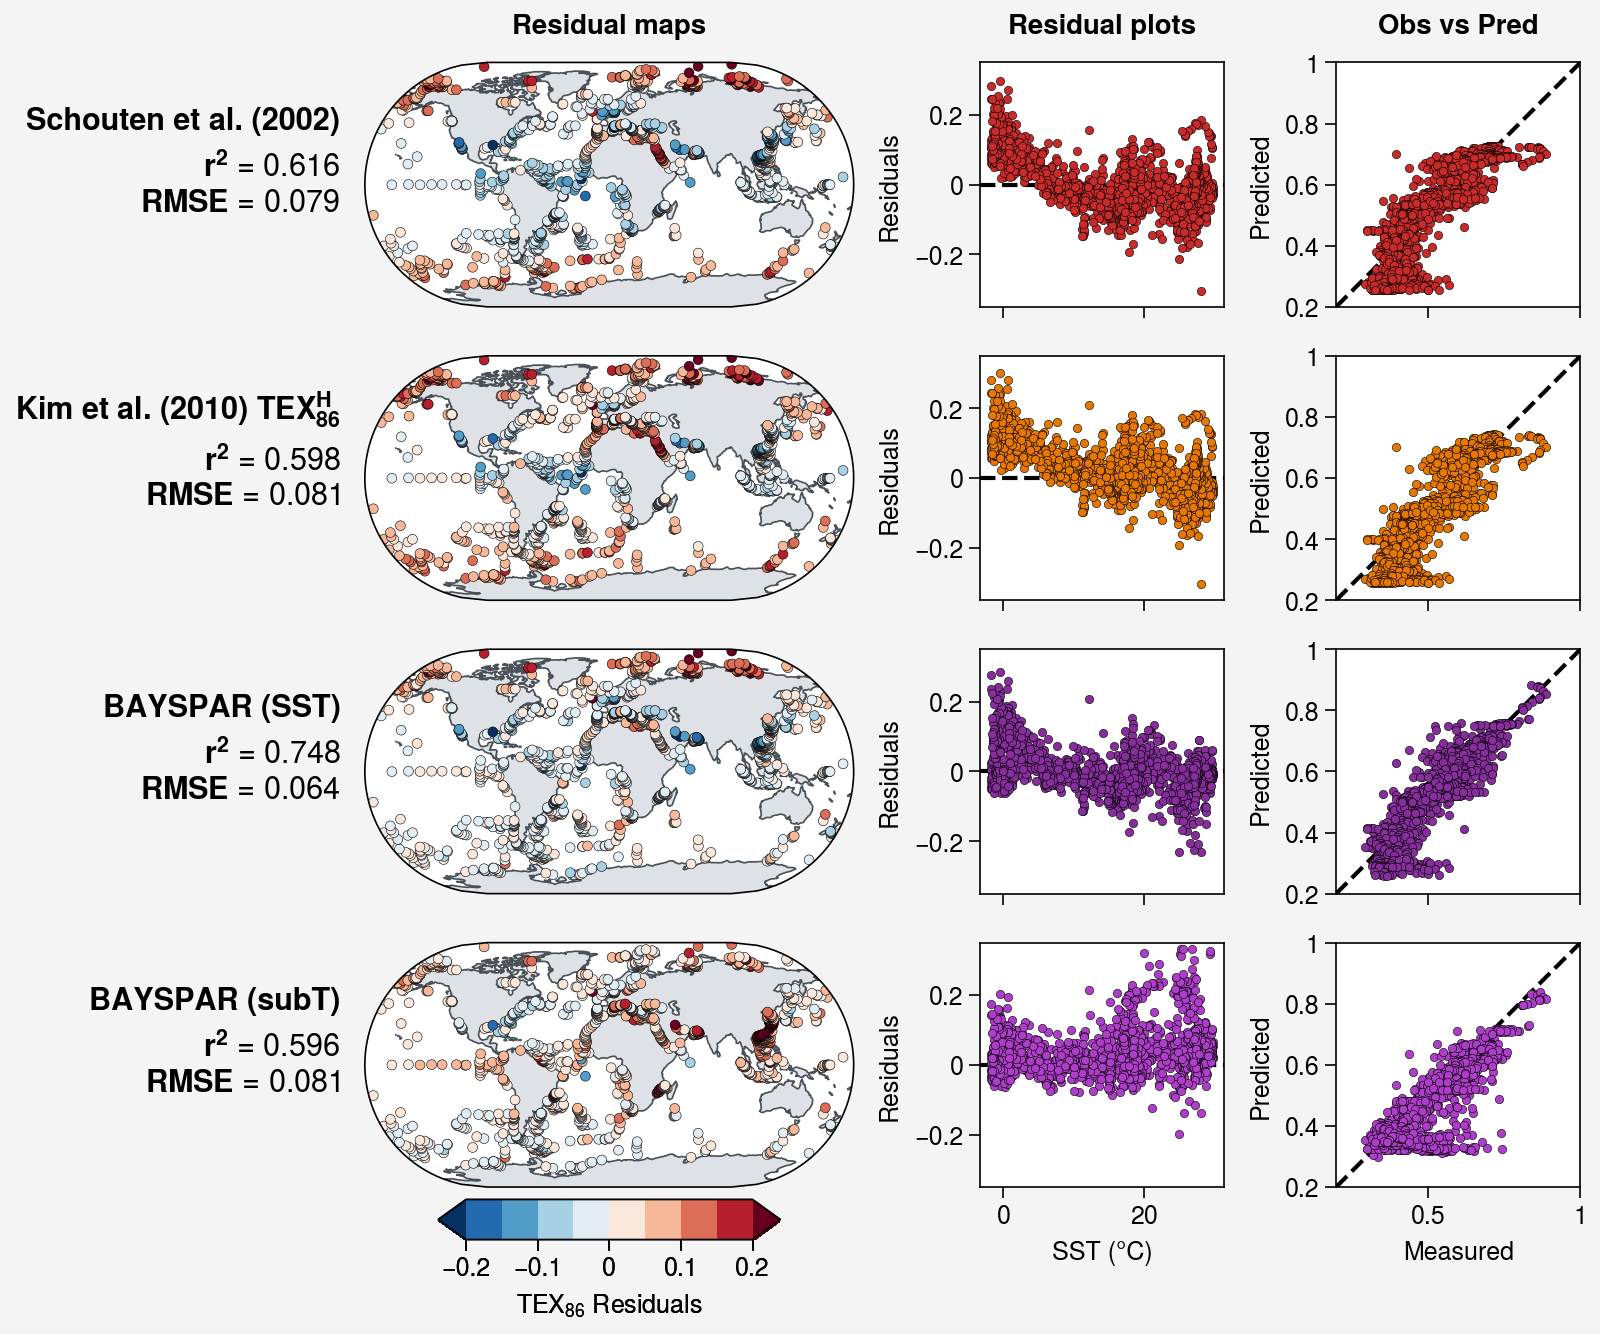

In [192]:
# ============================================================================
# FIGURE 1: TEX86 (Previous Work)
# ============================================================================

# Calculate TEX86 predictions and residuals
pred_TEX_schouten02 = predictTEXfromSST(coretop_df['SST'], method_name='schouten02')
pred_TEX_kim2010 = predictTEXfromSST(coretop_df['SST'], method_name='kim2010_tex86H')

TEX_residuals_schouten02 = coretop_df['TEX86'] - pred_TEX_schouten02
TEX_residuals_kim2010 = coretop_df['TEX86'] - pred_TEX_kim2010
TEX_residuals_BAYSPAR_SST = coretop_df['TEX86'] - pred_TEX_BAYSPAR_SST
TEX_residuals_BAYSPAR_subT = coretop_df['TEX86'] - pred_TEX_BAYSPAR_subT

# TEX86 data: (measured, predicted, residuals, color, method_label)
tex_data = [
    (coretop_df['TEX86'], pred_TEX_schouten02, TEX_residuals_schouten02, 'red9', 'Schouten et al. (2002)'),
    (coretop_df['TEX86'], pred_TEX_kim2010, TEX_residuals_kim2010, 'yellow9', r'Kim et al. (2010) TEX$_{86}^H$'),
    (coretop_df['TEX86'], pred_TEX_BAYSPAR_SST, TEX_residuals_BAYSPAR_SST, 'grape9', 'BAYSPAR (SST)'),
    (coretop_df['TEX86'], pred_TEX_BAYSPAR_subT, TEX_residuals_BAYSPAR_subT, 'grape7', 'BAYSPAR (subT)'),
]

# Calculate metrics
tex_metrics = []
for measured, predicted, residuals, _, _ in tex_data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    tex_metrics.append((r2, rmse))

# Create TEX86 figure
fig_tex, axs_tex = plot.subplots(
    proj={1:'eck3', 4:'eck3', 7:'eck3', 10:'eck3'},
    width=8, ncols=3, nrows=4, share=0, wratios=[2, 1, 1],
)

axs_tex.format(
    collabels=['Residual maps', 'Residual plots', 'Obs vs Pred'],
)

# Plot TEX86 rows
for i, ((measured, predicted, residuals, color, method_label), (r2, rmse)) in enumerate(zip(tex_data, tex_metrics)):
    
    # Column 0: Map of residuals
    ax = axs_tex[i, 0]
    ax.format(
    land=True, landzorder=0, landcolor='gray3',
    coast=True, coastzorder=1, coastcolor='gray7',
    lonlines=30, latlines=30,)
    sc = ax.scatter(
        coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'],
        c=residuals, cmap='RdBu_r', levels=np.arange(-0.2, 0.21, 0.05),
        extend='both', m='.', s=50, zorder=2, mec='k', mew=0.2
    )
    
    # Add method label
    ax.text(-0.05, 0.70, method_label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='right', va='bottom')
    
    # Add metrics
    text = f'$\\mathbf{{r^2}}$ = {r2:.3f}\n$\\mathbf{{RMSE}}$ = {rmse:.3f}'
    ax.text(-0.05, 0.50, text, transform=ax.transAxes,
            fontsize=11, ha='right', va='center')
    
    # Column 1: Residuals vs Temperature
    ax = axs_tex[i, 1]
    ax.scatter(coretop_df['SST'], residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    
    # Column 2: Predicted vs Measured
    ax = axs_tex[i, 2]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)

# Format TEX86 figure
axs_tex[-1, 0].colorbar(sc, loc='b', label=r'TEX$_{86}$ Residuals', extend='both', shrink=0.7)
axs_tex[:, 0].format(yticklabels=[])
axs_tex[:, 1].format(xlabel='SST (°C)', ylabel='Residuals', ylim=(-0.35, 0.35), tickminor=False)
axs_tex[:, 2].format(xlim=(0.2,1), ylim=(0.2,1), tickminor=False, 
                     xlabel='Measured', ylabel='Predicted')

axs_tex[:-1, :].format(xlabel='',xticklabels=[])
axs_tex.format(
    grid=False
)
fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fig_tex.savefig(os.path.join(fpath,'supp_fig_TEX86_calibrations_residuals_maps_and_scatterplots.pdf'), dpi=300)

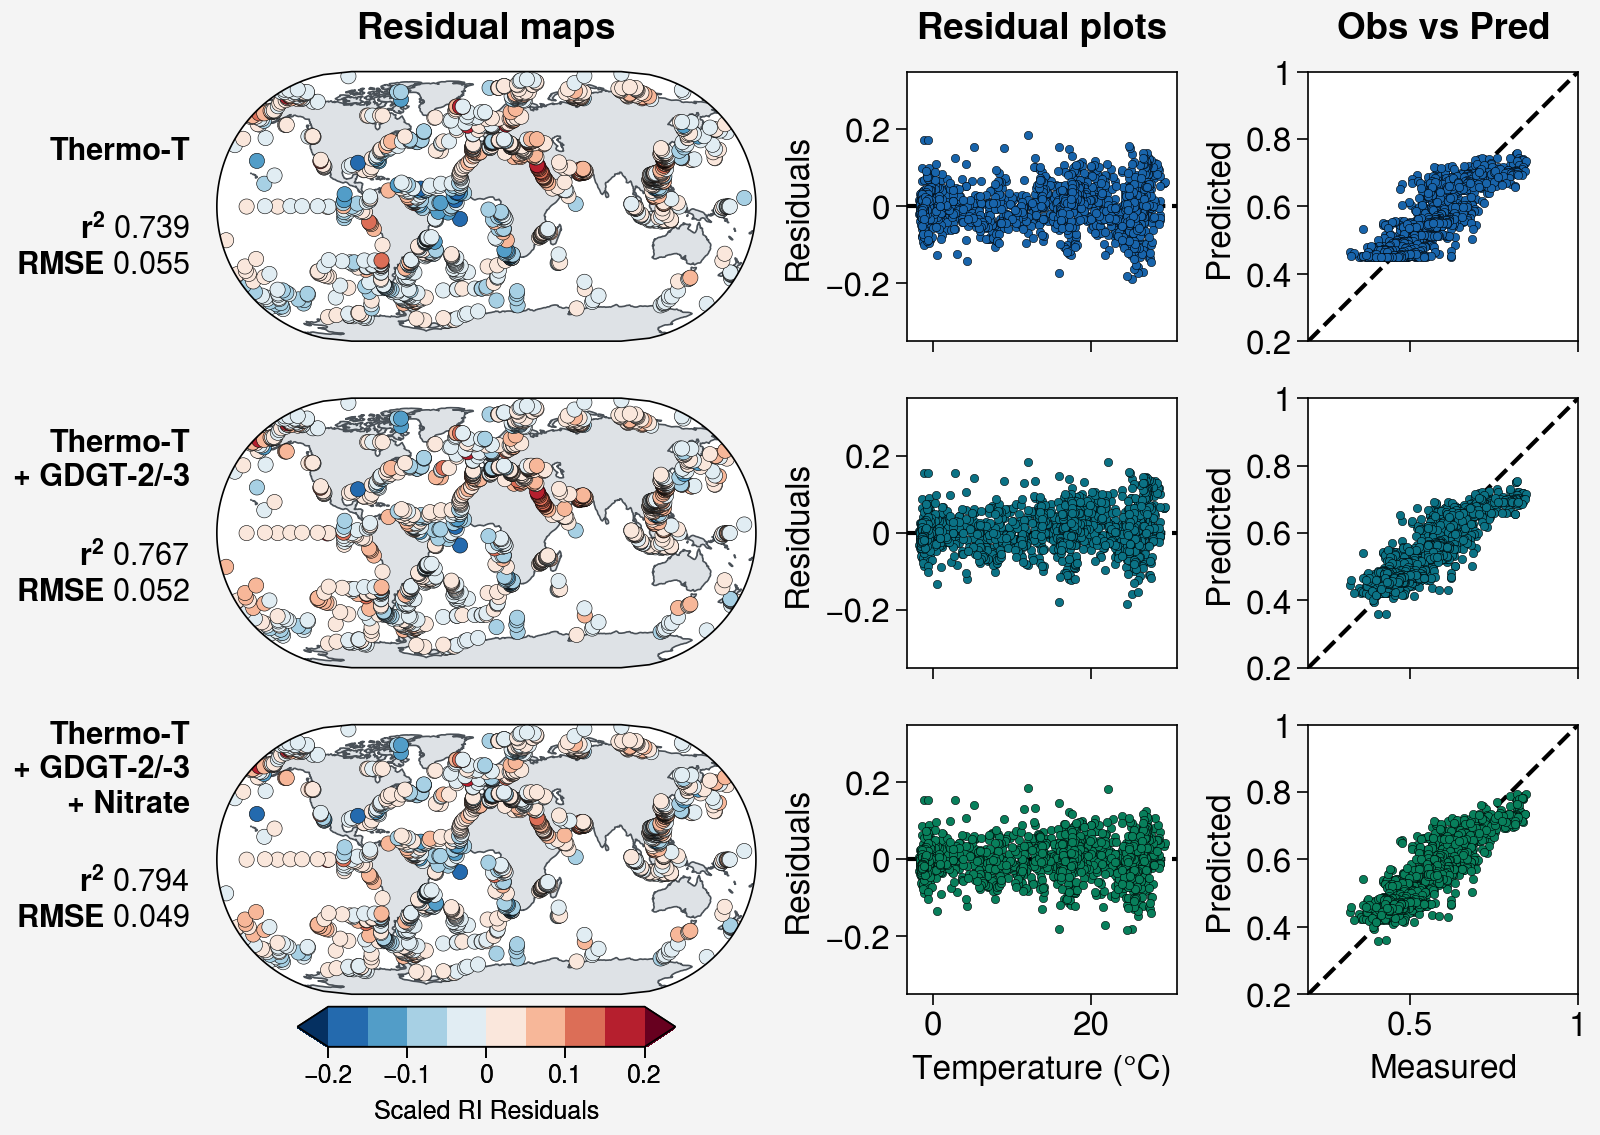

In [193]:
# TEXAS data: Thermo-T cases first, then SST cases
# (measured, predicted, residuals, color, method_label, temperature_field)
texas_data = [
    # Thermo-T cases
    (coretop_df['scaledRI'], predRI_thermoT_Tonly, RIres_thermoT_Tonly, 'blue9', 
     'Thermo-T', coretop_df['t_sf2tc_avg']),
    (coretop_df['scaledRI'], predRI_thermoT_T_g23r, RIres_thermoT_T_g23r, 'cyan9', 
     'Thermo-T\n+ GDGT-2/-3', coretop_df['t_sf2tc_avg']),
    (coretop_df['scaledRI'], predRI_thermoT_T_g23r_no3, RIres_thermoT_T_g23r_no3, 'teal9', 
     f'Thermo-T\n+ GDGT-2/-3\n+ Nitrate', coretop_df['t_sf2tc_avg']),
]

# Calculate metrics
texas_metrics = []
for measured, predicted, residuals, _, _, _ in texas_data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    texas_metrics.append((r2, rmse))

# Create TEXAS figure with extra space between Thermo-T and SST
fig_texas, axs_texas = plot.subplots(
    proj={1:'eck3', 4:'eck3', 7:'eck3',},
    width=8, ncols=3, nrows=3, share=0, wratios=[2, 1, 1],
)

axs_texas.format(
    land=True, landzorder=0, landcolor='gray3',
    coast=True, coastzorder=1, coastcolor='gray7',
    lonlines=30, latlines=30, fontsize=12,
    collabels=['Residual maps', 'Residual plots', 'Obs vs Pred'],
)

# Plot TEXAS rows
for i, ((measured, predicted, residuals, color, method_label, temp_field), (r2, rmse)) in enumerate(zip(texas_data, texas_metrics)):
    
    # Column 0: Map of residuals
    ax = axs_texas[i, 0]
    sc = ax.scatter(
        coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'],
        c=residuals, cmap='RdBu_r', levels=np.arange(-0.2, 0.21, 0.05),
        extend='both', m='o', s=30, zorder=2, mec='k', mew=0.2
    )
    
    # Add method label
    ax.text(-0.05, 0.65, method_label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='right', va='bottom')
    
    # Add metrics
    text = f'$\\mathbf{{r^2}}$ {r2:.3f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
    ax.text(-0.05, 0.35, text, transform=ax.transAxes,
            fontsize=11, ha='right', va='center')
    
    # Column 1: Residuals vs Temperature
    ax = axs_texas[i, 1]
    ax.scatter(temp_field, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    
    # Column 2: Predicted vs Measured
    ax = axs_texas[i, 2]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)

# Format TEXAS figure
axs_texas[-1, 0].colorbar(sc, loc='b', label='Scaled RI Residuals', extend='both', shrink=0.7)
axs_texas[:, 0].format(yticklabels=[])
axs_texas[:, 1].format(xlabel='Temperature (°C)', ylabel='Residuals',
                       ylim=(-0.35, 0.35), 
                       tickminor=False)
axs_texas[:, 2].format(xlim=(0.2,1), ylim=(0.2,1), tickminor=False, 
                       xlabel='Measured', ylabel='Predicted')

axs_texas[:-1, :].format(xlabel='',xticklabels=[])
axs_texas.format(
    grid=False
)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig10_TEXAS_thermoT_calibrations_residuals_maps_and_scatterplots.pdf'
fig_texas.savefig(os.path.join(fpath,fname), dpi=300)

In [194]:
predRI_thermoT_Tonly_withMultiv = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.77_020526"),
    x_vals = coretop_df['t_sf2tc_avg'])['p50']

RIres_thermoT_Tonly_withMultiv = coretop_df['scaledRI'] - predRI_thermoT_Tonly_withMultiv

In [195]:
coretop_df['diffRI_TG23NO3_minus_thermoT'] = predRI_thermoT_T_g23r_no3 - predRI_thermoT_Tonly_withMultiv
coretop_df['diffRI_TG23_minus_thermoT'] = predRI_thermoT_T_g23r - predRI_thermoT_Tonly_withMultiv

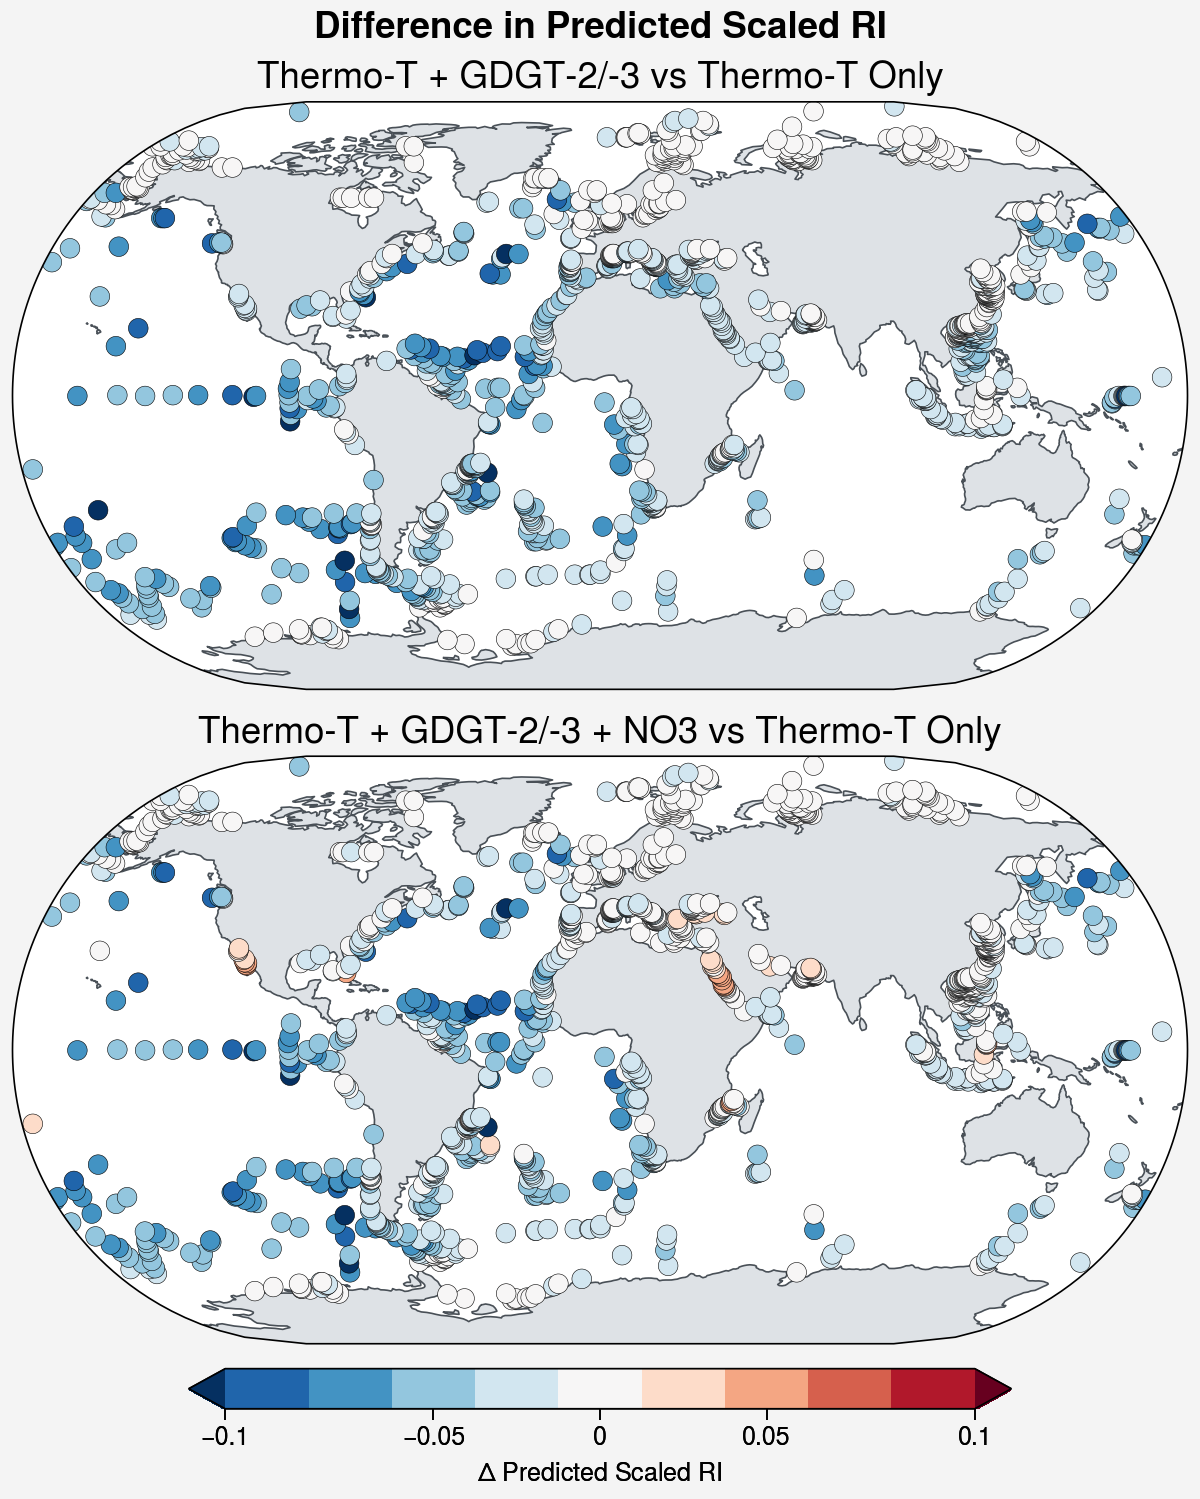

In [196]:
import numpy as np
# Assuming 'plot' is proplot or similar

# 1. Define Levels (White Zone logic)
# Skips 0.0 exactly, creates a bin [-0.01, 0.01] that maps to white
levels = np.array([-0.1, -0.08, -0.06, -0.04, -0.02, 0.02, 0.04, 0.06, 0.08, 0.1])

fig, axs = plot.subplots(width=6, nrows=2, proj='eck3')
plot_lat = coretop_df['match_lat_04deg']
plot_lon = coretop_df['match_lon_04deg']

# Plot 1: GDGT Effect
ax = axs[0]
ax.format(title='Thermo-T + GDGT-2/-3 vs Thermo-T Only')
sc = ax.scatter(plot_lon, plot_lat, c=coretop_df['diffRI_TG23_minus_thermoT'],
                cmap='RdBu_r', 
                levels=levels, 
                extend='both', 
                m='o', s=50, zorder=2, mec='k', mew=0.2)

# Plot 2: GDGT + Nitrate Effect
ax = axs[1]
ax.format(title='Thermo-T + GDGT-2/-3 + NO3 vs Thermo-T Only')
sc = ax.scatter(plot_lon, plot_lat, c=coretop_df['diffRI_TG23NO3_minus_thermoT'],
                cmap='RdBu_r', 
                levels=levels, 
                extend='both', 
                m='o', s=50, zorder=2, mec='k', mew=0.2)

# --- UPDATED COLORBAR SECTION ---
# Using fig.colorbar creates a shared bar for the whole figure
# 'ticks' forces a label at 0 (and other key intervals)
fig.colorbar(sc, loc='b', label=r'$\Delta$ Predicted Scaled RI', 
             extend='both', shrink=0.7,
             ticks=[-0.1, -0.05, 0, 0.05, 0.1]) # <--- Forces Zero Tick

axs.format(
    land=True, landzorder=0, landcolor='gray3',
    coast=True, coastzorder=1, coastcolor='gray7',
    lonlines=30, latlines=30, fontsize=12,
    suptitle='Difference in Predicted Scaled RI',
    grid=False)

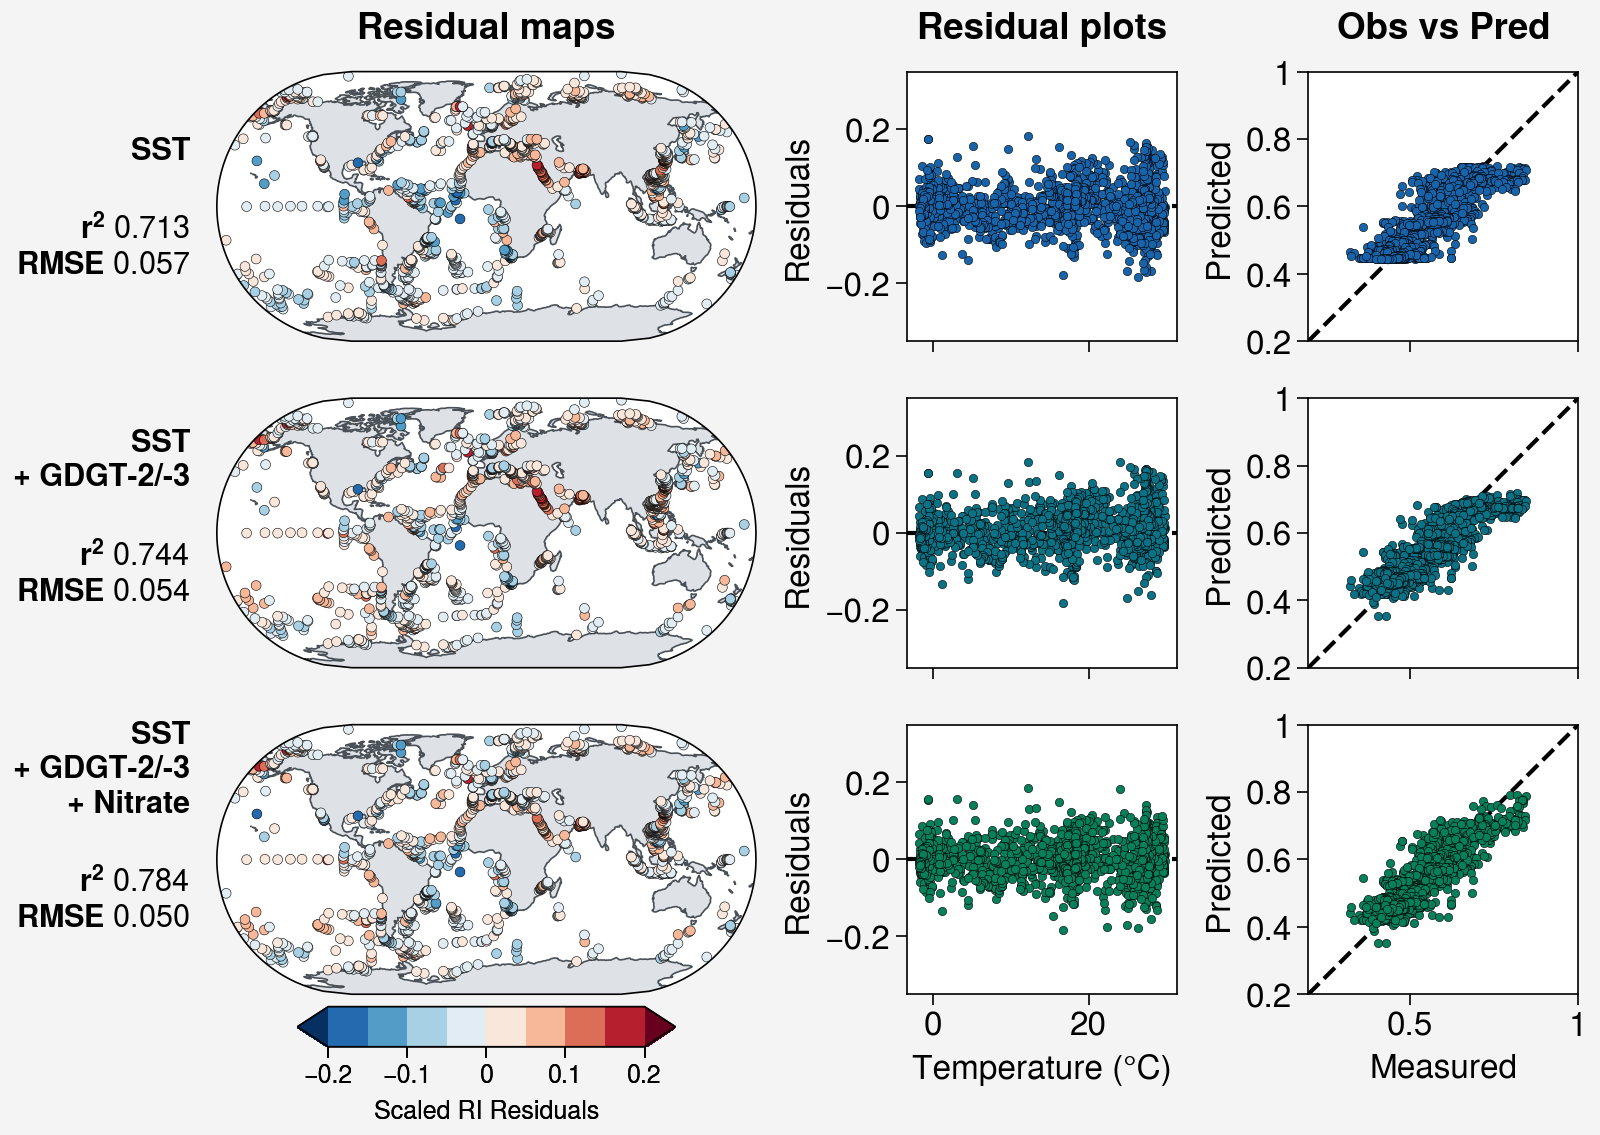

In [197]:
# TEXAS data: Thermo-T cases first, then SST cases
# (measured, predicted, residuals, color, method_label, temperature_field)
texas_data = [
    # Thermo-T cases
    (coretop_df['scaledRI'], predRI_SST_Tonly, RIres_SST_Tonly, 'blue9', 
     'SST', coretop_df['SST']),
    (coretop_df['scaledRI'], predRI_SST_T_g23r, RIres_SST_T_g23r, 'cyan9', 
     'SST\n+ GDGT-2/-3', coretop_df['SST']),
    (coretop_df['scaledRI'], predRI_SST_T_g23r_no3, RIres_SST_T_g23r_no3, 'teal9', 
     f'SST\n+ GDGT-2/-3\n+ Nitrate', coretop_df['SST']),
]

# Calculate metrics
texas_metrics = []
for measured, predicted, residuals, _, _, _ in texas_data:
    nonnan_idx = ~np.isnan(residuals) & ~np.isnan(measured)
    r2 = r2_score(measured[nonnan_idx], predicted[nonnan_idx])
    rmse = np.sqrt(np.mean(residuals[nonnan_idx]**2))
    texas_metrics.append((r2, rmse))

# Create TEXAS figure with extra space between Thermo-T and SST
fig_texas, axs_texas = plot.subplots(
    proj={1:'eck3', 4:'eck3', 7:'eck3',},
    width=8, ncols=3, nrows=3, share=0, wratios=[2, 1, 1],
)

axs_texas.format(
    land=True, landzorder=0, landcolor='gray3',
    coast=True, coastzorder=1, coastcolor='gray7',
    lonlines=30, latlines=30, fontsize=12,
    collabels=['Residual maps', 'Residual plots', 'Obs vs Pred'],
)

# Plot TEXAS rows
for i, ((measured, predicted, residuals, color, method_label, temp_field), (r2, rmse)) in enumerate(zip(texas_data, texas_metrics)):
    
    # Column 0: Map of residuals
    ax = axs_texas[i, 0]
    sc = ax.scatter(
        coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'],
        c=residuals, cmap='RdBu_r', levels=np.arange(-0.2, 0.21, 0.05),
        extend='both', m='.', s=50, zorder=2, mec='k', mew=0.2
    )
    
    # Add method label
    ax.text(-0.05, 0.65, method_label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='right', va='bottom')
    
    # Add metrics
    text = f'$\\mathbf{{r^2}}$ {r2:.3f}\n$\\mathbf{{RMSE}}$ {rmse:.3f}'
    ax.text(-0.05, 0.35, text, transform=ax.transAxes,
            fontsize=11, ha='right', va='center')
    
    # Column 1: Residuals vs Temperature
    ax = axs_texas[i, 1]
    ax.scatter(temp_field, residuals, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.axhline(0, c='k', ls='--', zorder=0)
    
    # Column 2: Predicted vs Measured
    ax = axs_texas[i, 2]
    ax.scatter(measured, predicted, m='.', c=color, mec='k', mew=0.2, zorder=2)
    ax.plot([0.2, 1], [0.2, 1], c='k', ls='--', zorder=0)

# Format TEXAS figure
axs_texas[-1, 0].colorbar(sc, loc='b', label='Scaled RI Residuals', extend='both', shrink=0.7)
axs_texas[:, 0].format(yticklabels=[])
axs_texas[:, 1].format(xlabel='Temperature (°C)', ylabel='Residuals',
                       ylim=(-0.35, 0.35), 
                       tickminor=False)
axs_texas[:, 2].format(xlim=(0.2,1), ylim=(0.2,1), tickminor=False, 
                       xlabel='Measured', ylabel='Predicted')

axs_texas[:-1, :].format(xlabel='',xticklabels=[])
axs_texas.format(
    grid=False
)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig10_TEXAS_SST_calibrations_residuals_maps_and_scatterplots.pdf'
fig_texas.savefig(os.path.join(fpath,fname), dpi=300)

In [150]:
gridded_combined_df.columns

Index(['match_lat_04deg', 'match_lon_04deg', 'regionName', 'reference_name',
       'datatype', 'Strains', 'organism_commonName', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'publicationYear',
       'BIT', 'Latitude', 'Longitude', 'SST', 'SST_1deg', 'SST_1deg_04filled',
       'TEX86', 'ZeroOverZeroCren', 'gdgt23ratio', 'methaneIndex',
       'modernWaterDepth', 'no3_sf2tc_avg', 'no3_sf2tc_tc1deg04filled',
       'ringIndex', 'scaledRI', 't1deg_sf2tc_1deg_04filled', 't_sf2pc_avg',
       't_sf2tc_1deg', 't_sf2tc_1deg_04filled', 't_sf2tc_avg',
       'woa23_no3_sf2tc_1deg', 'woa23_no3_sf2tc_tc1deg04filled'],
      dtype='object')

# PhanTEX Analysis

In [144]:
# Paleo-data plotting
fpath = fr'{local_github_path}/data/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001_extendedRR_121025.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

PhanAlk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
PhanAlk_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI,pubYear
0,NaN,DEQ161-592,NaN,19.13,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
1,NaN,DEQ161-592,NaN,20.56,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
2,NaN,DEQ161-592,NaN,20.97,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
3,NaN,DEQ161-592,NaN,21.78,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
4,NaN,DEQ161-592,NaN,22.09,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35355,NaN,SdrVdium,NaN,244.50,214.5,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35356,NaN,SdrVdium,NaN,260.50,230.5,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35357,NaN,SdrVdium,NaN,268.40,238.4,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35358,NaN,SdrVdium,NaN,284.80,254.8,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020


In [145]:
# PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
# PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
#                                         'GDGT0':'fGDGT_0',
#                                         'GDGT1':'fGDGT_1',
#                                         'GDGT2':'fGDGT_2',
#                                         'GDGT3':'fGDGT_3',
#                                         'Cren':'fGDGT_cren',
#                                         'Crenisomer':'fGDGT_cren_prime'})
# PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)

# features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
# sum_allGDGTs = PhanTEX_df[features].sum(axis=1)
# for feat in features:
#     PhanTEX_df[feat] = PhanTEX_df[feat] / sum_allGDGTs
# PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[feat]*ringNumbers_dict_zhang16.get(feat) for feat in features]).sum(axis=0)
# PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
# PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

# PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
# PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
# PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')

# # Plate reconstructions

# import pygplates

# rot_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# rot_filename="m06c9h_3id_forPgeog_19o_r1c.rot"
# rotation_model = pygplates.RotationModel(rot_filepath+rot_filename)

# poly_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# statPoly_filename="PALEOMAP_PlatePolygons__forPgeog_v19o.gpml"
# static_polygons = pygplates.FeatureCollection(poly_filepath+statPoly_filename)

# from tqdm import tqdm

# start_time = time.time()

# PhanTEX_df['paleolat'] = np.nan
# PhanTEX_df['paleolon'] = np.nan

# for i in tqdm(range(len(PhanTEX_df.ModLat))):
#     if np.isnan(PhanTEX_df.Age.iloc[i]):
#         continue
#     else:
#         point = pygplates.PointOnSphere(float(PhanTEX_df.ModLat.iloc[i]),float(PhanTEX_df.ModLon.iloc[i]))
#         point_feature = pygplates.Feature()
#         point_feature.set_geometry(point)

#         #Assign a point into an associated plate based on modern-day location, rotation files, etc.
#         partitioned_point_features = pygplates.partition_into_plates(static_polygons,
#                                                                 rotation_model,
#                                                                 point_feature) 



#         # Reconstruct the points to Age
#         reconstructed_point_features = []
#         pygplates.reconstruct(partitioned_point_features,
#                                 rotation_model,
#                                 reconstructed_point_features,
#                                 PhanTEX_df.Age.iloc[i])

#         point = reconstructed_point_features[0].get_reconstructed_geometry()
#         latitude, longitude = point.to_lat_lon()

#         PhanTEX_df.paleolat.iloc[i] = np.round(latitude,decimals=5)
#         PhanTEX_df.paleolon.iloc[i] = np.round(longitude,decimals=5)


# print("%.4f seconds" % (time.time() - start_time))
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_df.to_csv(os.path.join(fpath,'PhanTEX_v001_modified_121025.csv'),index=False)

In [146]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanTEX_v001_modified_121025.csv'
PhanTEX_df = pd.read_csv(os.path.join(fpath,fname))

In [147]:
import numpy as np
from scipy.linalg import inv

class MahalanobisDistance:
    def __init__(self):
        self.mean_ = None
        self.cov_inv_ = None
    
    def fit(self, X):
        """Fit the model on reference data"""
        self.mean_ = np.mean(X, axis=0)
        cov = np.cov(X, rowvar=False)
        self.cov_inv_ = inv(cov)
        return self
    
    def distance(self, X):
        """Compute Mahalanobis distance for new data"""
        diff = X - self.mean_
        distances = np.sqrt(np.sum(diff @ self.cov_inv_ * diff, axis=1))
        return distances

X_train = gridded_combined_df[['ringIndex','TEX86']].dropna().to_numpy()
# Usage
md_model = MahalanobisDistance()
md_model.fit(X_train)  # Fit on Dataset 1

# Apply to Dataset 2
X_test = PhanTEX_df[['ringIndex','TEX86']].dropna().to_numpy()
distances = md_model.distance(X_test)
print("Distances:", distances)

### add distances to PhanTEX_df
PhanTEX_df['mahalanobis_distance'] = np.nan
PhanTEX_df.loc[PhanTEX_df[['ringIndex','TEX86']].dropna().index, 'mahalanobis_distance'] = distances
PhanTEX_df['outliers'] = ((PhanTEX_df['mahalanobis_distance']>3.0349) & ~((PhanTEX_df['ringIndex']>3.5)&(PhanTEX_df['TEX86']>0.6)))
PhanTEX_df

Distances: [1.47558095 1.78894721 1.42698797 ... 1.36143745 1.24004266 1.26193488]


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,ringIndex,scaledRI,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10,paleolat,paleolon,mahalanobis_distance,outliers
0,NaN,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.65,...,2.692752,0.673188,2.975410,30.333373,28.061152,28.043613,17.35493,29.48749,1.475581,False
1,NaN,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.65,...,2.676383,0.669096,2.711864,32.086507,29.491964,28.939558,17.34220,29.48924,1.788947,False
2,NaN,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.65,...,2.792211,0.698053,2.599119,30.764599,28.413095,28.266512,17.32728,29.49129,1.426988,False
3,NaN,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.65,...,2.877008,0.719252,3.118881,31.479751,28.996763,28.632522,17.31416,29.49309,1.493471,False
4,NaN,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.65,...,2.626159,0.656540,3.213920,30.576403,28.259500,28.169440,17.30117,29.49487,1.652436,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7885,NaN,South Dover Bridge,NaN,NaN,NaN,677.20,NaN,United States of America,na,38.70,...,2.658444,0.664611,1.967092,28.804278,26.813189,27.239474,39.35486,-57.58087,1.304630,False
7886,NaN,South Dover Bridge,NaN,NaN,NaN,678.10,NaN,United States of America,na,38.70,...,2.871358,0.717839,1.687884,27.495396,25.744951,26.533417,39.35486,-57.58087,1.370354,False
7887,NaN,South Dover Bridge,NaN,NaN,NaN,679.25,NaN,United States of America,na,38.70,...,2.861274,0.715318,1.850609,29.460197,27.348514,27.587086,39.35486,-57.58087,1.361437,False
7888,NaN,South Dover Bridge,NaN,NaN,NaN,679.40,NaN,United States of America,na,38.70,...,2.730487,0.682622,1.906364,28.811618,26.819179,27.243386,39.35486,-57.58087,1.240043,False


In [148]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'Inglis2023_TEX_SDB_PETM.xlsx'

SDB_PETM_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='SDB GDGT',
                            skiprows=2,
                            usecols='B:AE')

SDB_PETM_df['SST_OBrien17'] = predictSSTfromTEX(SDB_PETM_df['TEX86'],method_name='OBrien17')
SDB_PETM_df['SST_Schouten02'] = predictSSTfromTEX(SDB_PETM_df['TEX86'],method_name='schouten02')
SDB_PETM_df['SST_Kim10'] = predictSSTfromTEX(SDB_PETM_df['TEX86'],method_name='kim2010_tex86H')
SDB_PETM_df['scaledRI'] = SDB_PETM_df['Ring Index']/4
SDB_PETM_df['gdgt23ratio'] = SDB_PETM_df['iGDGT2']/SDB_PETM_df['iGDGT3']

SDB_PETM_df = SDB_PETM_df.replace([np.inf,-np.inf],np.nan
                                  ).dropna(subset=['TEX86','Ring Index'
                                                   ]).reset_index(drop=True)
                                  
# Apply to Dataset 2
X_test = SDB_PETM_df[['Ring Index','TEX86']].dropna().to_numpy()
distances = md_model.distance(X_test)
print("Distances:", distances)

### add distances to SDB_PETM_df
SDB_PETM_df['mahalanobis_distance'] = np.nan
SDB_PETM_df.loc[SDB_PETM_df[['Ring Index','TEX86']].dropna().index, 'mahalanobis_distance'] = distances
SDB_PETM_df['outliers'] = ((SDB_PETM_df['mahalanobis_distance']>3.0349) & ~((SDB_PETM_df['Ring Index']>3.5)&(SDB_PETM_df['TEX86']>0.6)))
SDB_PETM_df

Distances: [2.12259994 1.53430607 1.90063905 2.14112063 2.26573836 2.75573919
 2.74819878 2.76966594 2.90975332 2.86807401 2.89845184 2.95860571
 2.7763972  3.10821224 4.62565714 3.09206507 3.01520276 2.790472
 2.55459135 2.93933587 2.39835804 2.10781303 1.45229085 1.38031165
 1.45718347 1.71173234 1.08870243 1.46241368 1.45949776 1.37018182
 1.42009526 1.30462954 1.37035368 1.36143745 1.24004266 1.26193488]


,Sample ID,Sample depth (ft),Sample depth (m),BIGMaC classification,iGDGT0,iGDGT1,iGDGT2,iGDGT3,iGDGTcren,iGDGTcreniso,...,84,95,97.5,SST_OBrien17,SST_Schouten02,SST_Kim10,scaledRI,gdgt23ratio,mahalanobis_distance,outliers
0,19935.0,612.20,186.598560,Soil-type,1119299.318,261272.410,328858.498,163847.931,2269070.487,222546.203,...,34.578011,38.338182,40.468696,31.908584,30.163110,29.350684,0.651619,2.007096,2.122600,False
1,19936.0,616.80,188.000640,Marine-type,668716.871,266487.556,299751.369,155105.679,2223274.752,229869.133,...,33.870809,37.616145,39.545773,31.167286,29.322972,28.835135,0.724908,1.932562,1.534306,False
2,19953.0,626.60,190.987680,Marine-type,367503.271,141574.905,225628.985,92366.221,1463984.727,152689.016,...,37.496241,41.626585,43.908067,34.045028,32.584416,30.788335,0.750551,2.442765,1.900639,False
3,19964.0,631.80,192.572640,Marine-type,94483.914,28436.049,44476.914,21089.996,405488.487,48341.797,...,39.703063,44.191174,46.663075,35.895897,34.682070,31.979937,0.776867,2.108910,2.141121,False
4,19965.0,634.20,193.304160,Marine-type,213647.565,83044.093,147928.536,60678.490,1173592.048,157047.273,...,40.412862,44.909643,47.317431,36.760078,35.661477,32.520346,0.801156,2.437907,2.265738,False
5,19954.0,636.10,193.883280,Marine-type,43260.125,14749.238,41074.430,14389.215,350935.706,52290.585,...,45.792156,51.007046,53.901596,40.564737,39.973427,34.789159,0.848158,2.854529,2.755739,False
6,19937.0,640.00,195.072000,Soil-type,229827.601,50661.319,98853.928,40185.322,819795.731,160722.044,...,44.219807,49.204205,51.870899,39.142765,38.361858,33.961347,0.766224,2.459951,2.748199,False
7,19938.0,644.40,196.413120,Marine-type,148491.207,77518.352,197541.544,73973.235,1582920.446,277271.212,...,45.798211,50.823528,53.551757,40.366353,39.748592,34.675043,0.862624,2.670446,2.769666,False
8,19942.0,646.10,196.931280,Marine-type,68368.104,38319.662,98954.533,32648.354,906821.177,177464.696,...,46.542958,51.704833,54.586716,41.158286,40.646116,35.127988,0.882996,3.030920,2.909753,False
9,19966.0,647.00,197.205600,Marine-type,78538.058,34870.286,93524.789,31361.482,865668.003,153786.481,...,46.581460,51.801787,54.699924,41.105020,40.585749,35.097738,0.873350,2.982155,2.868074,False


In [149]:
# Plate reconstructions

import pygplates

rot_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
rot_filename="m06c9h_3id_forPgeog_19o_r1c.rot"
rotation_model = pygplates.RotationModel(rot_filepath+rot_filename)

poly_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
statPoly_filename="PALEOMAP_PlatePolygons__forPgeog_v19o.gpml"
static_polygons = pygplates.FeatureCollection(poly_filepath+statPoly_filename)

from tqdm import tqdm

start_time = time.time()

SDB_PETM_df['Age'] = 56
SDB_PETM_df['ModLat'] = 38.74704
SDB_PETM_df['ModLon'] = -76.00697
SDB_PETM_df['paleolat'] = np.nan
SDB_PETM_df['paleolon'] = np.nan

for i in tqdm(range(len(SDB_PETM_df.ModLat))):
    if np.isnan(SDB_PETM_df.Age.iloc[i]):
        continue
    else:
        point = pygplates.PointOnSphere(float(SDB_PETM_df.ModLat.iloc[i]),float(SDB_PETM_df.ModLon.iloc[i]))
        point_feature = pygplates.Feature()
        point_feature.set_geometry(point)

        #Assign a point into an associated plate based on modern-day location, rotation files, etc.
        partitioned_point_features = pygplates.partition_into_plates(static_polygons,
                                                                rotation_model,
                                                                point_feature) 



        # Reconstruct the points to Age
        reconstructed_point_features = []
        pygplates.reconstruct(partitioned_point_features,
                                rotation_model,
                                reconstructed_point_features,
                                SDB_PETM_df.Age.iloc[i])

        point = reconstructed_point_features[0].get_reconstructed_geometry()
        latitude, longitude = point.to_lat_lon()

        SDB_PETM_df.paleolat.iloc[i] = np.round(latitude,decimals=5)
        SDB_PETM_df.paleolon.iloc[i] = np.round(longitude,decimals=5)

ModuleNotFoundError: No module named 'pygplates'

In [ ]:
fig, axs = plot.subplots(ncols=2,
                         width=10)

ax = axs[0]
plot_x = gridded_combined_df['TEX86']
plot_y = gridded_combined_df['ringIndex']
sc = ax.scatter(plot_x, plot_y, 
                # c=gridded_combined_df['mahalanobis_distance'],
                cmap='viridis',
                levels=np.arange(0,10,1),
                s=20,mec='k',
                zorder=2
                )
ax.format(
    title='Training Data Mahalanobis Distance',
    fontsize=11
)

ax = axs[1]
plot_x = PhanTEX_df['TEX86']
plot_y = PhanTEX_df['ringIndex']
sc = ax.scatter(plot_x, plot_y, 
                c=PhanTEX_df['mahalanobis_distance'],
                cmap='viridis',
                levels=np.arange(0,10,1),
                s=20,mec='k',
                zorder=2,
                )


outliers = PhanTEX_df[((PhanTEX_df['mahalanobis_distance']>3.0349)
                       & ~((PhanTEX_df['ringIndex']>3.5)&(PhanTEX_df['TEX86']>0.6)))]
ax.scatter(outliers['TEX86'], outliers['ringIndex'], 
           s=50,facecolor='none',edgecolor='red',linewidth=2,
           label='Outliers (D>3.0349)',
           zorder=3)



ax.format(
    title='Training Data Mahalanobis Distance',
    fontsize=11
)

In [ ]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[PhanTEX_df['outliers']==False].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    if group_name in PhanAlk_df['SiteName'].unique():
        # print(f"Site: {group_name}")
        if not group_data.empty:
            plot_age = group_data['Age'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['Age'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=8, ha='left', va='center', color='black')
            
        sel_uk_data = PhanAlk_df[PhanAlk_df['SiteName']==group_name]    
        if not sel_uk_data.empty:
            plot_age_uk = sel_uk_data['Age'].values
            j_pos_array_uk = np.full_like(plot_age_uk, jj+0.25, dtype=float)
            ax.scatter(plot_age_uk, j_pos_array_uk, m='|', s=80, lw=0.5, color='gray3', zorder=0)
            
        jj += 1
                
        
ax.format(
    xscale='log',
    xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

In [ ]:
import xarray as xr
import xesmf as xe
import numpy as np
import gc
import os
import hashlib

def regrid_curvilinear_to_latlon(
    ds,
    var_names,
    lat_name=None,
    lon_name=None,
    target_res=0.5,
    lat_range=(-90, 90),
    lon_range=(0, 360),
    method='bilinear',
    periodic=True,
    squeeze_dims=None,
    keep_attrs=True,
):
    """
    Regrid data from curvilinear grid to regular lat/lon grid.
    """
    regridder = None
    
    # Create unique weight filename based on grid configuration
    grid_config = f"{method}_{target_res}_{lat_range[0]}_{lat_range[1]}_{lon_range[0]}_{lon_range[1]}"
    grid_hash = hashlib.md5(grid_config.encode()).hexdigest()[:8]
    weight_file = f'regrid_weights_{grid_hash}.nc'
    
    try:
        if isinstance(var_names, str):
            var_names = [var_names]
        
        # Auto-detect lat/lon coordinate names
        if lat_name is None or lon_name is None:
            print("Auto-detecting coordinate names...")
            
            lat_candidates = ['TLAT', 'lat', 'latitude', 'LAT', 'Lat']
            lon_candidates = ['TLONG', 'lon', 'longitude', 'LON', 'Lon', 'LONG']
            
            for lat_cand in lat_candidates:
                if lat_cand in ds:
                    lat_name = lat_cand
                    print(f"  Found latitude: {lat_name}")
                    break
            
            for lon_cand in lon_candidates:
                if lon_cand in ds:
                    lon_name = lon_cand
                    print(f"  Found longitude: {lon_name}")
                    break
            
            if lat_name is None or lon_name is None:
                raise ValueError(
                    f"Could not auto-detect coordinates.\n"
                    f"Available variables: {list(ds.variables)}\n"
                    f"Please specify lat_name and lon_name explicitly."
                )
        
        # Get dimensions
        lat_dims = ds[lat_name].dims
        lon_dims = ds[lon_name].dims
        
        if lat_dims != lon_dims:
            raise ValueError(
                f"Latitude and longitude have different dimensions:\n"
                f"  {lat_name}: {lat_dims}\n"
                f"  {lon_name}: {lon_dims}"
            )
        
        if len(lat_dims) != 2:
            raise ValueError(
                f"Expected 2D coordinates, got {len(lat_dims)}D: {lat_dims}"
            )
        
        lat_dim, lon_dim = lat_dims
        print(f"  Dimensions: {lat_dim}, {lon_dim}")
        
        # Get source coordinates
        lat_vals = ds[lat_name].values.copy()
        lon_vals = ds[lon_name].values.copy()
        
        print(f"\nSource coordinates:")
        print(f"  Lat range: [{lat_vals.min():.2f}, {lat_vals.max():.2f}]")
        print(f"  Lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Convert source longitudes if needed
        if lon_range[0] < 0 and lon_vals.min() >= 0:
            # Target is -180-180 but source is 0-360
            print(f"  Converting source lon from [0, 360] to [-180, 180]...")
            lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        elif lon_range[0] >= 0 and lon_vals.min() < 0:
            # Target is 0-360 but source is -180-180
            print(f"  Converting source lon from [-180, 180] to [0, 360]...")
            lon_vals = np.where(lon_vals < 0, lon_vals + 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Create source grid
        print("\nCreating source grid...")
        ds_in = xr.Dataset({
            'lat': ([lat_dim, lon_dim], lat_vals),
            'lon': ([lat_dim, lon_dim], lon_vals),
        })
        
        # Create target grid
        print("Creating target grid...")
        print(f"  Lat range: {lat_range}")
        print(f"  Lon range: {lon_range}")
        print(f"  Resolution: {target_res}°")
        
        lat_out = np.arange(lat_range[0], lat_range[1] + target_res/2, target_res)
        lon_out = np.arange(lon_range[0], lon_range[1] + target_res/2, target_res)
        
        ds_out = xr.Dataset({
            'lat': (['lat'], lat_out),
            'lon': (['lon'], lon_out),
        })
        
        print(f"  Target grid: {len(lat_out)} x {len(lon_out)}")
        
        # Check if weight file exists
        if os.path.exists(weight_file):
            print(f"\nFound existing weight file: {weight_file}")
            reuse_weights = True
        else:
            print(f"\nWeight file not found, will create: {weight_file}")
            print(f"  (Grid config hash: {grid_hash})")
            reuse_weights = False
        
        # Create regridder
        print(f"Creating regridder (method: {method})...")
        try:
            regridder = xe.Regridder(
                ds_in, ds_out, 
                method, 
                periodic=periodic,
                filename=weight_file,
                reuse_weights=reuse_weights
            )
            print("✓ Regridder created")
        except Exception as e:
            if reuse_weights and os.path.exists(weight_file):
                print(f"⚠ Error reusing weights, deleting and recreating...")
                os.remove(weight_file)
                regridder = xe.Regridder(
                    ds_in, ds_out, 
                    method, 
                    periodic=periodic,
                    filename=weight_file,
                    reuse_weights=False
                )
                print("✓ Regridder created")
            else:
                raise e
        
        # Regrid variables
        regridded_vars = {}
        for var_name in var_names:
            print(f"\n{'='*60}")
            print(f"Regridding {var_name}...")
            print(f"{'='*60}")
            
            if var_name not in ds:
                print(f"  ⚠ Warning: {var_name} not found in dataset, skipping")
                continue
            
            var = ds[var_name]
            
            # Squeeze dimensions
            if squeeze_dims is not None:
                if isinstance(squeeze_dims, str):
                    squeeze_dims = [squeeze_dims]
                for dim in squeeze_dims:
                    if dim in var.dims:
                        var = var.squeeze(dim)
                        print(f"  Squeezed dimension: {dim}")
            
            print(f"  Original shape: {var.shape}")
            print(f"  Original dims: {var.dims}")
            
            # Find time dimension
            time_dim = None
            for dim in var.dims:
                if dim not in [lat_dim, lon_dim]:
                    time_dim = dim
                    break
            
            # Regrid
            if time_dim and time_dim in var.dims:
                print(f"  Processing {var.sizes[time_dim]} time steps...")
                regridded_list = []
                n_time = var.sizes[time_dim]
                
                for t in range(n_time):
                    print(f"    Time step {t+1}/{n_time}", end='\r')
                    chunk = var.isel({time_dim: t})
                    chunk_regrid = regridder(chunk)
                    regridded_list.append(chunk_regrid)
                    del chunk
                
                print(f"    Time step {n_time}/{n_time} - Done!     ")
                
                var_regridded = xr.concat(regridded_list, dim=time_dim)
                var_regridded = var_regridded.assign_coords({time_dim: var[time_dim]})
                
                del regridded_list
                gc.collect()
            else:
                print(f"  Processing single time step...")
                var_regridded = regridder(var)
            
            # Assign coordinates
            var_regridded = var_regridded.assign_coords({
                'lat': ds_out.lat,
                'lon': ds_out.lon,
            })
            
            if keep_attrs:
                var_regridded.attrs = var.attrs
            
            regridded_vars[var_name] = var_regridded
            print(f"  ✓ {var_name} regridded successfully")
            print(f"  Output shape: {var_regridded.shape}")
        
        # Create output dataset
        ds_regridded = xr.Dataset(regridded_vars)
        
        if keep_attrs:
            ds_regridded.attrs = ds.attrs
        
        print(f"\n{'='*60}")
        print("✓ ALL VARIABLES REGRIDDED SUCCESSFULLY!")
        print(f"  Weight file: {weight_file}")
        print(f"  Variables: {list(regridded_vars.keys())}")
        print(f"  Output lon range: [{ds_regridded.lon.min().values:.2f}, {ds_regridded.lon.max().values:.2f}]")
        print(f"{'='*60}")
        
        return ds_regridded
        
    finally:
        # Cleanup
        if regridder is not None:
            print("\nCleaning up...")
            del regridder
        
        gc.collect()
        print("✓ Cleanup complete")

In [ ]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
T_1deg_da

# PETM climate simulations and PETM-DA

In [ ]:
# import glob
# import re

# fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim'
# fname = f'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.1901-2000.climo.nc'

# pattern = os.path.join(fpath, '*iPETM*pop.h*.nc')
# ### find files with iPETM and pop.h in the name
# ipetm_re = re.compile(r'iPETM\d+x')


# matches = glob.glob(pattern)

# for fn in glob.glob(pattern):
#     basename = os.path.basename(fn)
#     m = ipetm_re.search(basename)
#     if m:
#         print(m.group(0))   # → iPETM09x
#         print(basename)
#     else:
#         print(f"No iPETM token found in {basename}")
    
    
#     ds = xr.open_dataset(fn)
#     display(ds)
    
#     break 

#     ds = ds.drop_vars(["ULONG", "ULAT"], errors="ignore")

#     ds_TEMP = ds['TEMP']
#     ds_TEMP['lat'] = ds_TEMP['TLAT'].copy()
#     ds_TEMP['lon'] = ds_TEMP['TLONG'].copy()

#     # 1. Define your target grid
#     lat_out = np.arange(T_1deg_da.lat.min(), T_1deg_da.lat.max()+0.1, 1.0)
#     lon_out = np.arange(T_1deg_da.lon.min(), T_1deg_da.lon.max()+0.1, 1.0)
    
#     ds_out = xr.Dataset({
#         "lat": (["lat"], lat_out),
#         "lon": (["lon"], lon_out),
#     })

#     # 2. Create the regridder and interpolate
#     regridder = xe.Regridder(ds_TEMP, ds_out, "bilinear", periodic=True)
#     field_reg = regridder(ds_TEMP)
#     field_reg.name = 'TEMP'

#     fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'
#     fname = f'Zhu19_Science_EoceneSim_fullDepth_regridded_{m.group(0)}.nc'
    
#     field_reg.to_netcdf(os.path.join(fpath, fname), mode='w', format='NETCDF4', unlimited_dims='time')
#     print(f"Saved regridded data to {os.path.join(fpath, fname)}")



fpath = fr'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM01x.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM03x.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM06x.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM09x.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))



In [ ]:
iPETM_03x_ds

In [ ]:
# fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
# fname = 'PETMDA_OCN_annual.nc'
# PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

# PETMDA_ds_regridded = regrid_curvilinear_to_latlon(
#     PETMDA_ds,
#     var_names=['sst'],
#     target_res=1.0,
#     lat_range=(T_1deg_da.lat.min(), T_1deg_da.lat.max()+1.0),
#     lon_range=(T_1deg_da.lon.min(), T_1deg_da.lon.max()+1.0),
# )
    
# fname = 'PETMDA_OCN_annual_regridded.nc'
# PETMDA_ds_regridded.to_netcdf(os.path.join(fpath,fname), mode='w', format='NETCDF4', unlimited_dims='time')

fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual_regridded.nc'
PETMDA_ds_regridded = xr.open_dataset(os.path.join(fpath,fname))
PETMDA_ds_regridded

In [ ]:
PhanTEX_df['SST_OBrien17'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='OBrien17')


In [ ]:
SDB_PETM_df['TEX86'].plot()

In [ ]:
site_names_list = ['Wilson Lake','ODP1172','ODP959','South Dover Bridge']
PhanTEX_PETM_df = PhanTEX_df[
  PhanTEX_df['outliers']==False][PhanTEX_df['SiteName'].isin(site_names_list)].reset_index(drop=True)

### for Bass River --- keep only samples with SampleDepth 350 - 400 m
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='Bass River') & 
                                    ( (PhanTEX_PETM_df['SampleDepth'] < 380) | 
                                      (PhanTEX_PETM_df['SampleDepth'] > 390)
                                    )
                                   )].reset_index(drop=True)

### for ODP1172 --- keep only samples with Age 50 - 55 Ma
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='ODP1172') & 
                                    ( (PhanTEX_PETM_df['Age'] < 55.85) | 
                                      (PhanTEX_PETM_df['Age'] > 56.1)
                                    )
                                   )].reset_index(drop=True)

### for IB10B --- keep only samples with SampleDepth 50 - 90 m
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='IB10B') & 
                                    ( (PhanTEX_PETM_df['SampleDepth'] < 60) | 
                                      (PhanTEX_PETM_df['SampleDepth'] > 95)
                                    )
                                   )].reset_index(drop=True)

### for ODP959 --- keep only samples with MBSF 790 to 810 m and pubYear Frieling2018
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='ODP959') & 
                                    ( (PhanTEX_PETM_df['MBSF'] < 801) | 
                                      (PhanTEX_PETM_df['MBSF'] > 810) |
                                      (PhanTEX_PETM_df['pubYear'] != 'Frieling2018')
                                    )
                                   )].reset_index(drop=True)

### for South Dover Bridge --- keep only samples with Sample Depth from 611
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='South Dover Bridge') & 
                                    ((PhanTEX_PETM_df['SampleDepth'] < 611) | 
                                     (PhanTEX_PETM_df['SampleDepth'] > 700)
                                    )
                                   )].reset_index(drop=True)

In [ ]:
PhanTEX_PETM_df['pubYear'].unique()

In [ ]:
PETM_interval_dict_sampleDepth = {
    'ODP174AX Ancora': (165.5,171.5),
    'Wilson Lake': (96.5, 109.5),
    'Bass River': (382.5,386),
    'IB10B': (70,80),
    'South Dover Bridge': (630, 670),
}

PETM_interval_dict_Age = {
    'ODP1172': (55.94, 56.01),
}

PETM_interval_MBSF_dict = {
    'ODP959': (803,804.05),
}

### assign 'PETM', 'pre-PETM', 'post-PETM' based on Age or SampleDepth
PhanTEX_PETM_df['PETM_interval'] = 'non-PETM'
for i in range(len(PhanTEX_PETM_df)):
    site_name = PhanTEX_PETM_df.loc[i,'SiteName']
    if site_name in PETM_interval_dict_sampleDepth.keys():
        sample_depth = PhanTEX_PETM_df.loc[i,'SampleDepth']
        petm_start, petm_end = PETM_interval_dict_sampleDepth[site_name]
        print(f"Site: {site_name}, SampleDepth: {sample_depth}, PETM interval: {petm_start}-{petm_end}")
        if sample_depth >= petm_start and sample_depth <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif sample_depth < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
            print(f"  Assigned post-PETM")
        elif sample_depth > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")
    elif site_name in PETM_interval_dict_Age.keys():
        age = PhanTEX_PETM_df.loc[i,'Age']
        petm_start, petm_end = PETM_interval_dict_Age[site_name]
        print(f"Site: {site_name}, Age: {age}, PETM interval: {petm_start}-{petm_end}")
        if age >= petm_start and age <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif age < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
            print(f"  Assigned post-PETM")
        elif age > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")
    elif site_name in PETM_interval_MBSF_dict.keys():
        mbsf = PhanTEX_PETM_df.loc[i,'MBSF']
        petm_start, petm_end = PETM_interval_MBSF_dict[site_name]
        if mbsf >= petm_start and mbsf <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif mbsf < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
        elif mbsf > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'


In [ ]:
PhanTEX_PETM_df['SiteName'].unique()

In [ ]:
fig, axs = plot.subplots(width=9,nrows=len(site_names_list),ncols=3, height=10, share=0)

for i, site_name in enumerate(site_names_list):
    sel_site_df = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]
    
    if site_name == 'ODP959':
        plot_data = sel_site_df.sort_values('MBSF').reset_index(drop=True)
        # Plot on primary axis
        axs[i,0].plot(plot_data['MBSF'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['MBSF'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['MBSF'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')

    
    elif sel_site_df['SampleDepth'].isnull().all():
        plot_data = sel_site_df.sort_values('Age').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['Age'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['Age'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['Age'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        

    else:
        plot_data = sel_site_df.sort_values('SampleDepth').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['SampleDepth'], plot_data['TEX86'], m='.', c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['SampleDepth'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['SampleDepth'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')

    axs[i,0].format(ltitle=site_name)

In [ ]:
grouped_site_df = PhanTEX_PETM_df.groupby('SiteName')
for site_name, sel_site_df in grouped_site_df:
    print(f"Site: {site_name}")
    
    search_tolerance = np.std(sel_site_df['TEX86'], ddof=1) * 2 if site_name != 'ODP959' else 0.25
    print (np.std(sel_site_df['TEX86'], ddof=1)*2)
    print("Search tolerance based on 2*SD of TEX86 values: ",f"{search_tolerance:.4f}")
    print(f"  Search tolerance: {search_tolerance:.4f}")
    pred_bsr_sst = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30, 
            prior_std=20 if site_name != 'ODP959' else 25,
            temptype='sst',
            search_tol=search_tolerance ,
            nens=100).percentile([10,25,40,50,60,75,90])
    
    pred_bsr_subt = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30, 
            prior_std=20 if site_name != 'ODP959' else 25,
            temptype='subt',
            search_tol=search_tolerance,
            nens=100).percentile([10,25,40,50,60,75,90])
    
    ### add predictions to dataframe
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_pred'] = pred_bsr_sst[:,3]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_pred'] = pred_bsr_subt[:,3]
    
    ### collect P10, P25, P75, P90
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P10'] = pred_bsr_sst[:,0]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P25'] = pred_bsr_sst[:,1]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P40'] = pred_bsr_sst[:,2]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P60'] = pred_bsr_sst[:,4]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P75'] = pred_bsr_sst[:,5]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P90'] = pred_bsr_sst[:,6]
    
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P10'] = pred_bsr_subt[:,0]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P25'] = pred_bsr_subt[:,1]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P40'] = pred_bsr_subt[:,2]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P60'] = pred_bsr_subt[:,4]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P75'] = pred_bsr_subt[:,5]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P90'] = pred_bsr_subt[:,6]
    
    
PhanTEX_PETM_df

In [ ]:
pred_bsr_sst_SDB = bsr.predict_seatemp_analog(
        SDB_PETM_df['TEX86'],
        prior_mean=30, 
        prior_std=20 if site_name != 'ODP959' else 25,
        temptype='sst',
        search_tol=search_tolerance ,
        nens=100).percentile([10,25,40,50,60,75,90])

pred_bsr_subt_SDB = bsr.predict_seatemp_analog(
        SDB_PETM_df['TEX86'],
        prior_mean=30, 
        prior_std=20 if site_name != 'ODP959' else 25,
        temptype='subt',
        search_tol=search_tolerance,
        nens=100).percentile([10,25,40,50,60,75,90])

### add predictions to dataframe
SDB_PETM_df['BSR_SST_pred'] = pred_bsr_sst_SDB[:,3]
SDB_PETM_df['BSR_subt_pred'] = pred_bsr_subt_SDB[:,3]

### collect P10, P25, P75, P90
SDB_PETM_df['BSR_SST_P10'] = pred_bsr_sst_SDB[:,0]
SDB_PETM_df['BSR_SST_P25'] = pred_bsr_sst_SDB[:,1]
SDB_PETM_df['BSR_SST_P40'] = pred_bsr_sst_SDB[:,2]
SDB_PETM_df['BSR_SST_P60'] = pred_bsr_sst_SDB[:,4]
SDB_PETM_df['BSR_SST_P75'] = pred_bsr_sst_SDB[:,5]
SDB_PETM_df['BSR_SST_P90'] = pred_bsr_sst_SDB[:,6]

SDB_PETM_df['BSR_subt_P10'] = pred_bsr_subt_SDB[:,0]
SDB_PETM_df['BSR_subt_P25'] = pred_bsr_subt_SDB[:,1]
SDB_PETM_df['BSR_subt_P40'] = pred_bsr_subt_SDB[:,2]
SDB_PETM_df['BSR_subt_P60'] = pred_bsr_subt_SDB[:,4]
SDB_PETM_df['BSR_subt_P75'] = pred_bsr_subt_SDB[:,5]
SDB_PETM_df['BSR_subt_P90'] = pred_bsr_subt_SDB[:,6]

In [ ]:
try:
    multivar_post_ds.close()
    multivar_post_ds2.close()
except:
    pass
fwd_post = "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_020526"
PhanTEX_PETM_df['pred_T_TEXAS_Tonly'] = predict_temperature_from_RI(
    scaledRI=PhanTEX_PETM_df['scaledRI'].astype(float).tolist(),
    prior_mu_t= 30.0,
    prior_sigma_t=6,
    fwd_posterior_name=fwd_post,
    site_name='PETM_sites',
    save_results=True,
    threads_per_chain=4,
    temptype='sst',
)["p50"]

########################
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.77_020526"
PhanTEX_PETM_df['pred_T_TEXAS_Tg23r'] = predict_temperature_from_RI(
    scaledRI=PhanTEX_PETM_df['scaledRI'].astype(float).tolist(),
    prior_mu_t= 30.0,
    prior_sigma_t=6,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':PhanTEX_PETM_df['gdgt23ratio'].values,
    },
    site_name='PETM_sites',
    save_results=True,
    threads_per_chain=4,
    temptype='sst',
)["p50"]

In [ ]:
SDB_PETM_df.columns

In [ ]:

try:
    SDB_multivar_post_ds.close()
    SDB_multivar_post_ds2.close()
except:
    pass

fwd_post = "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_020526"
SDB_PETM_df['pred_T_TEXAS_Tonly'] = predict_temperature_from_RI(
    scaledRI=SDB_PETM_df['scaledRI'].astype(float).tolist(),
    prior_mu_t= 30.0,
    prior_sigma_t=6,
    fwd_posterior_name=fwd_post,
    site_name='SDB_PETM_Inglis23',
    save_results=True,
    threads_per_chain=4,
    temptype='sst',
)["p50"]

########################
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.77_020526"
SDB_PETM_df['pred_T_TEXAS_Tg23r'] = predict_temperature_from_RI(
    scaledRI=SDB_PETM_df['scaledRI'].astype(float).tolist(),
    prior_mu_t= 30.0,
    prior_sigma_t=6,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':SDB_PETM_df['gdgt23ratio'].values,
    },
    site_name='SDB_PETM_Inglis23',
    save_results=True,
    threads_per_chain=4,
    temptype='sst',
)["p50"]

In [ ]:
fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "PETM_sites_invT_gen_logi_fixed_univ_unconstrained_sst_direct.nc"

multivar_post_ds = xr.open_dataset(os.path.join(fpath,fname))

PhanTEX_PETM_df['pred_T_TEXAS_Tonly_p10'] = multivar_post_ds.sel(quantile=0.10).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tonly_p25'] = multivar_post_ds.sel(quantile=0.25).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tonly_p40'] = multivar_post_ds.sel(quantile=0.40).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tonly_p60'] = multivar_post_ds.sel(quantile=0.60).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tonly_p75'] = multivar_post_ds.sel(quantile=0.75).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tonly_p90'] = multivar_post_ds.sel(quantile=0.90).t_est.values

fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "PETM_sites_invT_gen_logi_fixed_multiv_unconstrained_sst_gdgt23ratio_no3_0.0_direct.nc"

multivar_post_ds2 = xr.open_dataset(os.path.join(fpath,fname))
PhanTEX_PETM_df['pred_T_TEXAS_Tg23r_p10'] = multivar_post_ds2.sel(quantile=0.10).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tg23r_p25'] = multivar_post_ds2.sel(quantile=0.25).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tg23r_p40'] = multivar_post_ds2.sel(quantile=0.40).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tg23r_p60'] = multivar_post_ds2.sel(quantile=0.60).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tg23r_p75'] = multivar_post_ds2.sel(quantile=0.75).t_est.values
PhanTEX_PETM_df['pred_T_TEXAS_Tg23r_p90'] = multivar_post_ds2.sel(quantile=0.90).t_est.values

In [ ]:
fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "SDB_PETM_Inglis23_invT_gen_logi_fixed_univ_unconstrained_sst_direct.nc"

SDB_multivar_post_ds = xr.open_dataset(os.path.join(fpath,fname))
SDB_PETM_df['pred_T_TEXAS_Tonly_p10'] = SDB_multivar_post_ds.sel(quantile=0.10).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tonly_p25'] = SDB_multivar_post_ds.sel(quantile=0.25).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tonly_p40'] = SDB_multivar_post_ds.sel(quantile=0.40).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tonly_p60'] = SDB_multivar_post_ds.sel(quantile=0.60).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tonly_p75'] = SDB_multivar_post_ds.sel(quantile=0.75).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tonly_p90'] = SDB_multivar_post_ds.sel(quantile=0.90).t_est.values

fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "SDB_PETM_Inglis23_invT_gen_logi_fixed_multiv_unconstrained_sst_gdgt23ratio_no3_0.0_direct.nc"

SDB_multivar_post_ds2 = xr.open_dataset(os.path.join(fpath,fname))
SDB_PETM_df['pred_T_TEXAS_Tg23r_p10'] = SDB_multivar_post_ds2.sel(quantile=0.10).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tg23r_p25'] = SDB_multivar_post_ds2.sel(quantile=0.25).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tg23r_p40'] = SDB_multivar_post_ds2.sel(quantile=0.40).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tg23r_p60'] = SDB_multivar_post_ds2.sel(quantile=0.60).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tg23r_p75'] = SDB_multivar_post_ds2.sel(quantile=0.75).t_est.values
SDB_PETM_df['pred_T_TEXAS_Tg23r_p90'] = SDB_multivar_post_ds2.sel(quantile=0.90).t_est.values

In [ ]:
fig, axs = plot.subplots(width=9,nrows=len(site_names_list),ncols=3, height=10, share=0)

for i, site_name in enumerate(site_names_list):
    sel_site_df = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]

    


    ###########
    iPETM_3x_temp = iPETM_03x_ds['TEMP'].squeeze('z_t').mean('time').sel(
        lat = sel_site_df['paleolat'].values[0],
        lon = sel_site_df['paleolon'].values[0],
        method='nearest'
    ).values
    
    iPETM_6x_temp = iPETM_06x_ds['TEMP'].squeeze('z_t').mean('time').sel(
        lat = sel_site_df['paleolat'].values[0],
        lon = sel_site_df['paleolon'].values[0],
        method='nearest'
    ).values
    
    iPETM_9x_temp = iPETM_09x_ds['TEMP'].squeeze('z_t').mean('time').sel(
        lat = sel_site_df['paleolat'].values[0],
        lon = sel_site_df['paleolon'].values[0],
        method='nearest'
    ).values    
    
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0],
        lon=sel_site_df['paleolon'].values[0],
        method='nearest'
    ).isel(nTime=1).values
    
    PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0],
        lon=sel_site_df['paleolon'].values[0],
        method='nearest'
    ).isel(nTime=0).values
    
    ii = 1
    while np.isnan(prePETM_DA_temp):
        prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0]-ii,
        lon=sel_site_df['paleolon'].values[0]+ii,
        method='nearest'
        ).isel(nTime=1).values
        
        iPETM_3x_temp = iPETM_03x_ds['TEMP'].squeeze('z_t').mean('time').sel(
        lat = sel_site_df['paleolat'].values[0]-ii,
        lon = sel_site_df['paleolon'].values[0]+ii,
        method='nearest'
        ).values
        ii += 1
        
        iPETM_6x_temp = iPETM_06x_ds['TEMP'].squeeze('z_t').mean('time').sel(
        lat = sel_site_df['paleolat'].values[0]-ii,
        lon = sel_site_df['paleolon'].values[0]+ii,
        method='nearest'
        ).values
        ii += 1
    
    ii = 1
    while np.isnan(PETM_DA_temp):
        PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0]-ii,
        lon=sel_site_df['paleolon'].values[0]+ii,
        method='nearest'
        ).isel(nTime=0).values
        
        iPETM_9x_temp = iPETM_09x_ds['TEMP'].squeeze('z_t').mean('time').sel(
        lat = sel_site_df['paleolat'].values[0]-ii,
        lon = sel_site_df['paleolon'].values[0]+ii,
        method='nearest'
        ).values
        ii += 1
        
    axs[i,1].axhline(prePETM_DA_temp, color='black', ls='--', lw=1, label='Pre-PETM DA SST')
    axs[i,1].axhline(PETM_DA_temp, color='k', ls='-', lw=1, label='PETM DA SST')
    
    axs[i,1].axhline(iPETM_3x_temp, color='red9', ls='--', lw=1, label='iPETM 3x')
    axs[i,1].axhline(iPETM_6x_temp, color='red9', ls='--', lw=1, label='iPETM 6x')
    axs[i,1].axhline(iPETM_9x_temp, color='red9', ls='-', lw=1, label='iPETM 9x')
    
    axs[i,1].format(ltitle=f'Site: {site_name}\nPre-PETM DA SST: {prePETM_DA_temp:.1f} °C\nPETM DA SST: {PETM_DA_temp:.1f} °C\n(ΔT: {PETM_DA_temp - prePETM_DA_temp:.1f} °C)')
    
    if site_name == 'ODP959':
        plot_data = sel_site_df.sort_values('MBSF').reset_index(drop=True)
        # Plot on primary axis
        axs[i,0].plot(plot_data['MBSF'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['MBSF'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['MBSF'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['BSR_SST_pred'], m='.', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['BSR_subt_pred'],ls='--', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['pred_T_TEXAS_Tg23r'], m='.', 
                      label='', color='k')
        axs[i,1].plot(plot_data['MBSF'], plot_data['pred_T_TEXAS_Tonly'], ls='--', 
                      label='', color='k')
    
    elif sel_site_df['SampleDepth'].isnull().all():
        plot_data = sel_site_df.sort_values('Age').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['Age'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['Age'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        #### prePETM highlights
        prepetm_data = plot_data[plot_data['PETM_interval']=='pre-PETM']
        axs[i,0].scatter(prepetm_data['Age'], prepetm_data['TEX86'],
                         s=60, facecolor='none', edgecolor='blue', label='pre-PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['Age'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        axs[i,1].plot(plot_data['Age'], plot_data['BSR_SST_pred'], m='.', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['Age'], plot_data['BSR_subt_pred'],ls='--', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['Age'], plot_data['pred_T_TEXAS_Tg23r'], m='.', 
                      label='', color='k')
        axs[i,1].plot(plot_data['Age'], plot_data['pred_T_TEXAS_Tonly'], ls='--', 
                      label='', color='k')
        

    else:
        plot_data = sel_site_df.sort_values('SampleDepth').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['SampleDepth'], plot_data['TEX86'], m='.', c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['SampleDepth'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # prePETM highlights
        prepetm_data = plot_data[plot_data['PETM_interval']=='pre-PETM']
        axs[i,0].scatter(prepetm_data['SampleDepth'], prepetm_data['TEX86'],
                         s=60, facecolor='none', edgecolor='blue', label='pre-PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['SampleDepth'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['BSR_SST_pred'], m='.', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['BSR_subt_pred'],ls='--', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['pred_T_TEXAS_Tg23r'], m='.', 
                      label='', color='k')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['pred_T_TEXAS_Tonly'], ls='--', 
                      label='', color='k')

    axs[i,0].format(ltitle=site_name)
    

# axs[0,0].format(xlim=(109,113))

In [ ]:
predT_model_list = ['SST_Schouten02', 'SST_Kim10', 'BSR_SST_pred', 'pred_T_TEXAS_Tonly', 'pred_T_TEXAS_Tg23r']
site_names = PhanTEX_PETM_df['SiteName'].unique()
diff_data = {}
diff_T_column_list = []


for i, site_name in enumerate(site_names):
    petm_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='PETM')
    
    prePETM_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='pre-PETM')
        
    for predT_model in predT_model_list:
        prePETM_median = PhanTEX_PETM_df.loc[prePETM_idx, predT_model].median()
        
        PhanTEX_PETM_df.loc[petm_idx, f'diffT_{predT_model}'] = PhanTEX_PETM_df.loc[petm_idx, predT_model] - prePETM_median
        
        if i == 0:
            diff_T_column_list.append(f'diffT_{predT_model}')
        
    

diff_data = pd.DataFrame(diff_data, index=[0])
feature = ['SiteName'] + diff_T_column_list
paleo_diffT_df = PhanTEX_PETM_df[PhanTEX_PETM_df['PETM_interval']=='PETM'][feature].copy().reset_index(drop=True)
paleo_diffT_df

In [ ]:
fig, axs = plot.subplots(figsize=(15, 3))

plot_data = paleo_diffT_df[paleo_diffT_df['SiteName']!='Wilson Lake']

sns.violinplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list),
    x='SiteName',
    y='value',
    hue='variable',
    palette=['red9', 'yellow9', 'grape9', 'gray2', 'gray2'],
    split=False,
    inner='quartile',
    ax=axs,
    order=['South Dover Bridge', 'ODP959', 'ODP1172'],  
    density_norm='width',
    cut=1,
    legend=False,
    alpha=0.7
)

sns.stripplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list),
    x='SiteName',
    y='value',
    hue='variable',  # Keep this to align with violins
    palette=['black'] * 5,  # All black colors
    dodge=True,  # Important: align with the dodged violins
    size=3,  # Adjust point size
    # alpha=0.6,  # Adjust transparency
    ax=axs,
    order=['South Dover Bridge', 'ODP959', 'ODP1172'],
    legend=False  # Don't show legend for stripplot
)

axs.set_xlabel('Site')
axs.set_ylabel('Temperature Difference (°C)')
axs.format(xtickminor=False)
plt.tight_layout()

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = 'diffT_PhanTEX_PETM_SDB.pdf'

fig.savefig(os.path.join(fpath,fname),dpi=300)

In [ ]:
fig, axs = plot.subplots(figsize=(15, 3))

sns.violinplot(
    data=paleo_diffT_df.melt(id_vars=['SiteName'], value_vars=diff_T_column_list),
    x='SiteName',
    y='value',
    hue='variable',
    palette=['red9', 'yellow9', 'grape9', 'gray2', 'gray2'],
    split=False,
    inner='quartile',
    ax=axs,
    order=['Wilson Lake', 'ODP959', 'ODP1172'],  
    density_norm='width',
    cut=1,
    legend=False,
    alpha=0.7
)

sns.stripplot(
    data=paleo_diffT_df.melt(id_vars=['SiteName'], value_vars=diff_T_column_list),
    x='SiteName',
    y='value',
    hue='variable',  # Keep this to align with violins
    palette=['black'] * 5,  # All black colors
    dodge=True,  # Important: align with the dodged violins
    size=3,  # Adjust point size
    # alpha=0.6,  # Adjust transparency
    ax=axs,
    order=['Wilson Lake', 'ODP959', 'ODP1172'],
    legend=False  # Don't show legend for stripplot
)

axs.set_xlabel('Site')
axs.set_ylabel('Temperature Difference (°C)')
axs.format(xtickminor=False)
plt.tight_layout()

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = 'diffT_PhanTEX_PETM.pdf'

fig.savefig(os.path.join(fpath,fname),dpi=300)

In [ ]:
diffT_PETMDA_da = (PETMDA_ds_regridded['sst'].isel(nTime=0) - PETMDA_ds_regridded['sst'].isel(nTime=1))
diffT_PETMDA_da

In [ ]:
ODP959_df = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='ODP959'][['MBSF','TEX86','paleolat','paleolon']]
ODP959_df
# fpath = f'{local_github_path}/data/spreadsheets/'
# ODP959_df.to_csv(os.path.join(fpath,'ODP959_data.csv'))

In [ ]:
PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='Bass River'][['LeadAuthor', 'Year','PublicationDOI']]

In [ ]:
ii = 1
while np.isnan(prePETM_DA_temp):
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=1).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")

In [ ]:
PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=1).values

In [ ]:
PhanTEX_PETM_df.columns

In [ ]:
fig, axs = plot.subplots(width=7*2, height=5*2)
axs.format(
    fontsize=24,
    color='gray7',
)

plot_data = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='Wilson Lake'].sort_values('SampleDepth').reset_index(drop=True)
plot_data = plot_data[plot_data['fGDGT_0']<0.67].reset_index(drop=True)
prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=1).values
ii = 1
while np.isnan(prePETM_DA_temp):
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=1).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")

PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=0).values
ii = 1
while np.isnan(PETM_DA_temp):
    PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=0).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")
    
axs.axhline(prePETM_DA_temp, color='black', ls='--', lw=1, label='Pre-PETM DA SST')
axs.axhline(PETM_DA_temp, color='k', ls='-', lw=1, label='PETM DA SST')


plot_x = plot_data['SampleDepth']
temp_methods = ['SST_Schouten02','SST_Kim10',
                'BSR_SST_pred','pred_T_TEXAS_Tonly',
                'pred_T_TEXAS_Tg23r'
                ]
plot_colors = ['red9','yellow9',
               'grape9','k','k'
               ]
plot_styles = ['-','-',
               '-','--','-'
               ]
labels = ['Schouten et al. (2002)','Kim et al. (2010)',
          'BSR SST Prediction','TEXAS (T only)','TEXAS (T + gdgt23ratio)'
          ]

for i, method in enumerate(temp_methods):
    plot_y = plot_data[method]
    axs.plot(plot_x, plot_y,
             ls=plot_styles[i],
             c=plot_colors[i],
             label=labels[i],
             lw=4,
            )
    
#### plot P10, P25, P40, P60, P75, P90 for TEXAS predictions
# axs.fill_between(
#     plot_x,
#     plot_data['pred_T_TEXAS_Tonly_p10'],
#     plot_data['pred_T_TEXAS_Tonly_p90'],
#     color='k',
#     alpha=0.1,
#     label='TEXAS (T only) 10-90th percentile',
# )
axs.fill_between(
    plot_x,
    plot_data['pred_T_TEXAS_Tonly_p25'],
    plot_data['pred_T_TEXAS_Tonly_p75'],
    color='k',
    alpha=0.1,
    label='TEXAS (T only) 25-75th percentile',
)


############# BAYSPAR
# axs.fill_between(
#     plot_x,
#     plot_data['BSR_SST_P10'],
#     plot_data['BSR_SST_P90'],
#     color='grape9',
#     alpha=0.1,
#     label='BSR SST Prediction 10-90th percentile',
# )
axs.fill_between(
    plot_x,
    plot_data['BSR_SST_P25'],
    plot_data['BSR_SST_P75'],
    color='grape9',
    alpha=0.1,
    label='BSR SST Prediction 25-75th percentile',
)   


#####################################
    
axs.format(
    xlabel='Sample Depth (m)',
    ylabel='Predicted SST (°C)',
    xlim=(plot_x.min(), plot_x.max()),
    xticks=np.arange(90,115,5),
    ylim=(25,45),
    yticks=np.arange(25,46,5),
)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = 'WilsonLake_PETM_SST_predictions_shaded.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300)

In [ ]:
fig, axs = plot.subplots(width=7*2, height=5*2)
axs.format(
    fontsize=24,
    color='gray7',
)

plot_data = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='South Dover Bridge'].sort_values('SampleDepth').reset_index(drop=True)
plot_data = plot_data[plot_data['fGDGT_0']<0.67].reset_index(drop=True)
prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=1).values
ii = 1
while np.isnan(prePETM_DA_temp):
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=1).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")

PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=0).values
ii = 1
while np.isnan(PETM_DA_temp):
    PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=0).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")
    
axs.axhline(prePETM_DA_temp, color='black', ls='--', lw=1, label='Pre-PETM DA SST')
axs.axhline(PETM_DA_temp, color='k', ls='-', lw=1, label='PETM DA SST')


plot_x = plot_data['SampleDepth']/3.281

temp_methods = ['SST_Schouten02','SST_Kim10',
                'BSR_SST_pred','pred_T_TEXAS_Tonly',
                'pred_T_TEXAS_Tg23r'
                ]
plot_colors = ['red9','yellow9',
               'grape9','k','k'
               ]
plot_styles = ['-','-',
               '-','--','-'
               ]
labels = ['Schouten et al. (2002)','Kim et al. (2010)',
          'BSR SST Prediction','TEXAS (T only)','TEXAS (T + gdgt23ratio)'
          ]

for i, method in enumerate(temp_methods):
    plot_y = plot_data[method]
    axs.plot(plot_x, plot_y,
             ls=plot_styles[i],
             c=plot_colors[i],
             label=labels[i],
             lw=4,
            )
    
#### plot P10, P25, P40, P60, P75, P90 for TEXAS predictions
# axs.fill_between(
#     plot_x,
#     plot_data['pred_T_TEXAS_Tonly_p10'],
#     plot_data['pred_T_TEXAS_Tonly_p90'],
#     color='k',
#     alpha=0.1,
#     label='TEXAS (T only) 10-90th percentile',
# )
axs.fill_between(
    plot_x,
    plot_data['pred_T_TEXAS_Tonly_p25'],
    plot_data['pred_T_TEXAS_Tonly_p75'],
    color='k',
    alpha=0.1,
    label='TEXAS (T only) 25-75th percentile',
)


############# BAYSPAR
# axs.fill_between(
#     plot_x,
#     plot_data['BSR_SST_P10'],
#     plot_data['BSR_SST_P90'],
#     color='grape9',
#     alpha=0.1,
#     label='BSR SST Prediction 10-90th percentile',
# )
axs.fill_between(
    plot_x,
    plot_data['BSR_SST_P25'],
    plot_data['BSR_SST_P75'],
    color='grape9',
    alpha=0.1,
    label='BSR SST Prediction 25-75th percentile',
)   


#####################################
    
axs.format(
    xlabel='Sample Depth (m)',
    ylabel='Predicted SST (°C)',
    xlim=(plot_x.min(), plot_x.max()),
    xticks=np.arange(180,210,5),
    ylim=(25,45),
    yticks=np.arange(25,46,5),
)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = 'SDB_PETM_SST_predictions_shaded.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300)

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/published_data/'
fname = 'Babila2022_MgCa_SDB_PETM.xlsx'

SDB_MgCa_df = pd.read_excel(os.path.join(fpath,fname))
SDB_MgCa_df

In [ ]:
fig, axs = plot.subplots(width=7*2, height=5*2)
axs.format(
    fontsize=24,
    color='gray7',
)

plot_data = SDB_PETM_df.sort_values('Sample depth (m)').reset_index(drop=True)
plot_data = plot_data[plot_data['outliers']==False].reset_index(drop=True)
# plot_data = plot_data[plot_data['iGDGT0.1']<0.67][
#     plot_data['BIGMaC classification']=='Marine-type'][
#         plot_data['BIT']<0.5][
#             plot_data['deltaRI']].reset_index(drop=True)


prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=1).values
ii = 1
while np.isnan(prePETM_DA_temp):
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=1).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")

PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=0).values
ii = 1
while np.isnan(PETM_DA_temp):
    PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=0).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")
    
axs.axhline(prePETM_DA_temp, color='black', ls='--', lw=1, label='Pre-PETM DA SST')
axs.axhline(PETM_DA_temp, color='k', ls='-', lw=1, label='PETM DA SST')



plot_x = plot_data['Sample depth (m)']
temp_methods = ['SST_Schouten02','SST_Kim10',
                'BSR_SST_pred','pred_T_TEXAS_Tonly',
                'pred_T_TEXAS_Tg23r'
                ]
plot_colors = ['red9','yellow9',
               'grape9','k','k'
               ]
plot_styles = ['-','-',
               '-','--','-'
               ]
labels = ['Schouten et al. (2002)','Kim et al. (2010)',
          'BSR SST Prediction','TEXAS (T only)','TEXAS (T + gdgt23ratio)'
          ]

for i, method in enumerate(temp_methods):
    plot_y = plot_data[method]
    axs.plot(plot_x, plot_y,
             ls=plot_styles[i],
             c=plot_colors[i],
             label=labels[i],
             lw=4,
            )
    
#### plot P10, P25, P40, P60, P75, P90 for TEXAS predictions
# axs.fill_between(
#     plot_x,
#     plot_data['pred_T_TEXAS_Tonly_p10'],
#     plot_data['pred_T_TEXAS_Tonly_p90'],
#     color='k',
#     alpha=0.1,
#     label='TEXAS (T only) 10-90th percentile',
# )
axs.fill_between(
    plot_x,
    plot_data['pred_T_TEXAS_Tonly_p25'],
    plot_data['pred_T_TEXAS_Tonly_p75'],
    color='k',
    alpha=0.1,
    label='TEXAS (T only) 25-75th percentile',
)


############# BAYSPAR
# axs.fill_between(
#     plot_x,
#     plot_data['BSR_SST_P10'],
#     plot_data['BSR_SST_P90'],
#     color='grape9',
#     alpha=0.1,
#     label='BSR SST Prediction 10-90th percentile',
# )
axs.fill_between(
    plot_x,
    plot_data['BSR_SST_P25'],
    plot_data['BSR_SST_P75'],
    color='grape9',
    alpha=0.1,
    label='BSR SST Prediction 25-75th percentile',
)   


#####################################
    
axs.format(
    xlabel='Sample Depth (m)',
    ylabel='Predicted SST (°C)',
    xlim=(plot_x.min(), plot_x.max()),
    xticks=np.arange(180,210,5),
    ylim=(25,45),
    yticks=np.arange(25,51,5),
)

#### Mg/Ca data
plot_mgca_df = 
# grouped = SDB_MgCa_df.groupby('Species')
# for name, group in grouped:
#     ax.scatter(
#         group['Average depth (m)'],
#         group['T_est'],
#         fmt='o',
#         label=f'Mg/Ca SST - {name}',
#         capsize=5,
#         markersize=8,
#         alpha=0.7,
#     )

# fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
# fname = 'SDB_PETM_SST_predictions_shaded.pdf'
# fig.savefig(os.path.join(fpath, fname), dpi=300)

In [ ]:
plot_data = PhanTEX_df[PhanTEX_df['SiteName']=='IODP302'][
    PhanTEX_df['outliers']==False
]
plot_data = plot_data[plot_data['MCD'].between(375,400)].reset_index(drop=True)
plt.plot(plot_data['MCD'].values,plot_data['TEX86'].values)

In [ ]:
plot_data['pubYear'].unique()

In [ ]:
fig, axs = plot.subplots(width=7*2, height=5*2)
axs.format(
    fontsize=24,
    color='gray7',
)

plot_data = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='ODP1172'].sort_values('Age').reset_index(drop=True)
plot_data = plot_data[plot_data['pred_T_TEXAS_Tonly']>21].reset_index(drop=True)
prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=1).values
ii = 1
while np.isnan(prePETM_DA_temp):
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=1).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")

PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=0).values
ii = 1
while np.isnan(PETM_DA_temp):
    PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=0).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")
    
axs.axhline(prePETM_DA_temp, color='black', ls='--', lw=1, label='Pre-PETM DA SST')
axs.axhline(PETM_DA_temp, color='k', ls='-', lw=1, label='PETM DA SST')


plot_x = plot_data['Age']
temp_methods = ['SST_Schouten02','SST_Kim10',
                'BSR_SST_pred','pred_T_TEXAS_Tonly',
                'pred_T_TEXAS_Tg23r'
                ]
plot_colors = ['red9','yellow9',
               'grape9','k','k'
               ]
plot_styles = ['-','-',
               '-','--','-'
               ]
labels = ['Schouten et al. (2002)','Kim et al. (2010)',
          'BSR SST Prediction','TEXAS (T only)','TEXAS (T + gdgt23ratio)'
          ]

for i, method in enumerate(temp_methods):
    plot_y = plot_data[method]
    axs.plot(plot_x, plot_y,
             ls=plot_styles[i],
             c=plot_colors[i],
             label=labels[i],
             lw=4,
            )
    
axs.fill_between(
    plot_x,
    plot_data['pred_T_TEXAS_Tg23r_p25'],
    plot_data['pred_T_TEXAS_Tg23r_p75'],
    color='k',
    alpha=0.1,
    label='TEXAS (T + gdgt23ratio) 25-75th percentile',
)

axs.fill_between(
    plot_x,
    plot_data['BSR_SST_P25'],
    plot_data['BSR_SST_P75'],
    color='grape9',
    alpha=0.1,
    label='BSR SST Prediction 25-75th percentile',
)
    
axs.format(
    xlabel='Age (Ma)',
    ylabel='Predicted SST (°C)',
    xlim=(plot_x.min(), plot_x.max()),
    xticks=np.arange(55.8,56.3,0.05),
    ylim=(15,37),
    yticks=np.arange(15,37,5),
)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = 'ODP1172_PETM_SST_predictions_shaded.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300)

In [ ]:
fig, axs = plot.subplots(width=7*2, height=5*2)
axs.format(
    fontsize=24,
    color='gray7',
)

plot_data = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='ODP959'].sort_values('MBSF').reset_index(drop=True)
plot_data = plot_data[plot_data['pred_T_TEXAS_Tonly']>21].reset_index(drop=True)
prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=1).values
ii = 1
while np.isnan(prePETM_DA_temp):
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=1).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")

PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0],
    lon=plot_data['paleolon'].values[0],
    method='nearest'
).isel(nTime=0).values
ii = 1
while np.isnan(PETM_DA_temp):
    PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
    lat=plot_data['paleolat'].values[0]-ii,
    lon=plot_data['paleolon'].values[0]+ii,
    method='nearest'
    ).isel(nTime=0).values
    ii += 1
    print(f"paleolat/paleolon: {plot_data['paleolat'].values[0]-ii}, {plot_data['paleolon'].values[0]+ii}")
    
axs.axhline(prePETM_DA_temp, color='black', ls='--', lw=1, label='Pre-PETM DA SST')
axs.axhline(PETM_DA_temp, color='k', ls='-', lw=1, label='PETM DA SST')


plot_x = plot_data['MBSF']
temp_methods = ['SST_Schouten02','SST_Kim10',
                'BSR_SST_pred','pred_T_TEXAS_Tonly',
                'pred_T_TEXAS_Tg23r'
                ]
plot_colors = ['red9','yellow9',
               'grape9','k','k'
               ]
plot_styles = ['-','-',
               '-','--','-'
               ]
labels = ['Schouten et al. (2002)','Kim et al. (2010)',
          'BSR SST Prediction','TEXAS (T only)','TEXAS (T + gdgt23ratio)'
          ]

for i, method in enumerate(temp_methods):
    plot_y = plot_data[method]
    axs.plot(plot_x, plot_y,
             ls=plot_styles[i],
             c=plot_colors[i],
             label=labels[i],
             lw=4,
            )

axs.fill_between(
    plot_x,
    plot_data['pred_T_TEXAS_Tg23r_p25'],
    plot_data['pred_T_TEXAS_Tg23r_p75'],
    color='k',
    alpha=0.1,
    label='TEXAS (T + gdgt23ratio) 25-75th percentile',
)

axs.fill_between(
    plot_x,
    plot_data['BSR_SST_P25'],
    plot_data['BSR_SST_P75'],
    color='grape9',
    alpha=0.1,
    label='BSR SST Prediction 25-75th percentile',
)
    

    
axs.format(
    xlabel='MBSF',
    ylabel='Predicted SST (°C)',
    xlim=(plot_x.min(), plot_x.max()),
    xticks=np.arange(800,807,1),
    ylim=(30,50),
    yticks=np.arange(30,51,5),
)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = 'ODP959_PETM_SST_predictions_shaded.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300)

In [ ]:
gridded_combined_df.columns

In [ ]:
pd.pivot_table(gridded_combined_df,
               index=['datatype','reference_name'],
               values='TEX86',
               aggfunc=['count','mean','std'],
               )

In [ ]:
PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='ODP959']['TEX86'].plot()
plot_data = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']=='ODP959'].sort_values('MBSF').reset_index(drop=True)

In [ ]:
search_tolerance = np.std(plot_data['TEX86'], ddof=1) * 2
bsr.predict_seatemp_analog(
        plot_data['TEX86'],
        prior_mean=35, prior_std=6,
        temptype='sst',search_tol=search_tolerance,
        nens=100).percentile([10,25,40,50,60,75,90])    

        

In [ ]:
# ###### paleo coastlines
# import pygplates
# import numpy as np
# import cartopy.crs as ccrs

# # Your rotation model
# filepath = f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# rotation_model = pygplates.RotationModel(filepath + "Global_EarthByte_230-0Ma_GK07_AREPS.rot")

# # Load coastlines (assuming you downloaded it)
# coastline_features = pygplates.FeatureCollection(filepath + "Global_EarthByte_230-0Ma_GK07_AREPS_Coastlines.gpmlz")

# # Reconstruct to 56 Ma
# reconstructed_coastlines = []
# pygplates.reconstruct(coastline_features, rotation_model, 
#                      reconstructed_coastlines, 56.0)

# # Extract coastline segments (NO NaN values)
# coastline_segments = []
# for feature in reconstructed_coastlines:
#     coords = feature.get_reconstructed_geometry().to_lat_lon_array()
#     coastline_segments.append((coords[:, 1], coords[:, 0]))  # (lons, lats)

# # Plot each segment separately on your existing map
# for lons, lats in coastline_segments:
#     for ax in axs:  # if you have multiple subplots
#         ax.plot(lons, lats, 'k-', linewidth=0.5, 
#                 transform=ax.projection, zorder=2)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

fig, axs = plot.subplots(width=7, proj='eck3',
                         nrows=3,
                         proj_kw={'lon_0':0},)

# Define consistent color levels and normalization
levels = np.arange(10, 45.1, 5)
cmap = plot.Colormap('thermal')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

### Pre-PETM
sc = PETMDA_ds_regridded['sst'].isel(nTime=1).plot.pcolormesh(
    ax=axs[0],
    cmap=cmap,
    norm=norm,  # Use explicit norm instead of levels
    add_colorbar=False,
    rasterized=True
)

cs = axs[0].contour(
    PETMDA_ds_regridded['lon'],
    PETMDA_ds_regridded['lat'],
    PETMDA_ds_regridded['sst'].isel(nTime=1),
    norm=norm,
    colors='k',
    linewidths=1,
)

### PETM DA
sc = PETMDA_ds_regridded['sst'].isel(nTime=0).plot.pcolormesh(
    ax=axs[1],
    cmap=cmap,
    norm=norm,  # Same norm object ensures identical mapping
    add_colorbar=False,
    rasterized=True
)

cs = axs[1].contour(
    PETMDA_ds_regridded['lon'],
    PETMDA_ds_regridded['lat'],
    PETMDA_ds_regridded['sst'].isel(nTime=0),
    norm=norm,
    colors='k',
    linewidths=1,
)
axs[1].colorbar(sc, label='°C', loc='b', shrink=0.5, ticks=np.arange(10, 41, 5))

### Difference plot
diff_levels = np.arange(0, 8.5, 1)
diff_norm = BoundaryNorm(diff_levels, ncolors=plot.Colormap('reds').N, clip=True)

sc_diff = (PETMDA_ds_regridded['sst'].isel(nTime=0) - 
           PETMDA_ds_regridded['sst'].isel(nTime=1)).plot.pcolormesh(
    ax=axs[2],
    cmap='reds',
    norm=diff_norm,
    add_colorbar=False
)
           
cs_diff = axs[2].contour(
    PETMDA_ds_regridded['lon'],
    PETMDA_ds_regridded['lat'],
    (PETMDA_ds_regridded['sst'].isel(nTime=0) - 
     PETMDA_ds_regridded['sst'].isel(nTime=1)),
    levels=diff_levels,
    norm=diff_norm,
    colors='k',
    linewidths=1,
)
axs[2].colorbar(sc_diff, label='°C', loc='b', shrink=0.5)

for site_name in site_names_list:
    sel_site_df = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]
    lat = sel_site_df['paleolat'].unique()[0]
    lon = sel_site_df['paleolon'].unique()[0]
    
    axs.scatter(lon, lat, s=100, label=site_name, edgecolor='k', zorder=3)

h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, loc='b', fontsize=12, title='PhanTEX Sites')
    
axs.format(
    latlabels=False,
    lonlabels=False,
    title=''
)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = f'PhanTEX_PETM_SST_map_no_sites.png'
fig.savefig(os.path.join(fpath, fname), dpi=300)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

def plot_PETMDA_map(plot_map="PETM"):
    fig, axs = plot.subplots(width=7, proj='eck3',
                            proj_kw={'lon_0':0},)

    

    if plot_map == "prePETM":
        # Define consistent color levels and normalization
        levels = np.arange(10, 45.1, 5)
        cmap = plot.Colormap('thermal')
        norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
        ### Pre-PETM
        sc = PETMDA_ds_regridded['sst'].isel(nTime=1).plot.pcolormesh(
            ax=axs[0],
            cmap=cmap,
            norm=norm,  # Use explicit norm instead of levels
            add_colorbar=False,
            rasterized=True
        )

        cs = axs[0].contour(
            PETMDA_ds_regridded['lon'],
            PETMDA_ds_regridded['lat'],
            PETMDA_ds_regridded['sst'].isel(nTime=1),
            norm=norm,
            colors='k',
            linewidths=1,
        )

    if plot_map == "PETM":
        # Define consistent color levels and normalization
        levels = np.arange(10, 45.1, 5)
        cmap = plot.Colormap('thermal')
        norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
        ### PETM DA
        sc = PETMDA_ds_regridded['sst'].isel(nTime=0).plot.pcolormesh(
            ax=axs[0],
            cmap=cmap,
            norm=norm,  # Same norm object ensures identical mapping
            add_colorbar=False,
            rasterized=True
        )

        cs = axs[0].contour(
            PETMDA_ds_regridded['lon'],
            PETMDA_ds_regridded['lat'],
            PETMDA_ds_regridded['sst'].isel(nTime=0),
            norm=norm,
            colors='k',
            linewidths=1,
        )
        # axs[0].colorbar(sc, label='°C', loc='b', shrink=0.5, ticks=np.arange(10, 41, 5))

    if plot_map == "difference":
        ### Difference plot
        diff_levels = np.arange(0, 8.5, 1)
        diff_norm = BoundaryNorm(diff_levels, ncolors=plot.Colormap('reds').N, clip=True)

        sc_diff = (PETMDA_ds_regridded['sst'].isel(nTime=0) - 
                PETMDA_ds_regridded['sst'].isel(nTime=1)).plot.pcolormesh(
            ax=axs[0],
            cmap='reds',
            norm=diff_norm,
            add_colorbar=False
        )
                
        cs_diff = axs[0].contour(
            PETMDA_ds_regridded['lon'],
            PETMDA_ds_regridded['lat'],
            (PETMDA_ds_regridded['sst'].isel(nTime=0) - 
            PETMDA_ds_regridded['sst'].isel(nTime=1)),
            levels=diff_levels,
            norm=diff_norm,
            colors='k',
            linewidths=1,
        )
        # axs[0].colorbar(sc_diff, label='°C', loc='b', shrink=0.5)

    # for site_name in site_names_list:
    #     sel_site_df = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]
    #     lat = sel_site_df['paleolat'].unique()[0]
    #     lon = sel_site_df['paleolon'].unique()[0]
        
    #     axs.scatter(lon, lat, s=100, label=site_name, edgecolor='k', zorder=3)


        
    axs.format(
        latlabels=False,
        lonlabels=False,
        title=''
    )
    
    return fig, axs

sel_plot_map = "difference"  # Options: "prePETM", "PETM", "difference"
fig, axs = plot_PETMDA_map(plot_map=sel_plot_map)
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fname = f'{sel_plot_map}_SST_map_no_sites.png'
fig.savefig(os.path.join(fpath, fname), dpi=300)

In [ ]:
fig, axs = plot.subplots(width=7, height=5)

PETMDA_ds_regridded['sst'].isel(nTime=0).mean(dim='lon').plot(ax=axs,c='k')
PETMDA_ds_regridded['sst'].isel(nTime=1).mean(dim='lon').plot(ax=axs,c='k',ls='--')


temp_methods = ['SST_Schouten02','SST_Kim10','SST_OBrien17',
                'BSR_SST_pred','BSR_subt_pred',
                'pred_T_TEXAS_Tonly','pred_T_TEXAS_Tg23r']
temp_method_colors = ['red9','yellow9','lime9',
                      'grape9','grape5',
                      'k','gray5']
grouped = PhanTEX_PETM_df.groupby('SiteName')
for ii, sel_temp_method in enumerate(temp_methods):
    sel_color = temp_method_colors[ii]

    for i, (site_name, group) in enumerate(grouped):
        ax = axs
        petm_data = group[group['PETM_interval']=='PETM']
        pre_petm_data = group[group['PETM_interval']=='pre-PETM']
        post_petm_data = group[group['PETM_interval']=='post-PETM']
        
        if not petm_data.empty:
            ax.scatter(
                petm_data['paleolat']+(ii*2),
                petm_data[sel_temp_method],
                label=f'{site_name} PETM',
                marker='.',
                zorder=3,
                color=sel_color
            )
            # ax.violinplot(
            #     positions=petm_data['paleolat'].mean()+(i*2),
            #     y=petm_data[sel_temp_method],
            #     widths=5,facecolor=sel_color,
            # )


        # if not pre_petm_data.empty:
            # ax.scatter(
            #     pre_petm_data['paleolat'],
            #     pre_petm_data[sel_temp_method],
            #     label=f'{site_name} pre-PETM',
            #     s=100,
            #     marker='^',
            #     edgecolor='k',
            #     zorder=3
            # )
            
            # ax.violinplot(
            #     positions=pre_petm_data['paleolat'].mean()+(i*2),
            #     y=pre_petm_data[sel_temp_method],
            #     widths=5,facecolor=sel_color,
            # )


In [ ]:
PhanTEX_PETM_df['PETM_DA_SST'] = np.nan

for i in range(len(PhanTEX_PETM_df)):
    lat = PhanTEX_PETM_df.loc[i,'paleolat']
    lon = PhanTEX_PETM_df.loc[i,'paleolon']
    
    petm_da_sst = PETMDA_ds_regridded['sst'].sel(
        lat=lat,
        lon=lon,
        method='nearest'
    ).isel(nTime=0).values
    
    ii = 1
    while np.isnan(petm_da_sst):
        petm_da_sst = PETMDA_ds_regridded['sst'].sel(
        lat=lat-ii,
        lon=lon+ii,
        method='nearest'
        ).isel(nTime=0).values
        ii += 1
    
    PhanTEX_PETM_df.loc[i,'PETM_DA_SST'] = petm_da_sst


In [ ]:
fig, axs = plot.subplots(ncols=2,width=6,share=0)

grouped = PhanTEX_PETM_df.groupby('PETM_interval')

for i, (group_name, group_data) in enumerate(grouped):
    if group_name == 'PETM':
        ax = axs[0]
    elif group_name == 'pre-PETM':
        ax = axs[1]
    else:
        continue
    
    plot_x = group_data['PETM_DA_SST']
    plot_y = group_data['pred_T_TEXAS_Tg23r']
    ax.scatter(
        plot_x,
        plot_y,
        label=group_name,
        marker='.',
        zorder=3,
    )
    
    plot_y2 = group_data['SST_Schouten02']
    ax.scatter(
        plot_x,
        plot_y2,
        label=group_name,
        marker='^',
        edgecolor='k',
        zorder=3,
    )
    
axs.plot(
    np.arange(10,45,1),
    np.arange(10,45,1),
    c='k', ls='--'
)